# General Overview

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/Diabetic prediction

/content/drive/MyDrive/Diabetic prediction


In [3]:
!ls

'Data Dictonary.png'	     diabetic_data_cleaned_dummy.csv   features.csv
 diabetic_data_cleaned.csv   diabetic_data.csv


Dataset Resources: [UC Irvine's Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Diabetes+130-US+hospitals+for+years+1999-2008)

[Kaggle Link](https://www.kaggle.com/pavan2029/diabetic-data)

**Objective:**
Hospital readmission rates for certain conditions are now considered an indicator of hospital quality, and also affect the cost of care adversely. Hospital readmissions of diabetic patients are expensive as hospitals face penalties if their readmission rate is higher than expected and reflects the inadequacies in health care system. For these reasons, it is important for the hospitals to improve focus on reducing readmission rates. Identify the key factors that influence readmission for diabetes and to predict the probability of patient readmission.

The dataset represents 10 years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. The data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab test performed, HbA1c test result, diagnosis, number of medication, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc.*

### Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')
warnings.warn("this will not show")

sns.set(style='darkgrid')
%matplotlib inline

### Import Dataset

In [5]:
pd.read_csv('diabetic_data.csv').head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
# csv contains "?" for missing values. We replace it with NaN
data = pd.read_csv('diabetic_data.csv', na_values=["?"])
df= data.copy()
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


### Import Features Dataset
Descriptions of the features:
https://www.hindawi.com/journals/bmri/2014/781670/tab1/

In [7]:
features = pd.read_csv('features.csv')
info = lambda attribute: print(f"{attribute.upper()} : {features[features['admission_type_id'] == attribute]['description'].values[0]}\n")
features.head()



,admission_type_id,description
0,1,description
1,2,description
2,3,description
3,4,description
4,5,description


In [8]:
def info(attribute):
    if attribute in df.columns:
        print(f"{attribute.upper()} : Available\n")
        print(df[attribute].head())  # show a few sample values
    else:
        print(f"{attribute.upper()} : Not found!\n")


In [9]:
info('encounter_id')

ENCOUNTER_ID : Available

0    2278392
1     149190
2      64410
3     500364
4      16680
Name: encounter_id, dtype: int64


### Check Duplicates

In [10]:
df.duplicated().value_counts()
# df = df.drop_duplicates()

,count
False,101766


> no duplicates detected!

### Descriptive Analysis

In [11]:
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    # Change to handle columns with mixed data types
    Min = df.select_dtypes(include=np.number).min()  # Only calculate min for numeric columns
    Max = df.select_dtypes(include=np.number).max()  # Only calculate max for numeric columns
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        # Concatenate with appropriate indices
        str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis=1, sort=True, join='outer')

    str.columns = cols
    print('___________________________\nData Types:')
    print(str.Types.value_counts())
    print('___________________________')
    return str

display(summary(df).sort_values(by='Nulls', ascending=False))

Data shape: (101766, 50)
___________________________
Data Types:
Types
object    37
int64     13
Name: count, dtype: int64
___________________________


,Types,Counts,Uniques,Nulls,Min,Max
weight,object,3197,10,98569,NaN,NaN
max_glu_serum,object,5346,4,96420,NaN,NaN
A1Cresult,object,17018,4,84748,NaN,NaN
medical_specialty,object,51817,73,49949,NaN,NaN
payer_code,object,61510,18,40256,NaN,NaN
race,object,99493,6,2273,NaN,NaN
diag_3,object,100343,790,1423,NaN,NaN
diag_2,object,101408,749,358,NaN,NaN
diag_1,object,101745,717,21,NaN,NaN
acarbose,object,101766,4,0,NaN,NaN


In [12]:
def summary(df, pred=None):
    obs = df.shape[0]
    Types = df.dtypes
    Counts = df.apply(lambda x: x.count())
    # Calculate min and max only for numeric columns
    Min = df.select_dtypes(include=np.number).min()
    Max = df.select_dtypes(include=np.number).max()
    Uniques = df.apply(lambda x: x.unique().shape[0])
    Nulls = df.apply(lambda x: x.isnull().sum())
    print('Data shape:', df.shape)

    if pred is None:
        cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        # Explicitly handle missing values and ensure proper concatenation
        str_df = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis=1, sort=True, join='outer')

    str_df.columns = cols # Rename the dataframe
    print('___________________________\nData Types:')
    print(str_df.Types.value_counts())
    print('___________________________')
    return str_df # Return the dataframe

* 'citoglipton' and 'examide' features that the number of uniques is 1 are droped.
* all values of 'encounter_id' column are unique. It has to be droped.

In [13]:
df = df.drop(['citoglipton','examide','encounter_id'],axis=1)

### FOCUS ON "Gender"

In [14]:
df.gender.value_counts(dropna=False)

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


> We regard the observations of "Unknown/Invalid" gender as null values and drop them.

In [15]:
gender_index = df[df.gender == 'Unknown/Invalid'].index
df = df.drop(gender_index, axis=0)

In [16]:
# confirm removal
df.gender.value_counts(dropna=False)

,count
gender,
Female,54708
Male,47055


### FOCUS ON "readmitted"

In [17]:
df.readmitted.value_counts(dropna=False)

,count
readmitted,
NO,54861
>30,35545
<30,11357


> Patients readmitted to the hospital within and after 30 days will be combined into one column, because these patients ultimately returned.

In [18]:
df = df.replace(['<30', '>30'], 'YES')

### FOCUS  ON " patient_nbr "

In [19]:
info('patient_nbr')

PATIENT_NBR : Available

0     8222157
1    55629189
2    86047875
3    82442376
4    42519267
Name: patient_nbr, dtype: int64


In [20]:
df['patient_nbr'].duplicated().value_counts(dropna=False)

,count
patient_nbr,
False,71515
True,30248


* we can think of 'patient_nbr' as the id number of each patient.
* It turned out that the dataset is the data of 71515 unique patients.
* Some patients visited the hospital multiple times for treatment so to avoid over-representing any particular individual, only the first encounter with a patient will be used / kept in this dataset.

In [21]:
# total unique patients
len(df.patient_nbr), df.patient_nbr.nunique()

(101763, 71515)

In [22]:
# locate number of patient visits using patient_id
df.patient_nbr.value_counts()

,count
patient_nbr,
88785891,40
43140906,28
88227540,23
23199021,23
1660293,23
...,...
38726739,1
63555939,1
48330783,1


In [23]:
# keep only one record for each patient, the first visit
df = df.drop_duplicates(['patient_nbr'], keep='first')
df.shape

(71515, 47)

In [24]:
df.patient_nbr.nunique()

71515

* Since patient_nbr is unique, it is no longer needed.

In [25]:
df = df.drop('patient_nbr', axis=1)

### Dropping irrelevant columns

In [26]:
 def null_values(df):
    """a function to show null values with percentage"""
    nv=pd.concat([df.isnull().sum(), 100 * df.isnull().sum()/df.shape[0]],axis=1).rename(columns={0:'Missing_Records', 1:'Percentage (%)'})
    return nv[nv.Missing_Records>0].sort_values('Missing_Records', ascending=False)

In [27]:
# columns with missing values
null_values(df)

,Missing_Records,Percentage (%)
weight,68662,96.010627
max_glu_serum,68059,95.167447
A1Cresult,58529,81.841572
medical_specialty,34475,48.206670
payer_code,31042,43.406278
race,1946,2.721107
diag_3,1225,1.712927
diag_2,294,0.411103
diag_1,11,0.015381


In [28]:
for i in ['weight','medical_specialty','payer_code']: info(i)

WEIGHT : Available

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: weight, dtype: object
MEDICAL_SPECIALTY : Available

0    Pediatrics-Endocrinology
1                         NaN
2                         NaN
3                         NaN
4                         NaN
Name: medical_specialty, dtype: object
PAYER_CODE : Available

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: payer_code, dtype: object


* The majority of patients do not have a weight listed so this column can be dropped.
* Medical specialty and payer code are also missing for about half of the patients.
* We do not need to know how the patients paid for their treatments.
* we do not have enough information to figure out which medical unit they went to.

In [29]:
df = df.drop(['weight','medical_specialty','payer_code'], axis=1)

In [30]:
summary(df).sort_values(by='Uniques', ascending=False)[:20]

Data shape: (71515, 43)
___________________________
Data Types:
Types
object    32
int64     11
Name: count, dtype: int64
___________________________


,Types,Counts,Uniques,Nulls,Min,Max
diag_3,object,70290,759,1225,NaN,NaN
diag_2,object,71221,726,294,NaN,NaN
diag_1,object,71504,697,11,NaN,NaN
num_lab_procedures,int64,71515,116,0,1.0,132.0
num_medications,int64,71515,75,0,1.0,81.0
number_outpatient,int64,71515,33,0,0.0,42.0
discharge_disposition_id,int64,71515,26,0,1.0,28.0
number_emergency,int64,71515,18,0,0.0,42.0
admission_source_id,int64,71515,17,0,1.0,25.0
number_diagnoses,int64,71515,16,0,1.0,16.0


In [31]:
for i in ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']: info(i)

ADMISSION_TYPE_ID : Available

0    6
1    1
2    1
3    1
4    1
Name: admission_type_id, dtype: int64
DISCHARGE_DISPOSITION_ID : Available

0    25
1     1
2     1
3     1
4     1
Name: discharge_disposition_id, dtype: int64
ADMISSION_SOURCE_ID : Available

0    1
1    7
2    7
3    7
4    7
Name: admission_source_id, dtype: int64


* We dont need 'admission_type_id', 'discharge_disposition_id', 'admission_source_id' columns

In [32]:
# drop columns
drop_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']
df = df.drop(drop_cols, axis=1)

### Handling Missing Values

In [33]:
null_values(df)

,Missing_Records,Percentage (%)
max_glu_serum,68059,95.167447
A1Cresult,58529,81.841572
race,1946,2.721107
diag_3,1225,1.712927
diag_2,294,0.411103
diag_1,11,0.015381


In [34]:
df.race.value_counts(dropna=False)

,count
race,
Caucasian,53491
AfricanAmerican,12887
NaN,1946
Hispanic,1517
Other,1177
Asian,497


* Since there is no way to know the race of the patient using existing information, the best option is to remove those rows.

In [35]:
df = df.dropna(axis=0, subset=['race'])
null_values(df)

,Missing_Records,Percentage (%)
max_glu_serum,66163,95.104141
A1Cresult,56966,81.884173
diag_3,1158,1.664534
diag_2,275,0.395291
diag_1,10,0.014374


In [36]:
for i in ['diag_1', 'diag_2', 'diag_3']: info(i)

DIAG_1 : Available

0    250.83
1       276
2       648
3         8
4       197
Name: diag_1, dtype: object
DIAG_2 : Available

0       NaN
1    250.01
2       250
3    250.43
4       157
Name: diag_2, dtype: object
DIAG_3 : Available

0    NaN
1    255
2    V27
3    403
4    250
Name: diag_3, dtype: object


* You can reach the extensive diagnosis description on this website by querying with the ICD9 code:
http://icd9.chrisendres.com/

Now, we are down to three columns with missing information: diagnosis 1, 2, and 3.
* Diagnosis 1 is described as the primary diagnosis made during the patient's visit while diagnosis 2 is the second and 3 is an any additional diagnoses made after that.
* Looking at the patients' rows that are missing a primary diagnosis, most of them have a second diagnosis or even a third.
* Since it doesn't make sense to have a second (or third) but not a primary diagnosis, we will remove these columns from the dataset.

In [37]:
info('number_diagnoses')

NUMBER_DIAGNOSES : Available

0    1
1    9
2    6
3    7
4    5
Name: number_diagnoses, dtype: int64


In [38]:
df[['diag_1', 'diag_2', 'diag_3','number_diagnoses']][df.diag_1.isnull() & df.diag_2.notnull() & df.diag_3.notnull() & df.number_diagnoses.notnull()]

,diag_1,diag_2,diag_3,number_diagnoses
518,NaN,780,997,4
1267,NaN,250.82,401,5
1488,NaN,276,594,8
3197,NaN,250.01,428,7
37693,NaN,780,295,9
57058,NaN,V63,414,6
57737,NaN,276,V08,8
60314,NaN,427,486,8
86018,NaN,250.02,438,4


The number of diagnoses column shows the total number of conditions a patient is diagnosed with. Only the first three are recorded, so those that are missing the first diagnosis but still a second or third are in error.

In [39]:
# remove rows where diagnosis 1 is missing
df = df.dropna(axis=0, subset=['diag_1'])

There are two remaining diagnosis columns with missing values. Each number correlates to a specific condition so if there is a missing value, then it is likely that the patient only has one diagnosed condition. The number of diagnoses column lists the total number of diagnosed conditions. When looking at all three diagnosis columns, if the number is one, then diagnosis 2 and 3 can be filled in with a 0 to show that there is no additional diagnosis. If diagnosis 2 or 3 is missing a value and the number of diagnoses is greater than one, then some diagnoses were not recorded and the rows should be removed.

In [40]:
null_values(df)

,Missing_Records,Percentage (%)
max_glu_serum,66153,95.103437
A1Cresult,56959,81.885881
diag_3,1157,1.663336
diag_2,274,0.393910


In [41]:
df[['diag_1','diag_2', 'diag_3','number_diagnoses']][df.diag_2.isnull() & (df.diag_3.notnull()|(df.number_diagnoses > 1))]

,diag_1,diag_2,diag_3,number_diagnoses
1657,604,NaN,250.6,6
17116,227,NaN,401,6
18415,435,NaN,401,9
20289,402,NaN,425,9
24250,998,NaN,250,5
...,...,...,...,...
76321,414,NaN,250,3
86140,491,NaN,NaN,3
87788,562,NaN,250,4
99621,428,NaN,428,8


In [42]:
# remove rows where diagnosis 2 is missing and number of diagnoses is greater than 1
diag_2_indexes = df[df.diag_2.isnull() & (df.diag_3.notnull()|(df.number_diagnoses > 1))].index
df = df.drop(index = diag_2_indexes, axis=0)

In [43]:
null_values(df)

,Missing_Records,Percentage (%)
max_glu_serum,66067,95.097376
A1Cresult,56890,81.887928
diag_3,1116,1.606379
diag_2,188,0.270609


Diagnosis 3 is the last column left with unaccounted missing values. Since some patients have 1 or 2 diagnosed conditions, the diagnosis 3 column is left intentionally blank. The goal here is to remove the rows that have a diagnoses number greater than two.

In [44]:
# list of affected rows
df[['diag_1','diag_2', 'diag_3', 'number_diagnoses']][df.diag_3.isnull() & (df.number_diagnoses > 2)]

,diag_1,diag_2,diag_3,number_diagnoses
339,722,729,NaN,3
5644,250.7,440,NaN,5
17472,820,599,NaN,9
25366,584,202,NaN,5
25391,807,276,NaN,5
...,...,...,...,...
94739,780,293,NaN,8
97071,493,250.01,NaN,5
97437,433,599,NaN,8
97578,574,552,NaN,8


In [45]:
# remove rows with missing diagnosis 3 and number of diagnoses is greater than 2
diag_3_indexes = df[(df.diag_3.isnull()) & (df.number_diagnoses > 2)].index
df = df.drop(index=diag_3_indexes, axis=0)

In [46]:
null_values(df)

,Missing_Records,Percentage (%)
max_glu_serum,65983,95.092811
A1Cresult,56818,81.884476
diag_3,1031,1.485848
diag_2,188,0.270940


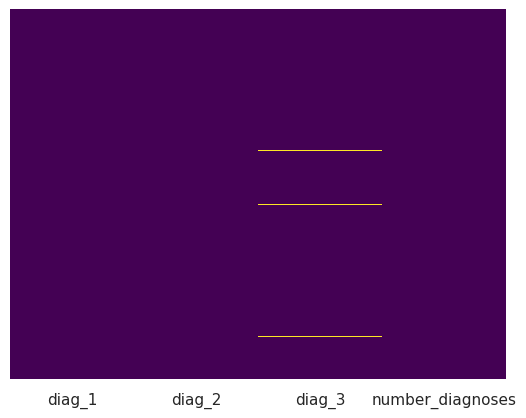

In [47]:
sns.heatmap(df[['diag_1','diag_2', 'diag_3','number_diagnoses']].isnull(),yticklabels=False,cbar=False,cmap='viridis');

In [48]:
# replace NaN with None in diagnosis 2 and 3 to show there is no additional diagnosis
df.fillna('None', inplace=True)

In [49]:
# confirm there are no more NaN values
null_values(df)

,Missing_Records,Percentage (%)


### Grouping Diagnosis Codes

In [50]:
summary(df[['diag_1','diag_2', 'diag_3']])

Data shape: (69388, 3)
___________________________
Data Types:
Types
object    3
Name: count, dtype: int64
___________________________


,Types,Counts,Uniques,Nulls,Min,Max
diag_1,object,69388,692,0,NaN,NaN
diag_2,object,69388,722,0,NaN,NaN
diag_3,object,69388,756,0,NaN,NaN


* 'diag_1','diag_2' and 'diag_3' columns contain codes for the types of conditions patients are diagnosed with.
* There are too much unique codes throughout this dataset.
* We can group the related icd9 diagnosis codes among themselves. In this way, we use categorical group names instead of numerical codes.
* The grouping is based on the research paper table (https://www.hindawi.com/journals/bmri/2014/781670/tab2/)
![image.png](attachment:image.png)

**Group Names**

    1-Circulatory
    2-Respiratory
    3-Digestive
    4-Diabetes
    5-Injury
    6-Musculoskeletal
    7-Genitourinary
    8-Neoplasms
    9-Other

In [51]:
# Circulatory
codes =[str(i) for i in list(range(390,460)) + [785]]
df = df.replace(codes, 'Circulatory')

In [52]:
# Respiratory
codes =[str(i) for i in list(range(460,520)) + [786]]
df = df.replace(codes, 'Respiratory')

In [53]:
# Digestive
codes =[str(i) for i in list(range(520,580)) + [787]]
df = df.replace(codes, 'Digestive')

In [54]:
# Diabetes
df = df.replace(regex=r'^250.*', value='Diabetes')

In [55]:
# Injury
codes =[str(i) for i in range(800,1000)]
df = df.replace(codes, 'Injury')

In [56]:
# Musculoskeletal
codes =[str(i) for i in range(710,740)]
df = df.replace(codes, 'Musculoskeletal')

In [57]:
# Genitourinary
codes =[str(i) for i in list(range(580,630)) + [788]]
df = df.replace(codes, 'Genitourinary')

In [58]:
# Neoplasms
codes =[str(i) for i in range(140,240)]
df = df.replace(codes, 'Neoplasms')

In [59]:
# Other
df = df.replace(regex=r'^[E,V].*', value='Other')

codes =[str(i) for i in range(0,1000)]
df = df.replace(codes, 'Other')

In [60]:
df[['diag_1', 'diag_2', 'diag_3']].head()

,diag_1,diag_2,diag_3
0,Diabetes,None,None
1,Other,Diabetes,Other
2,Other,Diabetes,Other
3,Other,Diabetes,Circulatory
4,Neoplasms,Neoplasms,Diabetes


In [61]:
# Unique Values of Each Features:
for i in df[['diag_1', 'diag_2', 'diag_3']]:
    print(f'{i}:\n{sorted(df[i].unique())}\n')

diag_1:
['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'Other', 'Respiratory']

diag_2:
['Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'None', 'Other', 'Respiratory']

diag_3:
['365.44', 'Circulatory', 'Diabetes', 'Digestive', 'Genitourinary', 'Injury', 'Musculoskeletal', 'Neoplasms', 'None', 'Other', 'Respiratory']



In [62]:
# need to add 365.44 to Other
df = df.replace('365.44', 'Other')

### Analysis of Diagnosis

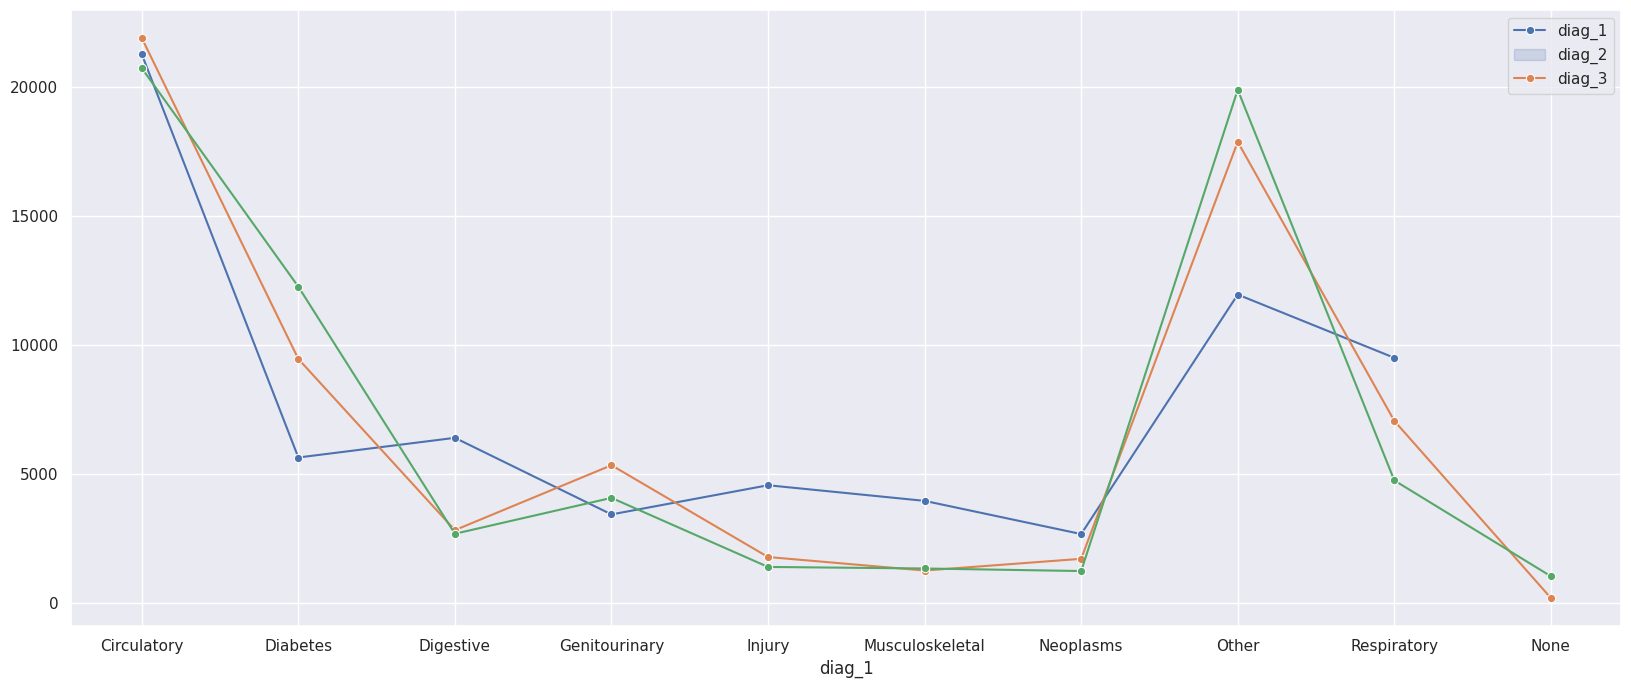

In [63]:
plt.figure(figsize=(20, 8))
for diag in ['diag_1','diag_2','diag_3']:
    sns.lineplot(x=df[diag].value_counts().sort_index().index, y= df[diag].value_counts().sort_index().values, marker='o')
plt.legend(['diag_1','diag_2','diag_3'])
plt.show()

* Looking at the graph above, we can say that there is a high correlation between the diagnoses. So we drop diag_2 and diag_3.
* Also since the most common diagnoses are prevalent in all three diagnoses listed, We are only using the primary diagnosis variable to build the machine learning model

In [64]:
# drop diagnoses 2 and 3
df = df.drop(columns=['diag_2', 'diag_3'])

### FOCUS ON "`number_diagnoses`"

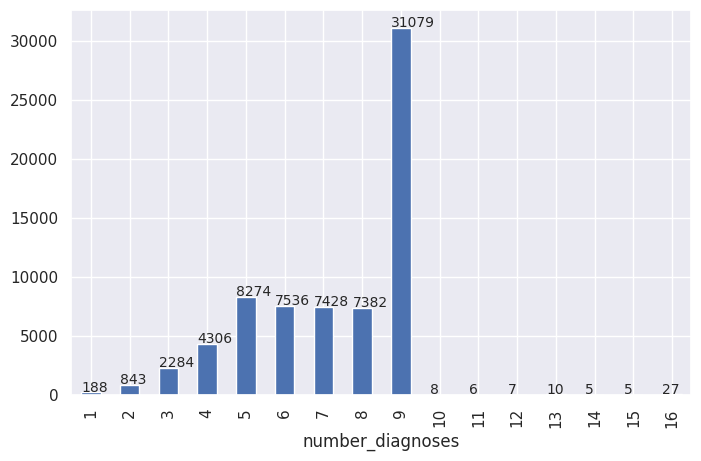

In [65]:
plt.figure(figsize=(8,5))
ax = df.number_diagnoses.value_counts().sort_index().plot.bar()
def labels(ax, df=df):
    for p in ax.patches:
            ax.annotate('{:.0f}'.format(p.get_height()),
                        (p.get_x(), p.get_height()+100),size=10)
labels(ax)

* For a small number of observations with number of diagnoses greater than 9, let's change the number of diagnoses to 9.

In [66]:
df.number_diagnoses = df.number_diagnoses.replace([10,11,12,13,14,15,16],9)

### Outlier Detection

Based on the basic statistics describing the dataset, it looks there are outliers that influence skewness in the data. In order to represent the majority of samples and build clean models, we are going to remove outliers that have [z-scores](https://www.statisticshowto.datasciencecentral.com/probability-and-statistics/z-score/) greater than 3.0 or less than -3.0. This means that we are removing samples that are more (or less) than 3 times the standard deviation from the mean.

In [67]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,69388.0,4.291895,2.951166,1.0,2.0,3.0,6.0,14.0
num_lab_procedures,69388.0,43.051839,19.992895,1.0,31.0,44.0,57.0,132.0
num_procedures,69388.0,1.432265,1.758236,0.0,0.0,1.0,2.0,6.0
num_medications,69388.0,15.709676,8.303491,1.0,10.0,14.0,20.0,81.0
number_outpatient,69388.0,0.283954,1.079474,0.0,0.0,0.0,0.0,42.0
number_emergency,69388.0,0.105696,0.515331,0.0,0.0,0.0,0.0,42.0
number_inpatient,69388.0,0.179930,0.607700,0.0,0.0,0.0,0.0,12.0
number_diagnoses,69388.0,7.262221,1.976164,1.0,6.0,8.0,9.0,9.0


In [68]:
features = df.describe().columns

In [69]:
def col_plot(df,col_name):
    plt.figure(figsize=(15,6))

    plt.subplot(141) # 1 satir x 4 sutun dan olusan ax in 1. sutununda calis
    plt.hist(df[col_name], bins = 20)
    f=lambda x:(np.sqrt(x) if x>=0 else -np.sqrt(-x))

    # üç sigma aralikta(verinin %99.7 sini icine almasi beklenen bolum) iki kirmizi cizgi arasinda
    plt.axvline(x=df[col_name].mean() + 3*df[col_name].std(),color='red')
    plt.axvline(x=df[col_name].mean() - 3*df[col_name].std(),color='red')
    plt.xlabel(col_name)
    plt.tight_layout
    plt.xlabel("Histogram ±3z")
    plt.ylabel(col_name)

    plt.subplot(142)
    plt.boxplot(df[col_name]) # IQR katsayisi, defaultu 1.5
    plt.xlabel("IQR=1.5")

    plt.subplot(143)
    plt.boxplot(df[col_name].apply(f), whis = 2.5)
    plt.xlabel("ROOT SQUARE - IQR=2.5")

    plt.subplot(144)
    plt.boxplot(np.log(df[col_name]+0.1), whis = 2.5)
    plt.xlabel("LOGARITMIC - IQR=2.5")
    plt.show()

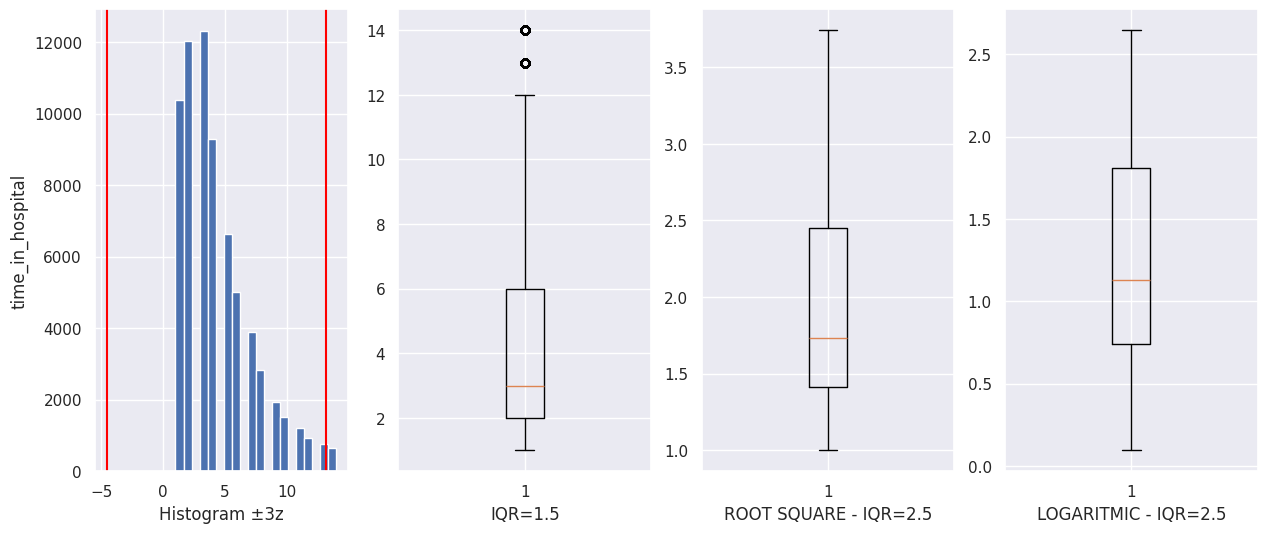

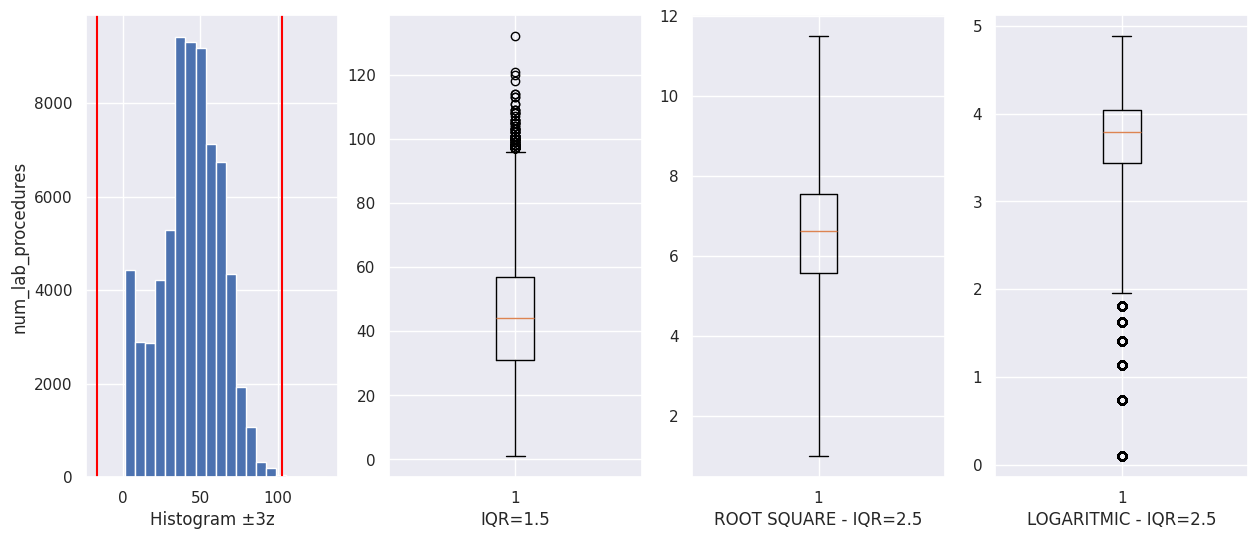

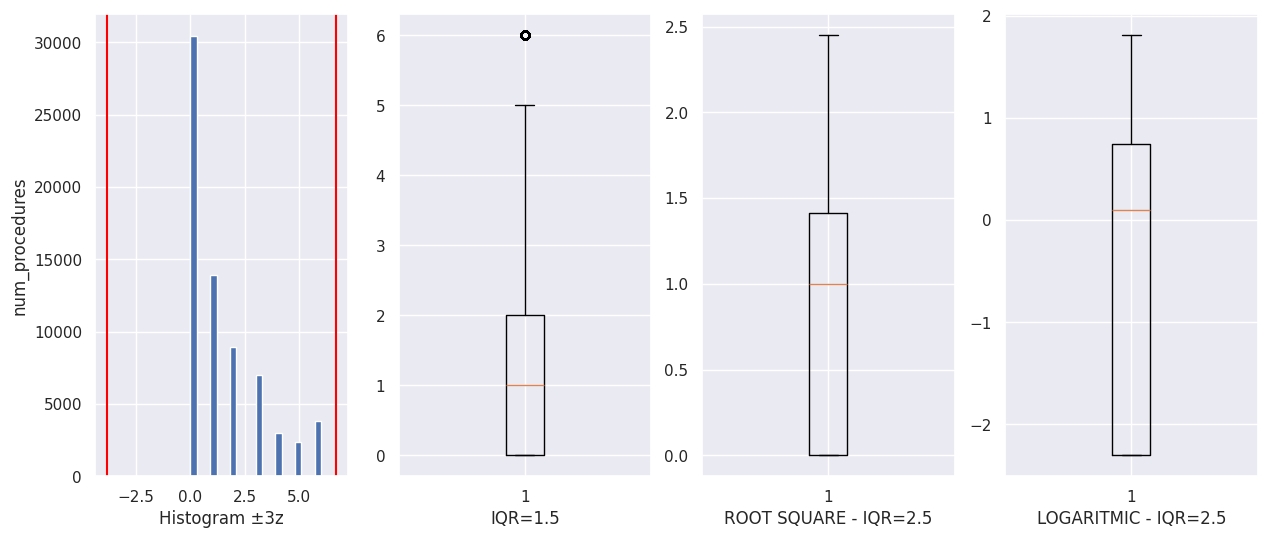

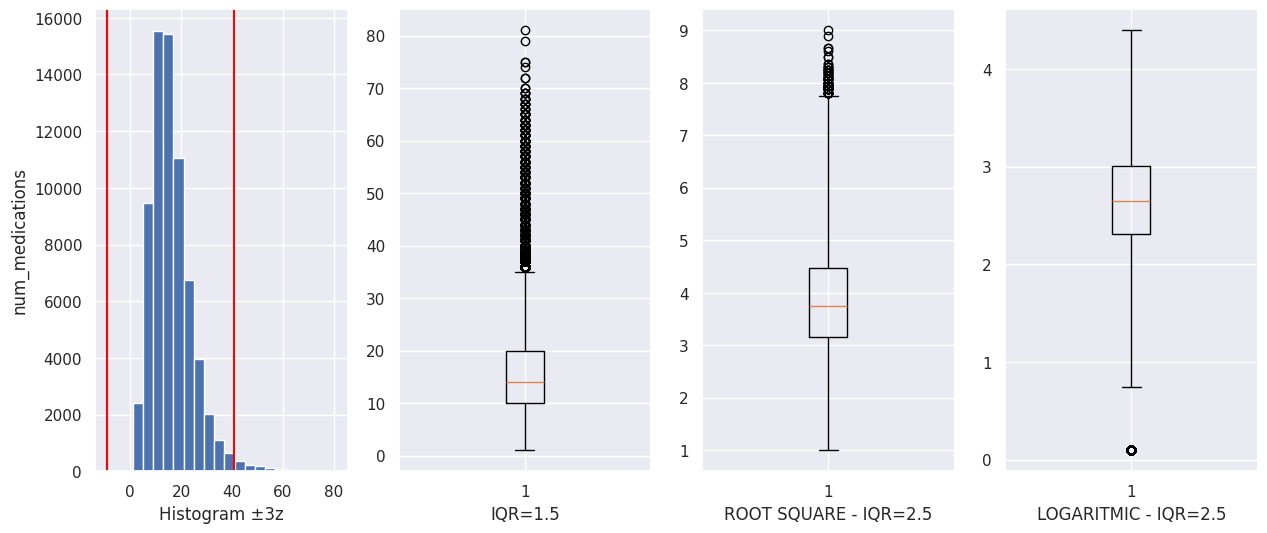

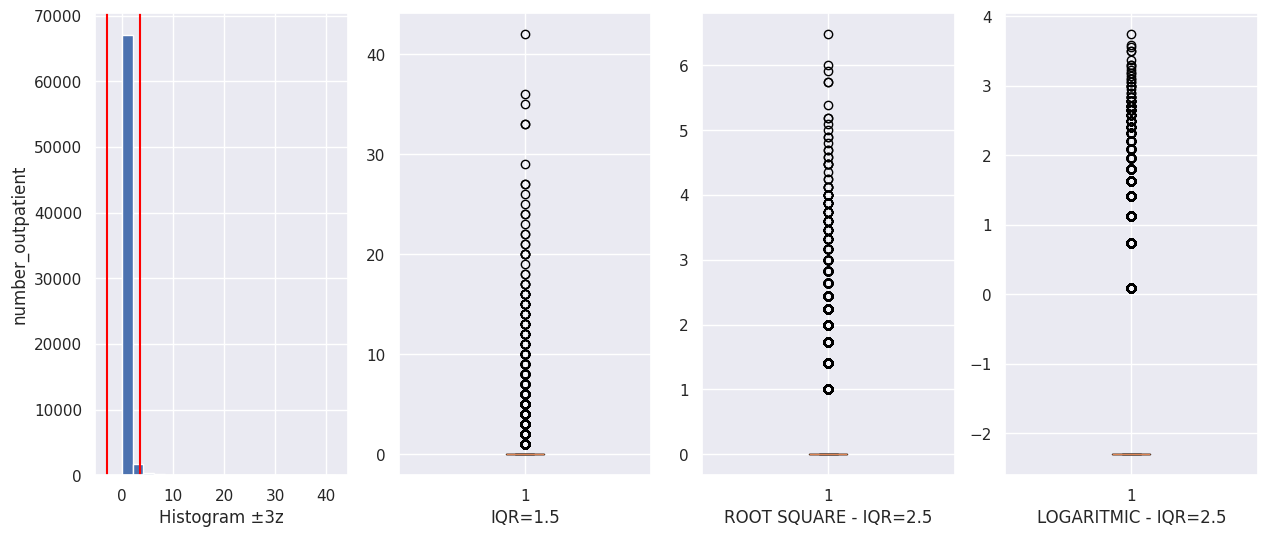

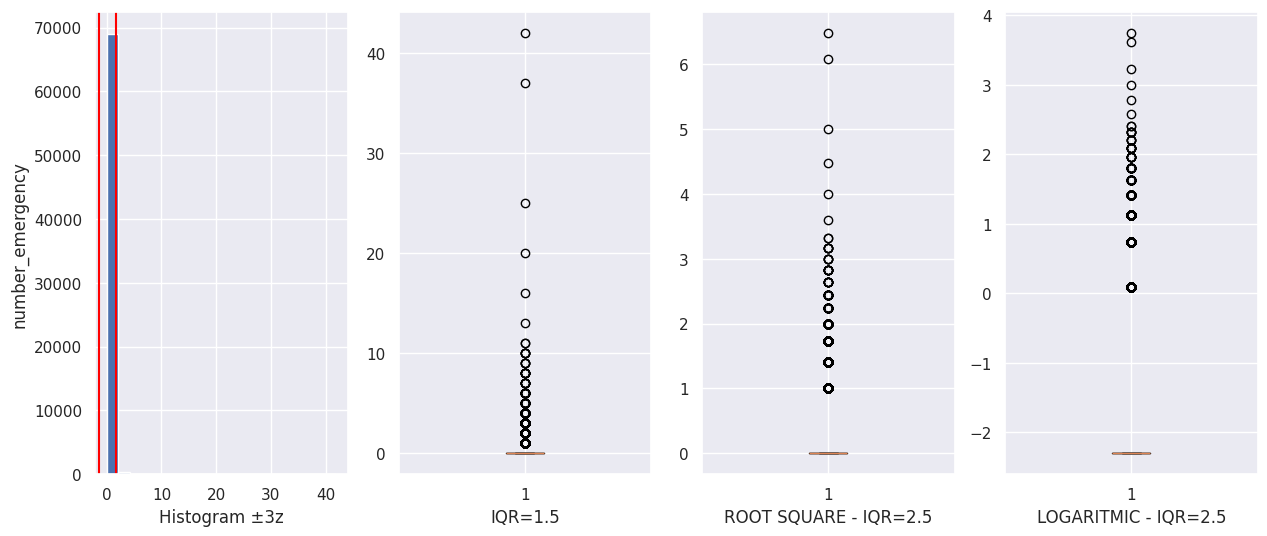

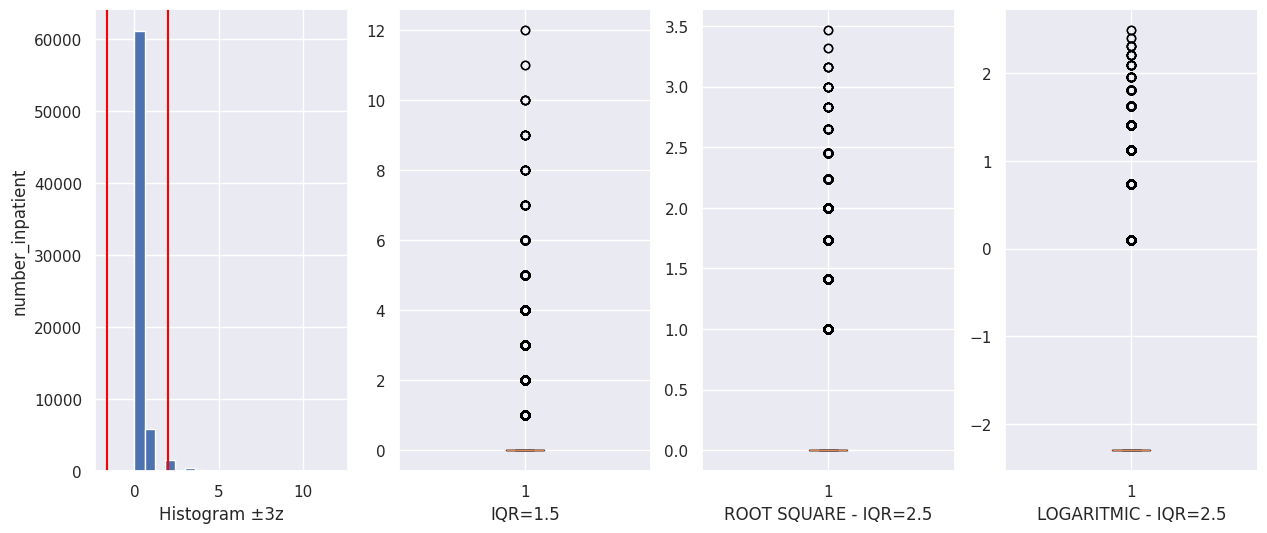

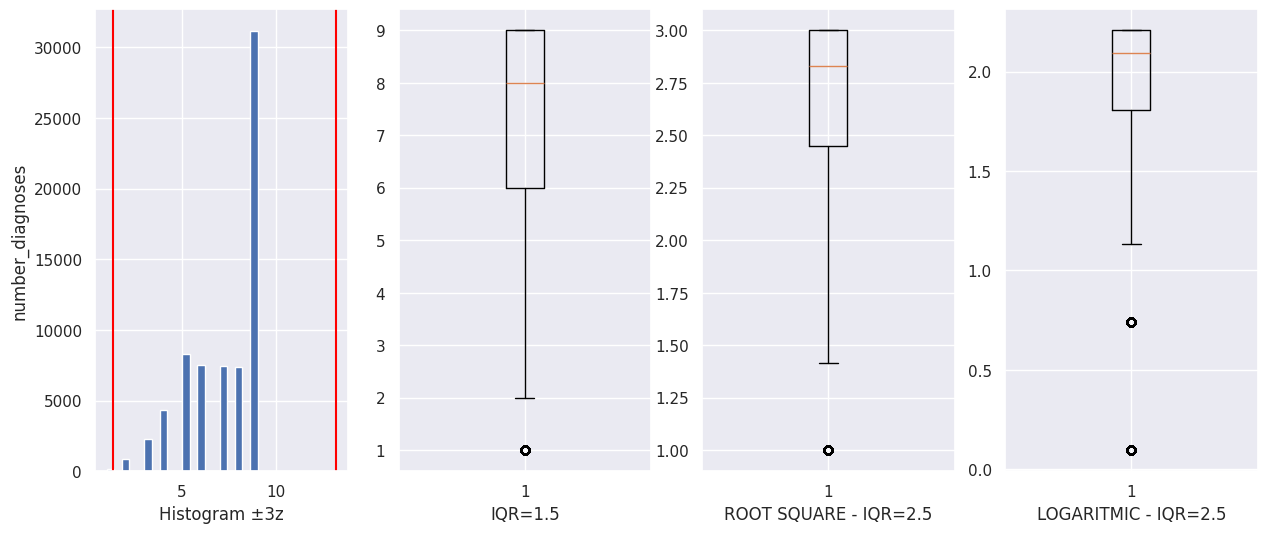

In [70]:
for i in features:
    col_plot(df,i)

In [71]:
from scipy.stats.mstats import winsorize

def plot_winsorize(df,col_name,up=0.1,down=0):
    plt.figure(figsize = (15, 6))

    winsor=winsorize(df[col_name], (down,up))
    logr=np.log(df[col_name]+0.1)

    plt.subplot(141)
    plt.hist(winsor, bins = 22)
    plt.axvline(x=winsor.mean()+3*winsor.std(),color='red')
    plt.axvline(x=winsor.mean()-3*winsor.std(),color='red')
    plt.xlabel('Winsorize_Histogram')
    plt.ylabel(col_name)
    plt.tight_layout

    plt.subplot(142)
    plt.boxplot(winsor, whis = 1.5)
    plt.xlabel('Winsorize - IQR:1.5')

    plt.subplot(143)
    plt.hist(logr, bins=22)
    plt.axvline(x=logr.mean()+3*logr.std(),color='red')
    plt.axvline(x=logr.mean()-3*logr.std(),color='red')
    plt.xlabel('Logr_col_name')

    plt.subplot(144)
    plt.boxplot(logr, whis = 1.5)
    plt.xlabel("Logaritmic - IQR=1.5")
    plt.show()


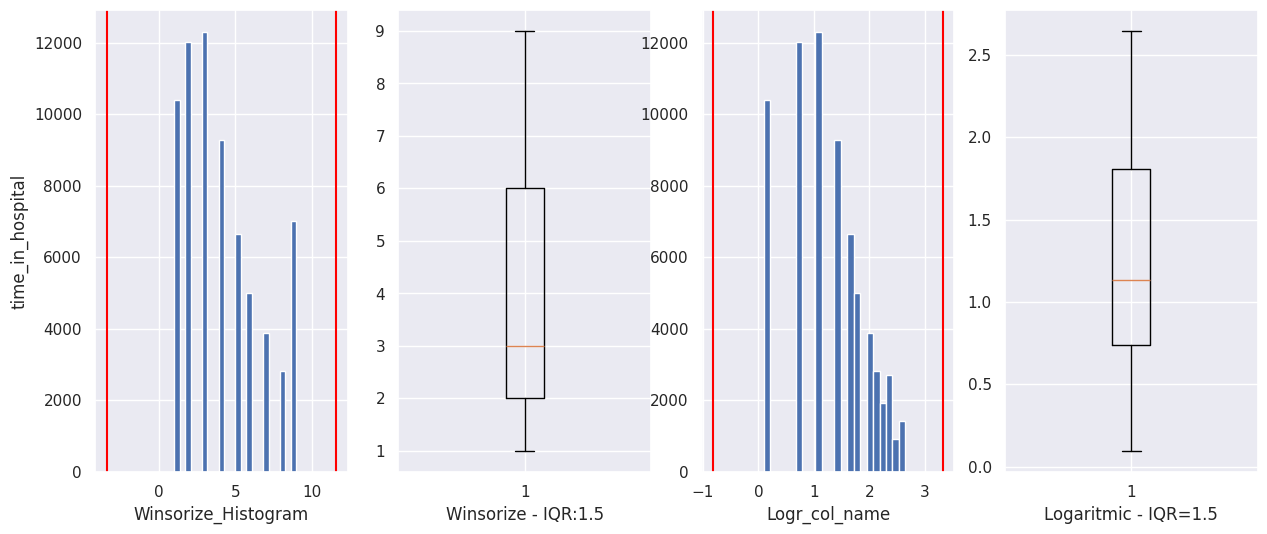

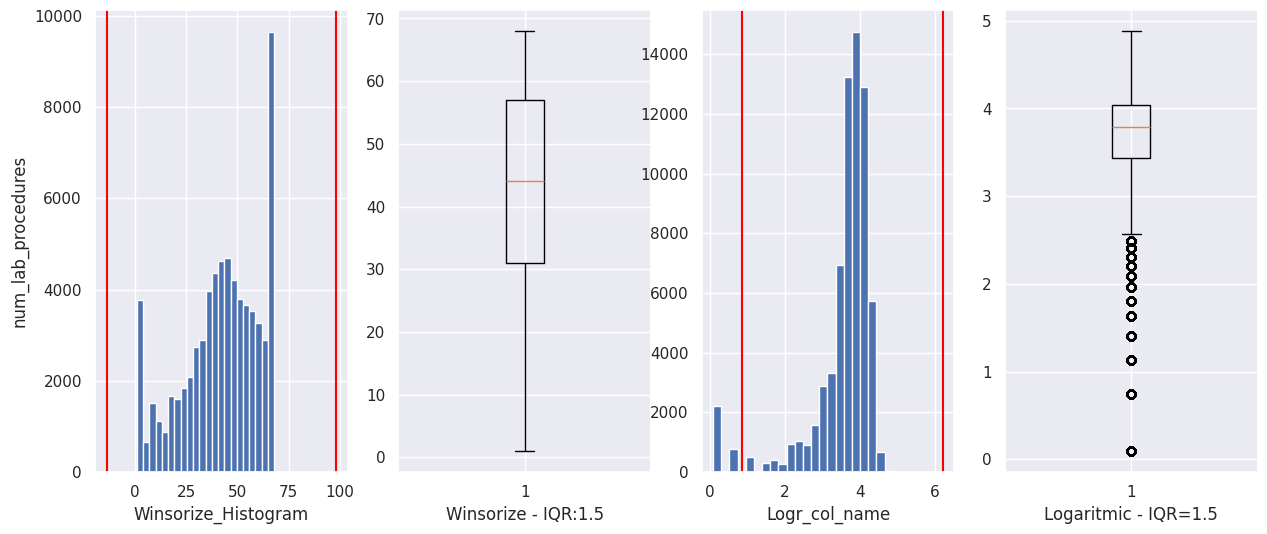

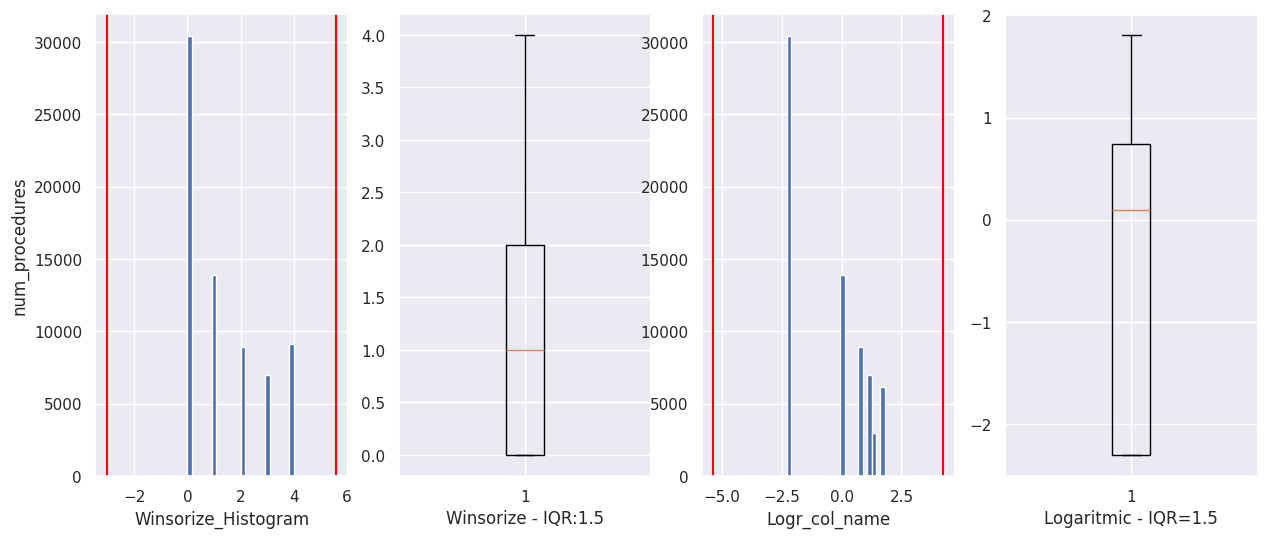

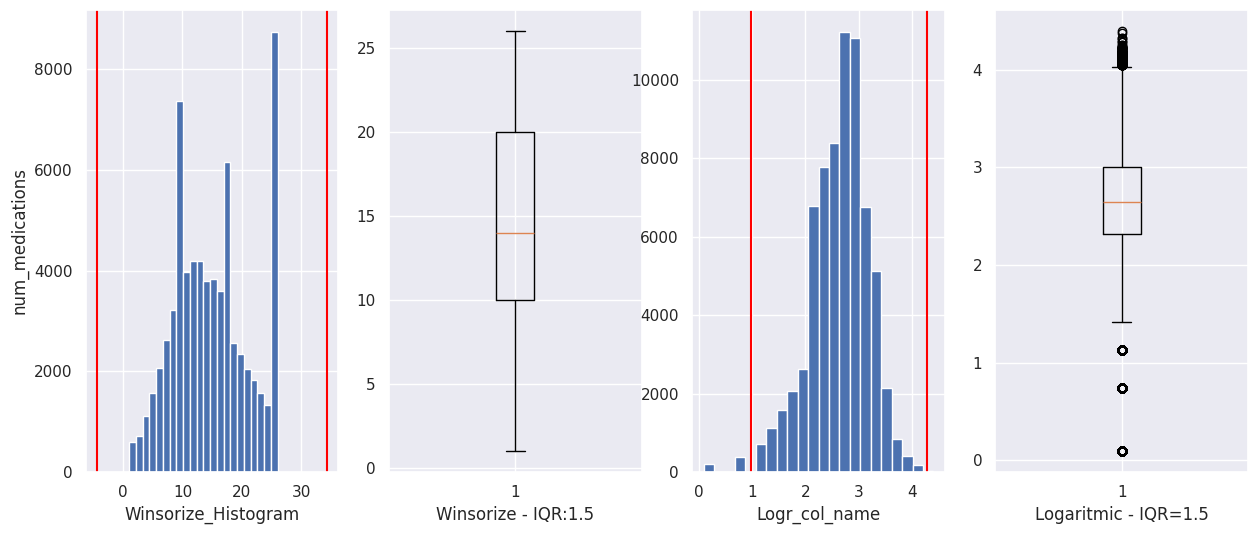

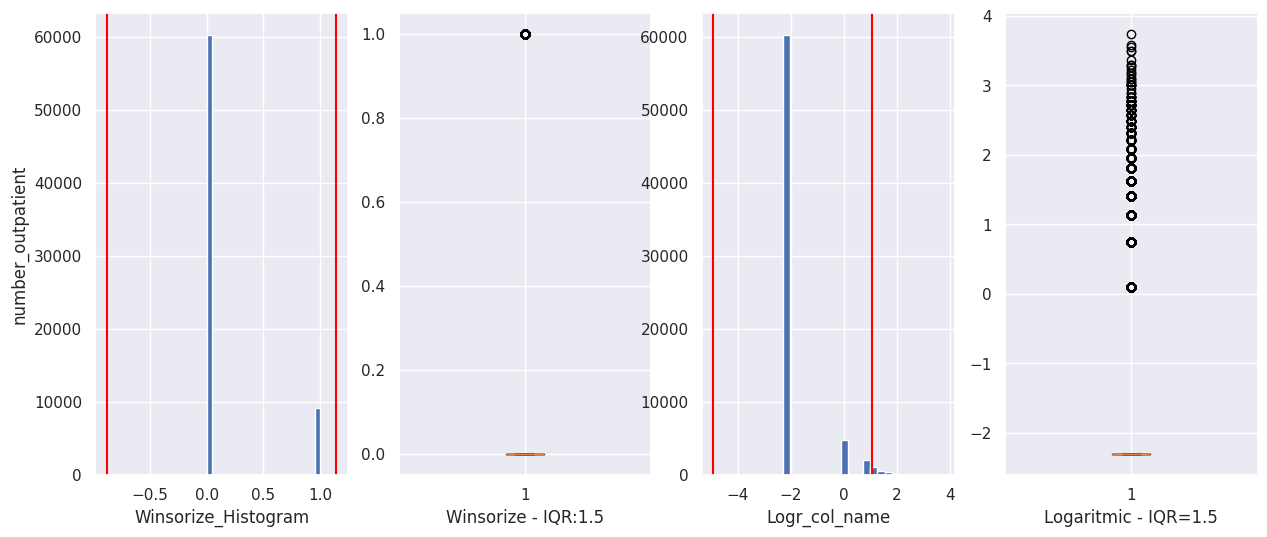

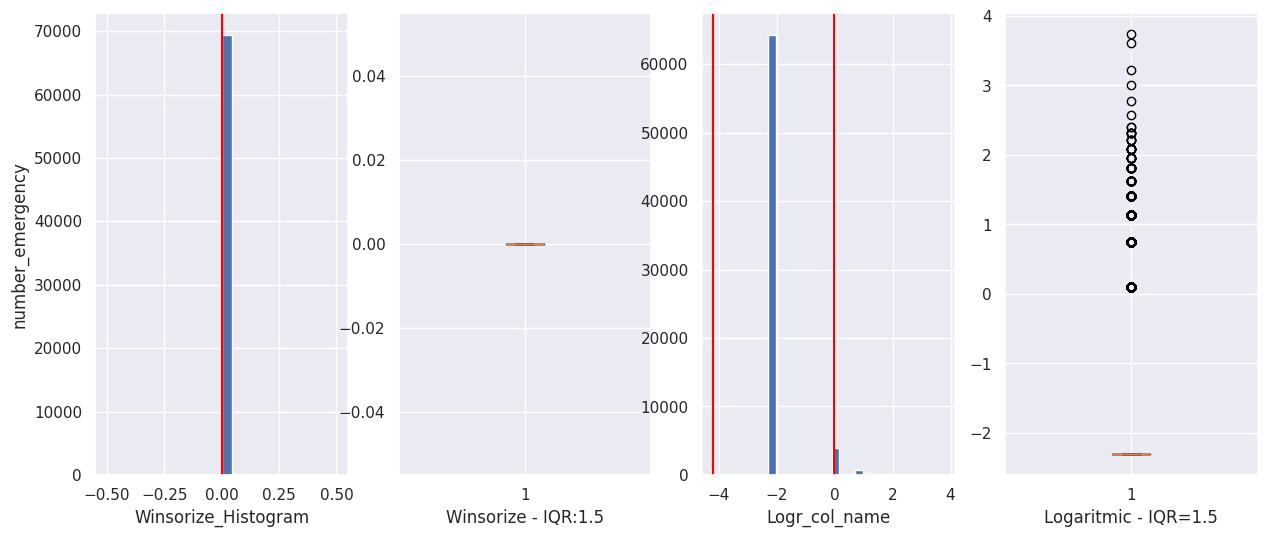

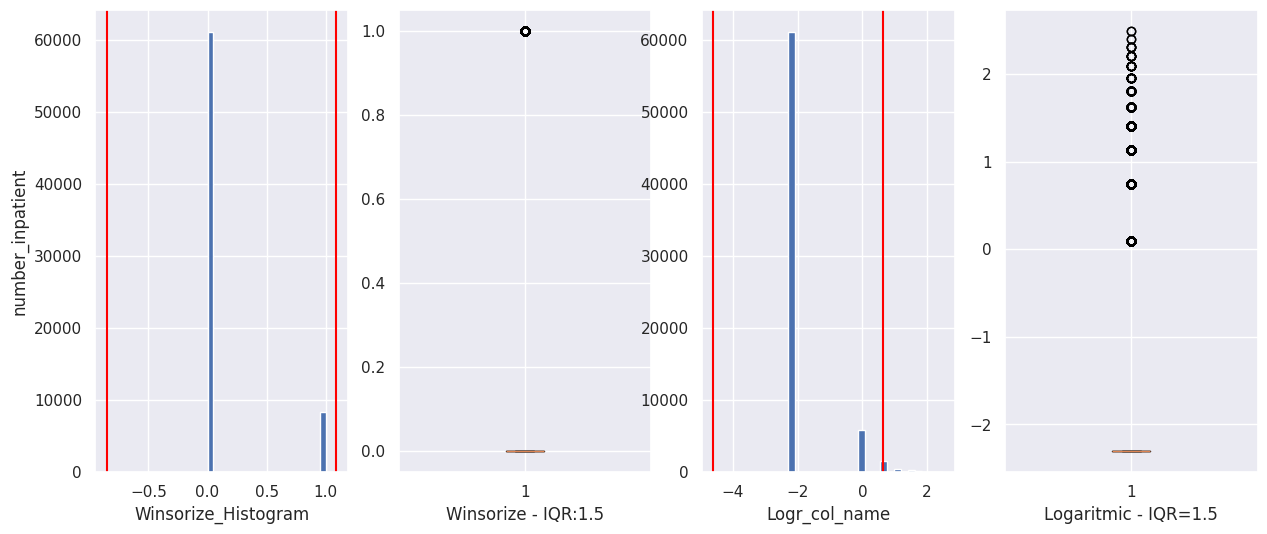

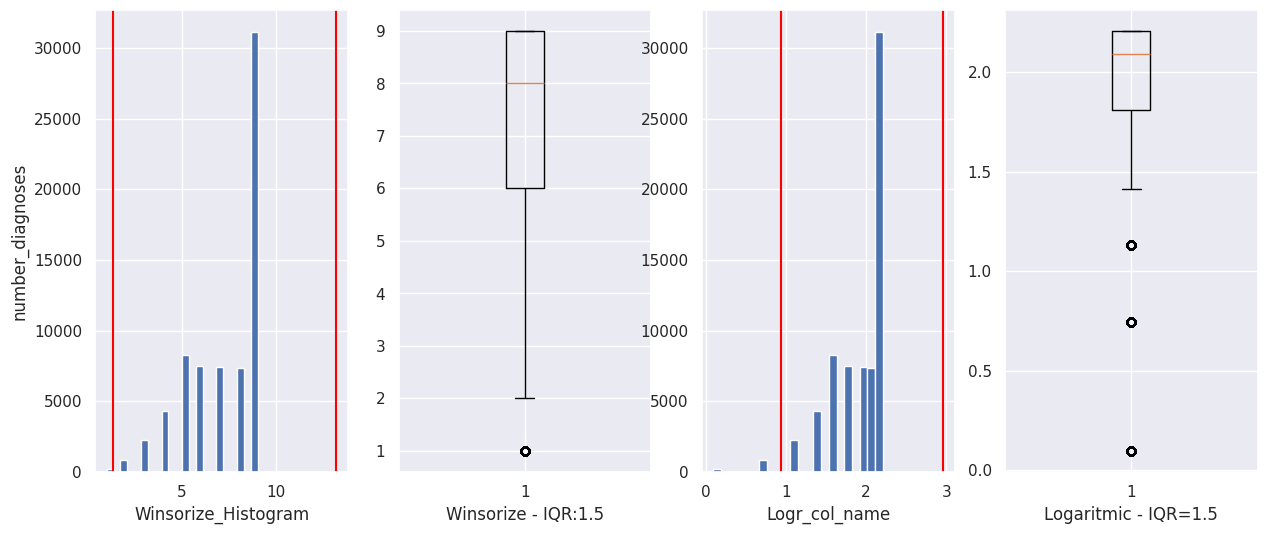

In [72]:
for i in features:
    plot_winsorize(df,i)

In [73]:
df_winsorised=df.copy()
for i in features:
    df_winsorised[i]=winsorize(df_winsorised[i], (0,0.1))

In [74]:
df_log=df.copy()
for i in features:
    df_log[i]=np.log(df_log[i])

In [75]:
df_root=df.copy()
f=lambda x:(np.sqrt(x) if x>=0 else -np.sqrt(-x))
for i in features:
    df_root[i]=df_root[i].apply(f)

In [76]:
from numpy import percentile
from scipy.stats import zscore
from scipy import stats

def outlier_zscore(df, col, min_z=1, max_z = 5, step = 0.1, print_list = False):
    z_scores = zscore(df[col].dropna())
    threshold_list = []
    for threshold in np.arange(min_z, max_z, step):
        threshold_list.append((threshold, len(np.where(z_scores > threshold)[0])))
        df_outlier = pd.DataFrame(threshold_list, columns = ['threshold', 'outlier_count'])
        df_outlier['pct'] = (df_outlier.outlier_count - df_outlier.outlier_count.shift(-1))/df_outlier.outlier_count*100
    plt.plot(df_outlier.threshold, df_outlier.outlier_count)
    best_treshold = round(df_outlier.iloc[df_outlier.pct.argmax(), 0],2)
    outlier_limit = int(df[col].dropna().mean() + (df[col].dropna().std()) * df_outlier.iloc[df_outlier.pct.argmax(), 0])
    percentile_threshold = stats.percentileofscore(df[col].dropna(), outlier_limit)
    plt.vlines(best_treshold, 0, df_outlier.outlier_count.max(),
               colors="r", ls = ":"
              )
    plt.annotate("Zscore : {}\nValue : {}\nPercentile : {}".format(best_treshold, outlier_limit,
                                                                   (np.round(percentile_threshold, 3),
                                                                    np.round(100-percentile_threshold, 3))),
                 (best_treshold, df_outlier.outlier_count.max()/2))
    #plt.show()
    if print_list:
        print(df_outlier)
    return (plt, df_outlier, best_treshold, outlier_limit, percentile)

In [77]:
from scipy.stats import zscore
from scipy import stats

def outlier_inspect(df, col, min_z=1, max_z = 5, step = 0.5, max_hist = None, bins = 50):
    fig = plt.figure(figsize=(20, 6))
    fig.suptitle(col, fontsize=16)
    plt.subplot(1,3,1)
    if max_hist == None:
        sns.distplot(df[col], kde=False, bins = 50)
    else :
        sns.distplot(df[df[col]<=max_hist][col], kde=False, bins = 50)

    plt.subplot(1,3,2)
    sns.boxplot(df[col])
    plt.subplot(1,3,3)
    z_score_inspect = outlier_zscore(df, col, min_z=min_z, max_z = max_z, step = step)

    plt.subplot(1,3,1)
    plt.axvline(x=df[col].mean() + z_score_inspect[2]*df[col].std(),color='red',linewidth=1,linestyle ="--")
    plt.axvline(x=df[col].mean() - z_score_inspect[2]*df[col].std(),color='red',linewidth=1,linestyle ="--")
    plt.show()

    return z_score_inspect

In [78]:
def detect_outliers(df:pd.DataFrame, col_name:str, p=1.5) ->int:
    '''
    this function detects outliers based on 3 time IQR and
    returns the number of lower and uper limit and number of outliers respectively
    '''
    first_quartile = np.percentile(np.array(df[col_name].tolist()), 25)
    third_quartile = np.percentile(np.array(df[col_name].tolist()), 75)
    IQR = third_quartile - first_quartile

    upper_limit = third_quartile+(p*IQR)
    lower_limit = first_quartile-(p*IQR)
    outlier_count = 0

    for value in df[col_name].tolist():
        if (value < lower_limit) | (value > upper_limit):
            outlier_count +=1
    return lower_limit, upper_limit, outlier_count

In [79]:
k=3
print(f"Number of Outliers for {k}*IQR\n")

total=0
for col in features:
    if detect_outliers(df, col)[2] > 0:
        outliers=detect_outliers(df, col, k)[2]
        total+=outliers
        print("{} outliers in '{}'".format(outliers,col))
print("\n{} OUTLIERS TOTALLY".format(total))

Number of Outliers for 3*IQR

0 outliers in 'time_in_hospital'
0 outliers in 'num_lab_procedures'
0 outliers in 'num_procedures'
342 outliers in 'num_medications'
9120 outliers in 'number_outpatient'
5148 outliers in 'number_emergency'
8274 outliers in 'number_inpatient'
0 outliers in 'number_diagnoses'

22884 OUTLIERS TOTALLY


In [80]:
k=3
print(f"Number of Outliers for {k}*IQR after Root Square\n")

total=0
for col in features:
    if detect_outliers(df_root, col)[2] > 0:
        outliers=detect_outliers(df_root, col, k)[2]
        total+=outliers
        print("{} outliers in '{}'".format(outliers,col))
print("\n{} OUTLIERS TOTALLY".format(total))

Number of Outliers for 3*IQR after Root Square

0 outliers in 'num_lab_procedures'
7 outliers in 'num_medications'
9120 outliers in 'number_outpatient'
5148 outliers in 'number_emergency'
8274 outliers in 'number_inpatient'
0 outliers in 'number_diagnoses'

22549 OUTLIERS TOTALLY


In [81]:
k=3
print(f"Number of Outliers for {k}*IQR after Winsorised\n")

total=0
for col in features:
    if detect_outliers(df_winsorised, col)[2] > 0:
        outliers=detect_outliers(df_winsorised, col, k)[2]
        total+=outliers
        print("{} outliers in '{}'".format(outliers,col))
print("\n{} OUTLIERS TOTALLY".format(total))

Number of Outliers for 3*IQR after Winsorised

9120 outliers in 'number_outpatient'
8274 outliers in 'number_inpatient'
0 outliers in 'number_diagnoses'

17394 OUTLIERS TOTALLY


In [82]:
k=3
print(f"Number of Outliers for {k}*IQR after Logarithmed\n")

total=0
for col in features:
    if detect_outliers(df_log, col)[2] > 0:
        outliers=detect_outliers(df_log, col, k)[2]
        total+=outliers
        print("{} outliers in '{}'".format(outliers,col))
print("\n{} OUTLIERS TOTALLY".format(total))

Number of Outliers for 3*IQR after Logarithmed

3774 outliers in 'num_lab_procedures'
205 outliers in 'num_medications'
188 outliers in 'number_diagnoses'

4167 OUTLIERS TOTALLY


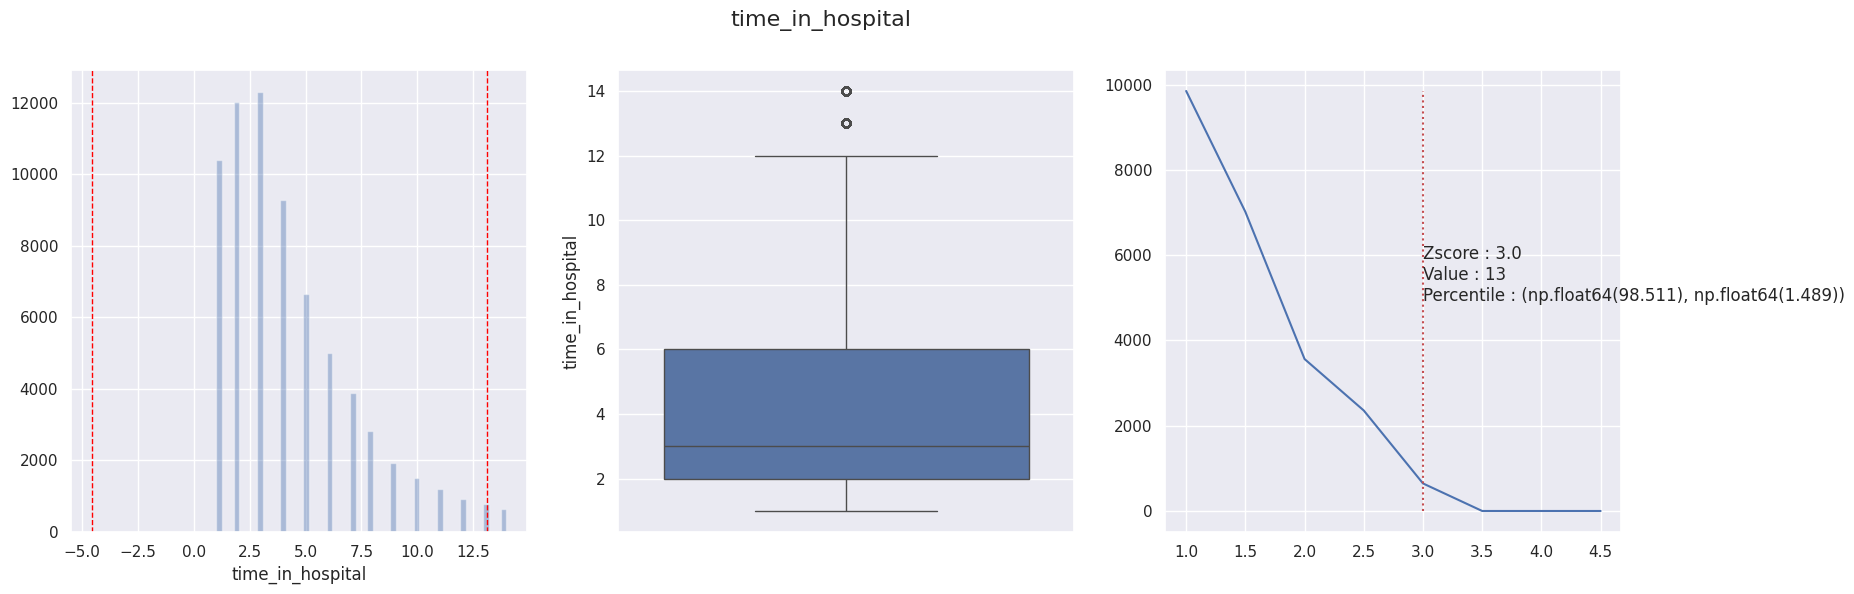

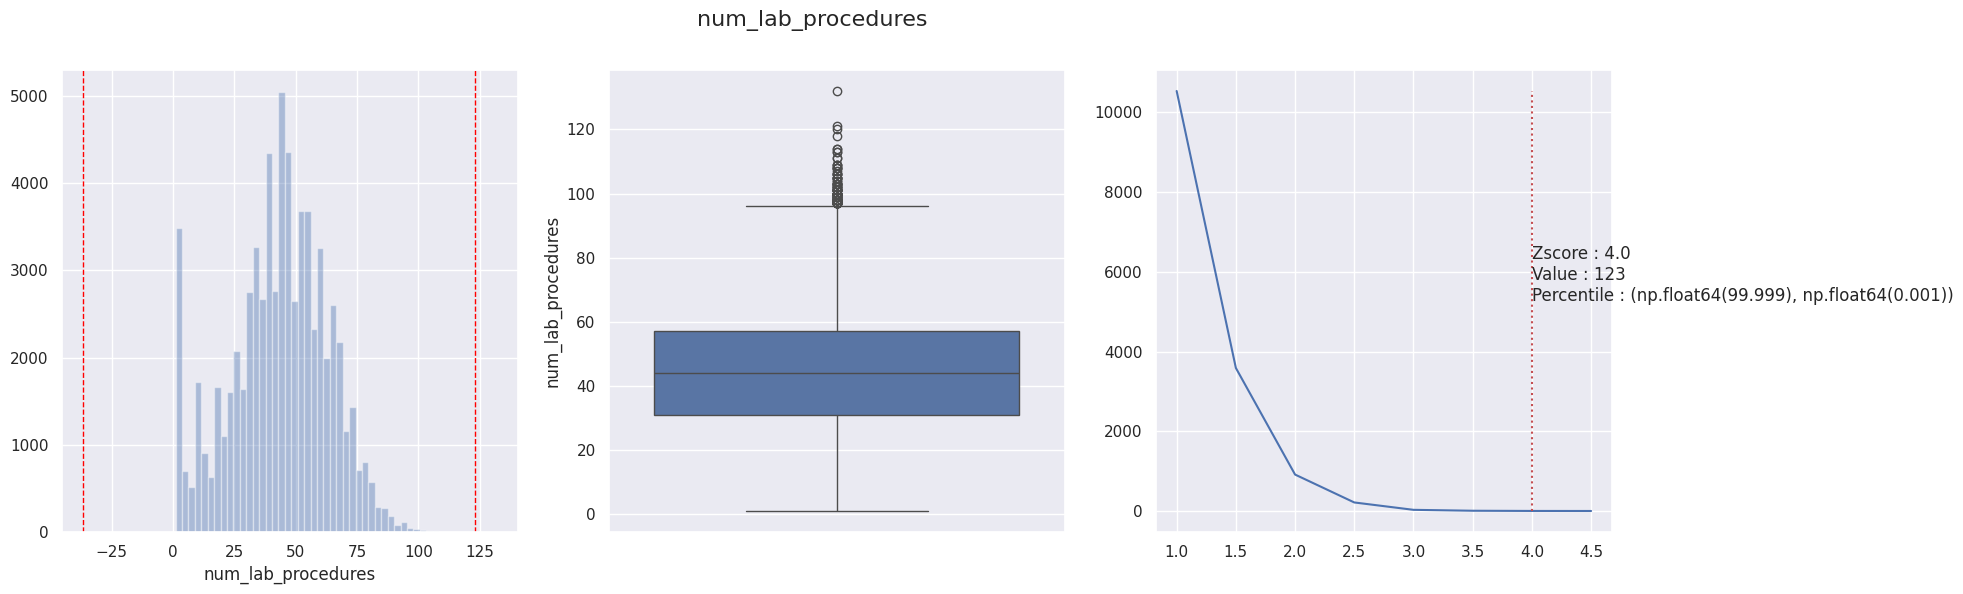

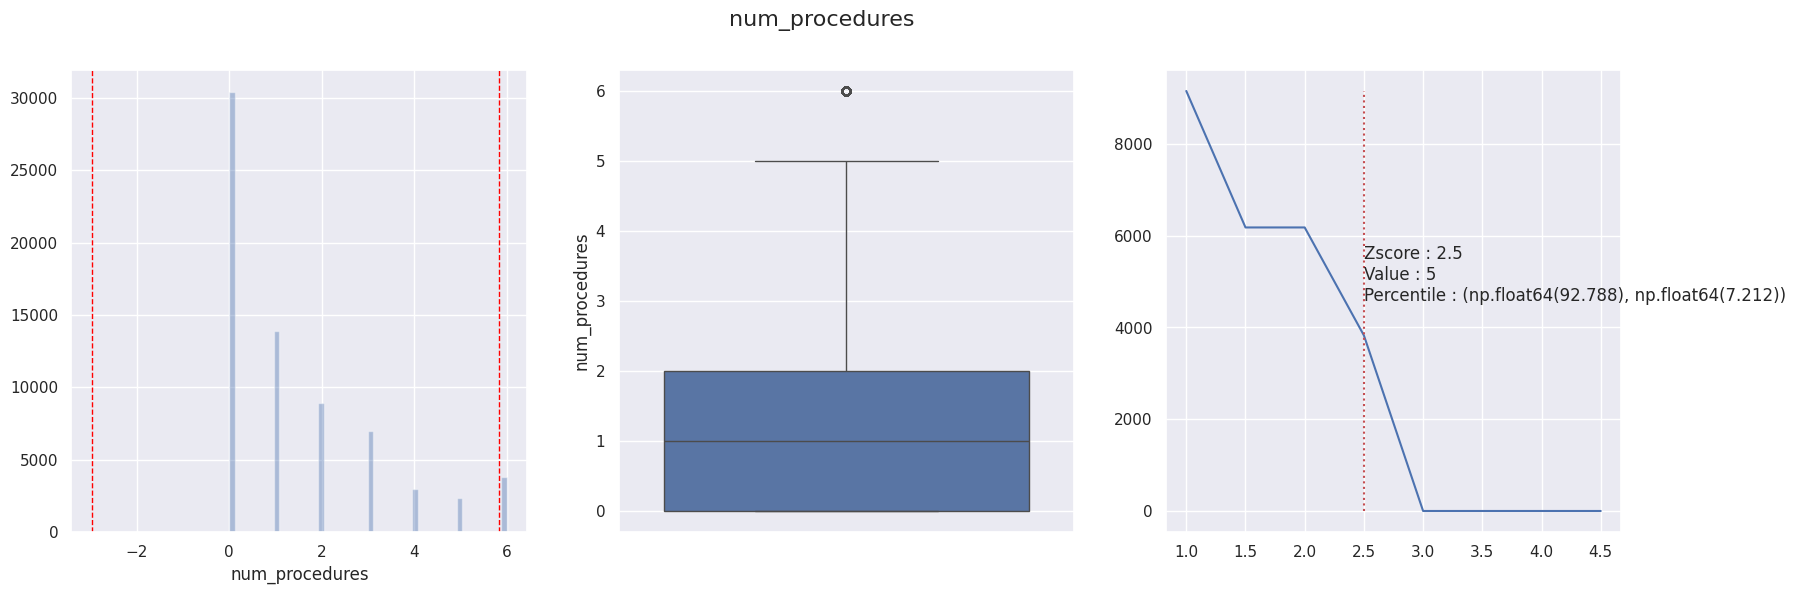

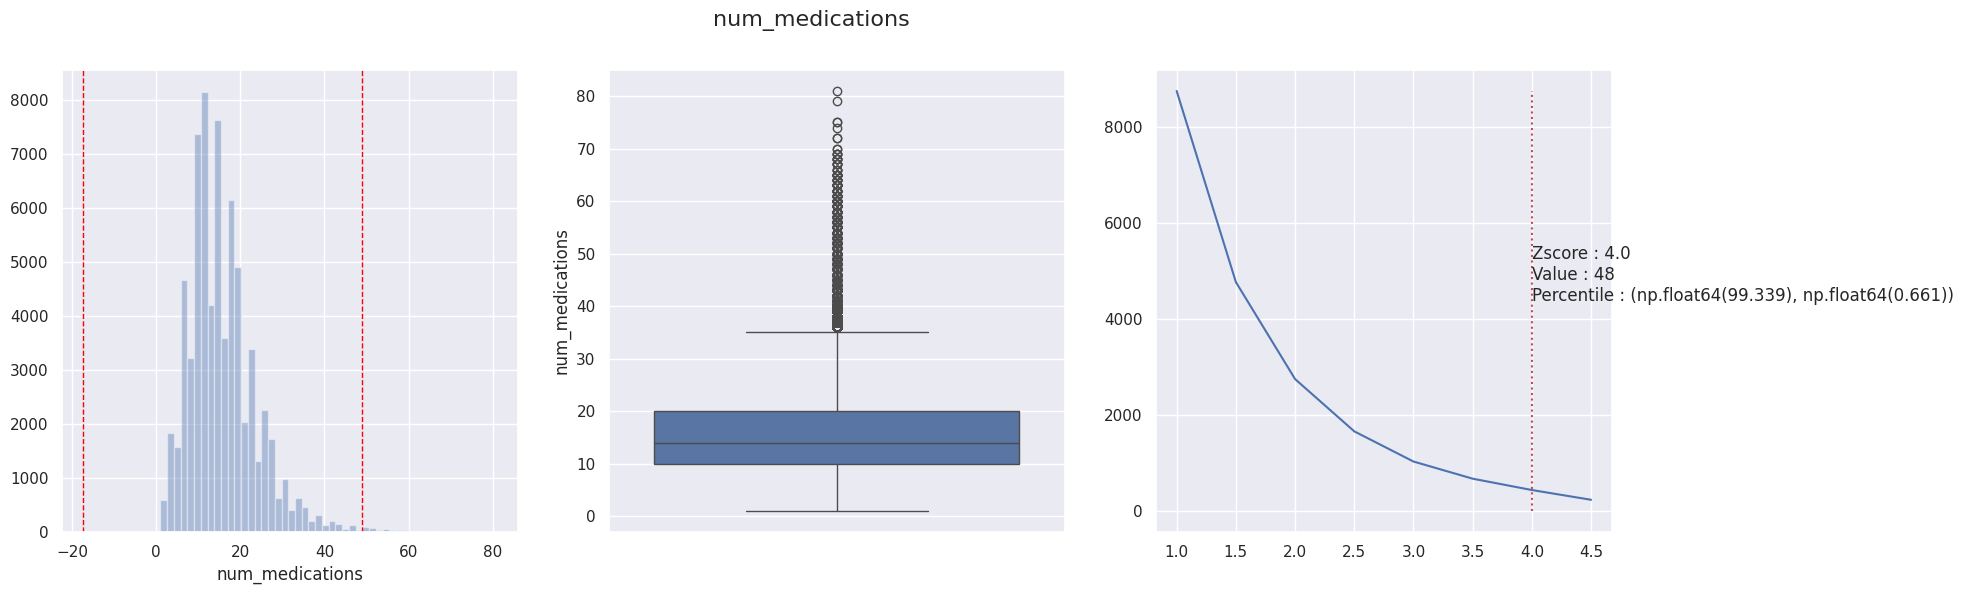

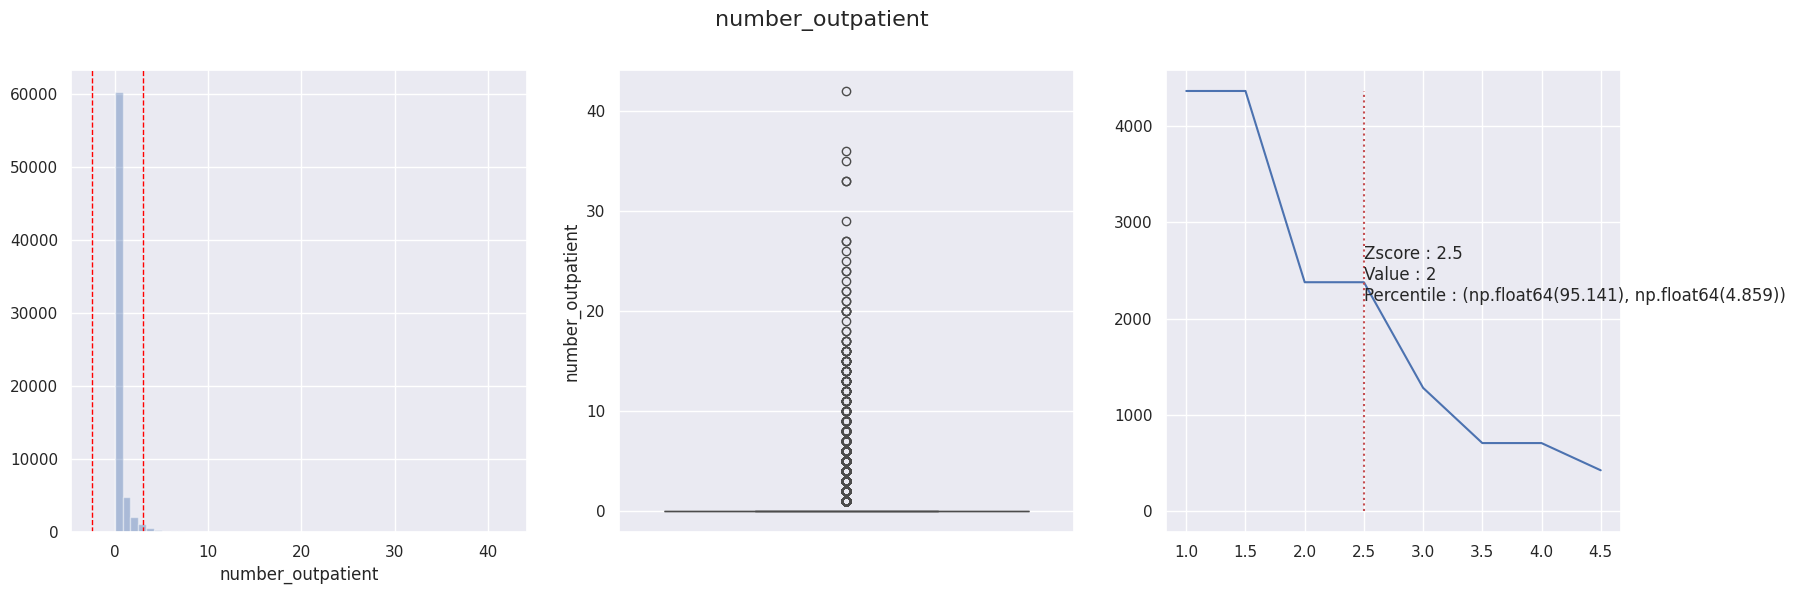

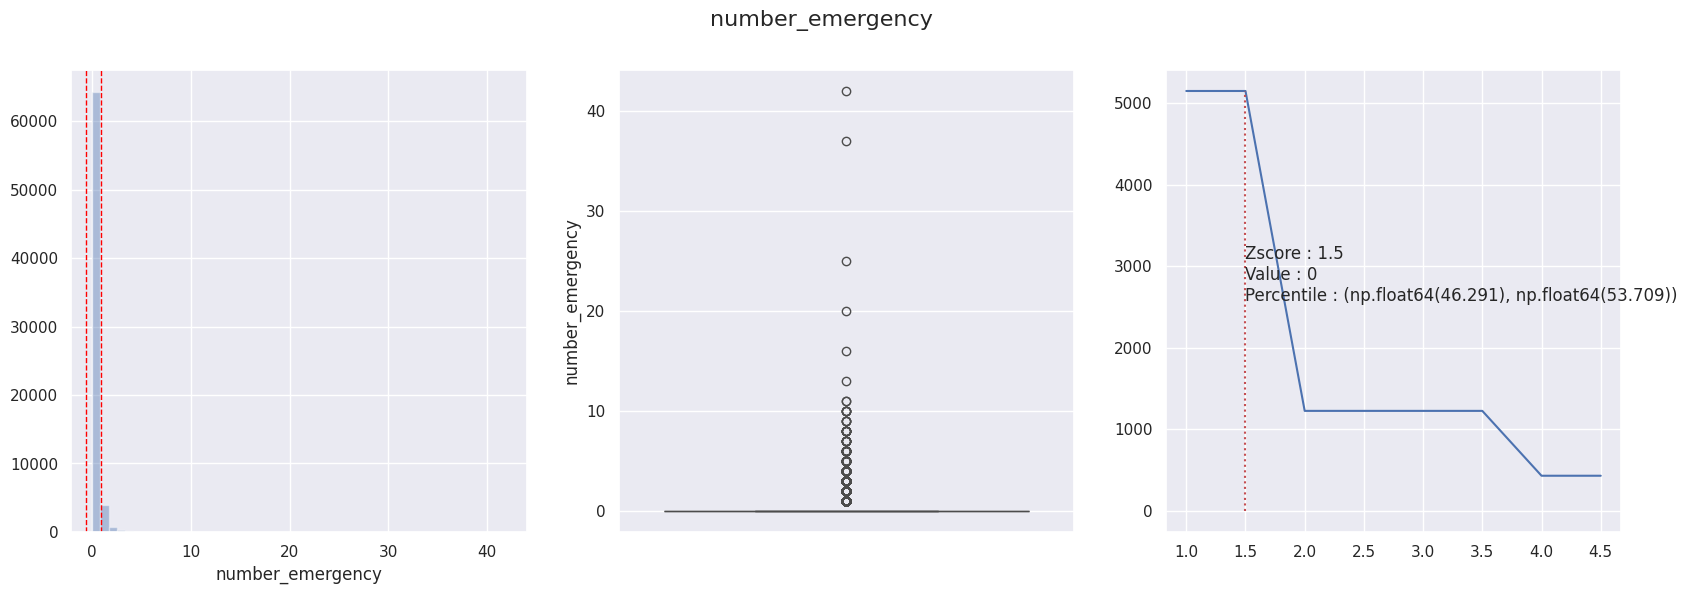

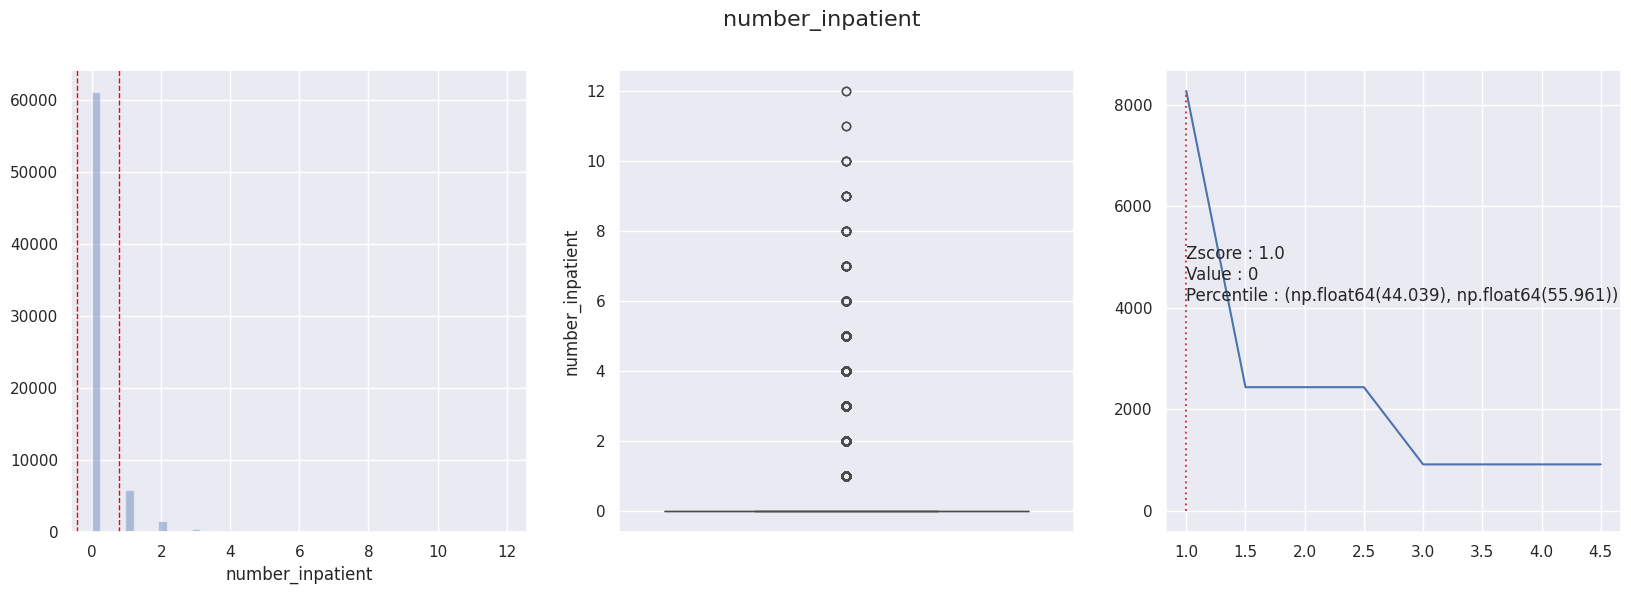

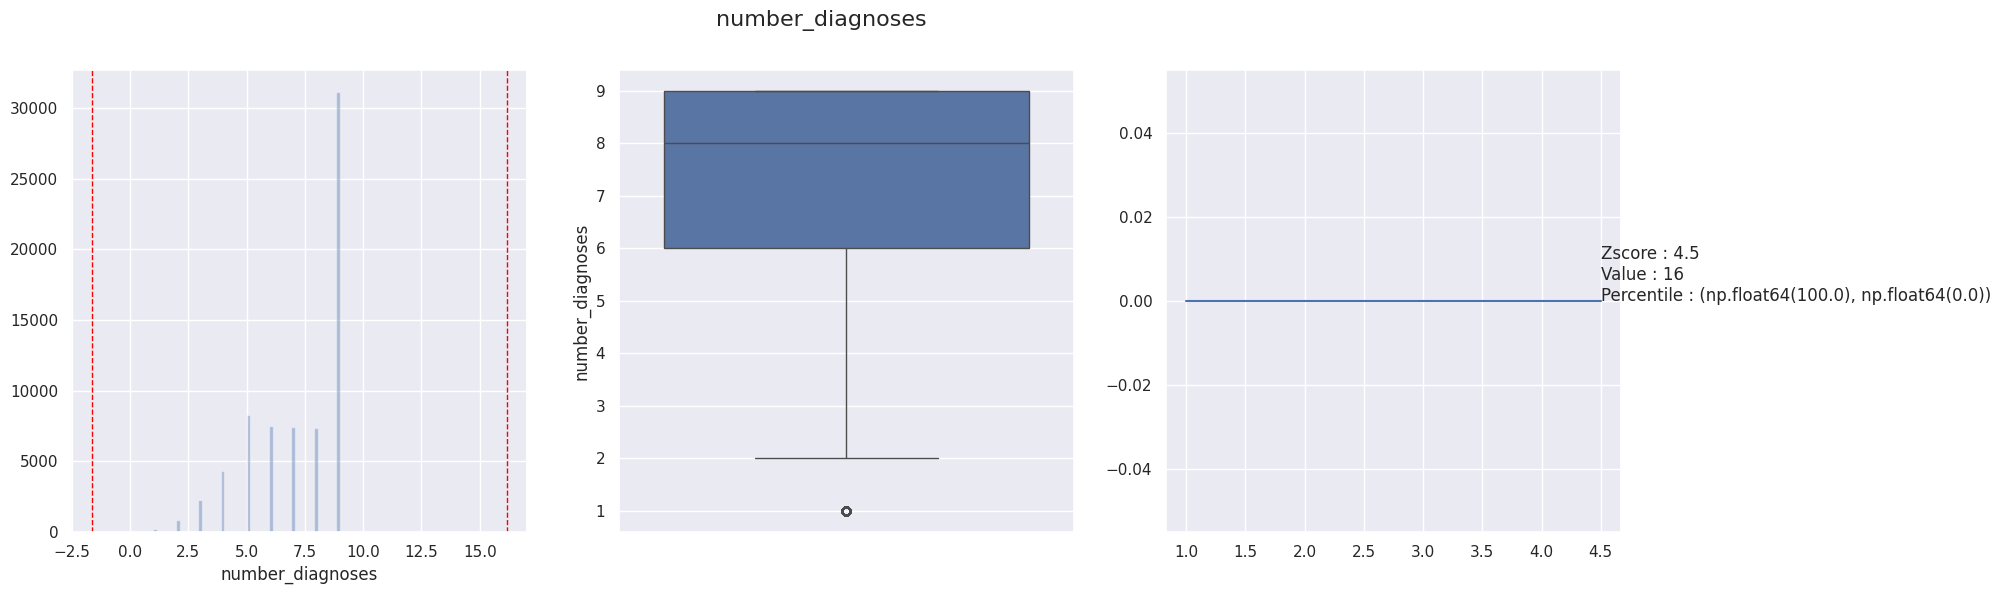

In [83]:
z_scores=[]
for i in features:
    z_scores.append(outlier_inspect(df,i)[2])

In [84]:
z_scores

[np.float64(3.0),
 np.float64(4.0),
 np.float64(2.5),
 np.float64(4.0),
 np.float64(2.5),
 np.float64(1.5),
 np.float64(1.0),
 np.float64(4.5)]

In [85]:
features

Index(['time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses'],
      dtype='object')

In [86]:
# create columns for z scores, new column with z score
df_3z=df.copy()

for x in features:
    df_3z[x + '_z'] = stats.zscore(df_3z[x])

for x in df_3z.columns[-len(features):]:
    df_3z = df_3z[(df_3z[x] < 3) & (df_3z[x] > -3)]

# drop _z columns
df_3z = df_3z.drop(columns=df_3z.columns[-8:])

print('Number of Outliers:',len(df)-len(df_3z))

Number of Outliers: 4993


In [87]:
df_3z.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,64395.0,4.14,2.77,1.0,2.0,3.0,6.0,13.0
num_lab_procedures,64395.0,42.53,19.84,1.0,30.0,44.0,57.0,103.0
num_procedures,64395.0,1.39,1.72,0.0,0.0,1.0,2.0,6.0
num_medications,64395.0,15.11,7.20,1.0,10.0,14.0,19.0,40.0
number_outpatient,64395.0,0.17,0.54,0.0,0.0,0.0,0.0,3.0
number_emergency,64395.0,0.06,0.23,0.0,0.0,0.0,0.0,1.0
number_inpatient,64395.0,0.12,0.39,0.0,0.0,0.0,0.0,2.0
number_diagnoses,64395.0,7.23,1.97,2.0,6.0,8.0,9.0,9.0


In [88]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,69388.0,4.29,2.95,1.0,2.0,3.0,6.0,14.0
num_lab_procedures,69388.0,43.05,19.99,1.0,31.0,44.0,57.0,132.0
num_procedures,69388.0,1.43,1.76,0.0,0.0,1.0,2.0,6.0
num_medications,69388.0,15.71,8.30,1.0,10.0,14.0,20.0,81.0
number_outpatient,69388.0,0.28,1.08,0.0,0.0,0.0,0.0,42.0
number_emergency,69388.0,0.11,0.52,0.0,0.0,0.0,0.0,42.0
number_inpatient,69388.0,0.18,0.61,0.0,0.0,0.0,0.0,12.0
number_diagnoses,69388.0,7.26,1.98,1.0,6.0,8.0,9.0,9.0


### Check Unique Values

Investigate the unique values of each column and look for error entries.

In [89]:
summary(df_3z)

Data shape: (64395, 38)
___________________________
Data Types:
Types
object    30
int64      8
Name: count, dtype: int64
___________________________


,Types,Counts,Uniques,Nulls,Min,Max
A1Cresult,object,64395,4,0,NaN,NaN
acarbose,object,64395,3,0,NaN,NaN
acetohexamide,object,64395,1,0,NaN,NaN
age,object,64395,10,0,NaN,NaN
change,object,64395,2,0,NaN,NaN
chlorpropamide,object,64395,4,0,NaN,NaN
diabetesMed,object,64395,2,0,NaN,NaN
diag_1,object,64395,9,0,NaN,NaN
gender,object,64395,2,0,NaN,NaN
glimepiride,object,64395,4,0,NaN,NaN


> Drop the columns that the number of uniques is 1

In [90]:
df_3z = df_3z.drop(['acetohexamide','glimepiride-pioglitazone','metformin-rosiglitazone'],axis=1)

### Export Cleaned Dataset

In [91]:
df_3z = df_3z.reset_index(drop=True)
df_3z.to_csv('diabetic_data_cleaned.csv')

In [216]:
from google.colab import files
files.download('diabetic_data_cleaned.csv') # Removed 4 spaces of indentation

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Visualization

* We are looking for correlations between the independent variables and the target variable, the likelihood of being readmitted to the hospital, using graphs and plots.
* This is also a good time to get a better understanding of patient demographics, their experiences at the hospital, medications being used / not used, and any diagnosed conditions.

### Import Libraries

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pylab import rcParams
rcParams['figure.figsize'] = 12,6

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')
warnings.warn("this will not show")

sns.set(style='darkgrid')
%matplotlib inline

### Import Dataset

In [93]:
data = pd.read_csv('diabetic_data_cleaned.csv', index_col=0)
df = data.copy()
df.head()

,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[10-20),3,59,0,18,0,0,0,...,No,No,No,Up,No,No,No,Ch,Yes,YES
1,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,...,No,No,No,No,No,No,No,No,Yes,NO
2,Caucasian,Male,[30-40),2,44,1,16,0,0,0,...,No,No,No,Up,No,No,No,Ch,Yes,NO
3,Caucasian,Male,[40-50),1,51,0,8,0,0,0,...,No,No,No,Steady,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[50-60),3,31,6,16,0,0,0,...,No,No,No,Steady,No,No,No,No,Yes,YES


In [94]:
#features = pd.read_csv('features.csv',index_col='Unnamed: 0')
#info = lambda attribute:print(f"{attribute.upper()} : {features[features['Feature']==attribute]['Description'].values[0]}\n")
#features.head()

In [95]:
#def summary(df, pred=None):
    #obs = df.shape[0]
    #Types = df.dtypes
    #Counts = df.apply(lambda x: x.count())
    #Min = df.min()
    #Max = df.max()
    #Uniques = df.apply(lambda x: x.unique().shape[0])
    #Nulls = df.apply(lambda x: x.isnull().sum())
    #print('Data shape:', df.shape)

    #if pred is None:
        #cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        #str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    #str.columns = cols
    #print('___________________________\nData Types:')
    #print(str.Types.value_counts())
    #print('___________________________')
    #return str

#summary(df)

In [96]:
round(df.describe(), 2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,64395.00,64395.00,64395.00,64395.00,64395.00,64395.00,64395.00,64395.00
mean,4.14,42.53,1.39,15.11,0.17,0.06,0.12,7.23
std,2.77,19.84,1.72,7.20,0.54,0.23,0.39,1.97
min,1.00,1.00,0.00,1.00,0.00,0.00,0.00,2.00
25%,2.00,30.00,0.00,10.00,0.00,0.00,0.00,6.00
50%,3.00,44.00,1.00,14.00,0.00,0.00,0.00,8.00
75%,6.00,57.00,2.00,19.00,0.00,0.00,0.00,9.00
max,13.00,103.00,6.00,40.00,3.00,1.00,2.00,9.00


In [97]:
df.shape

(64395, 35)

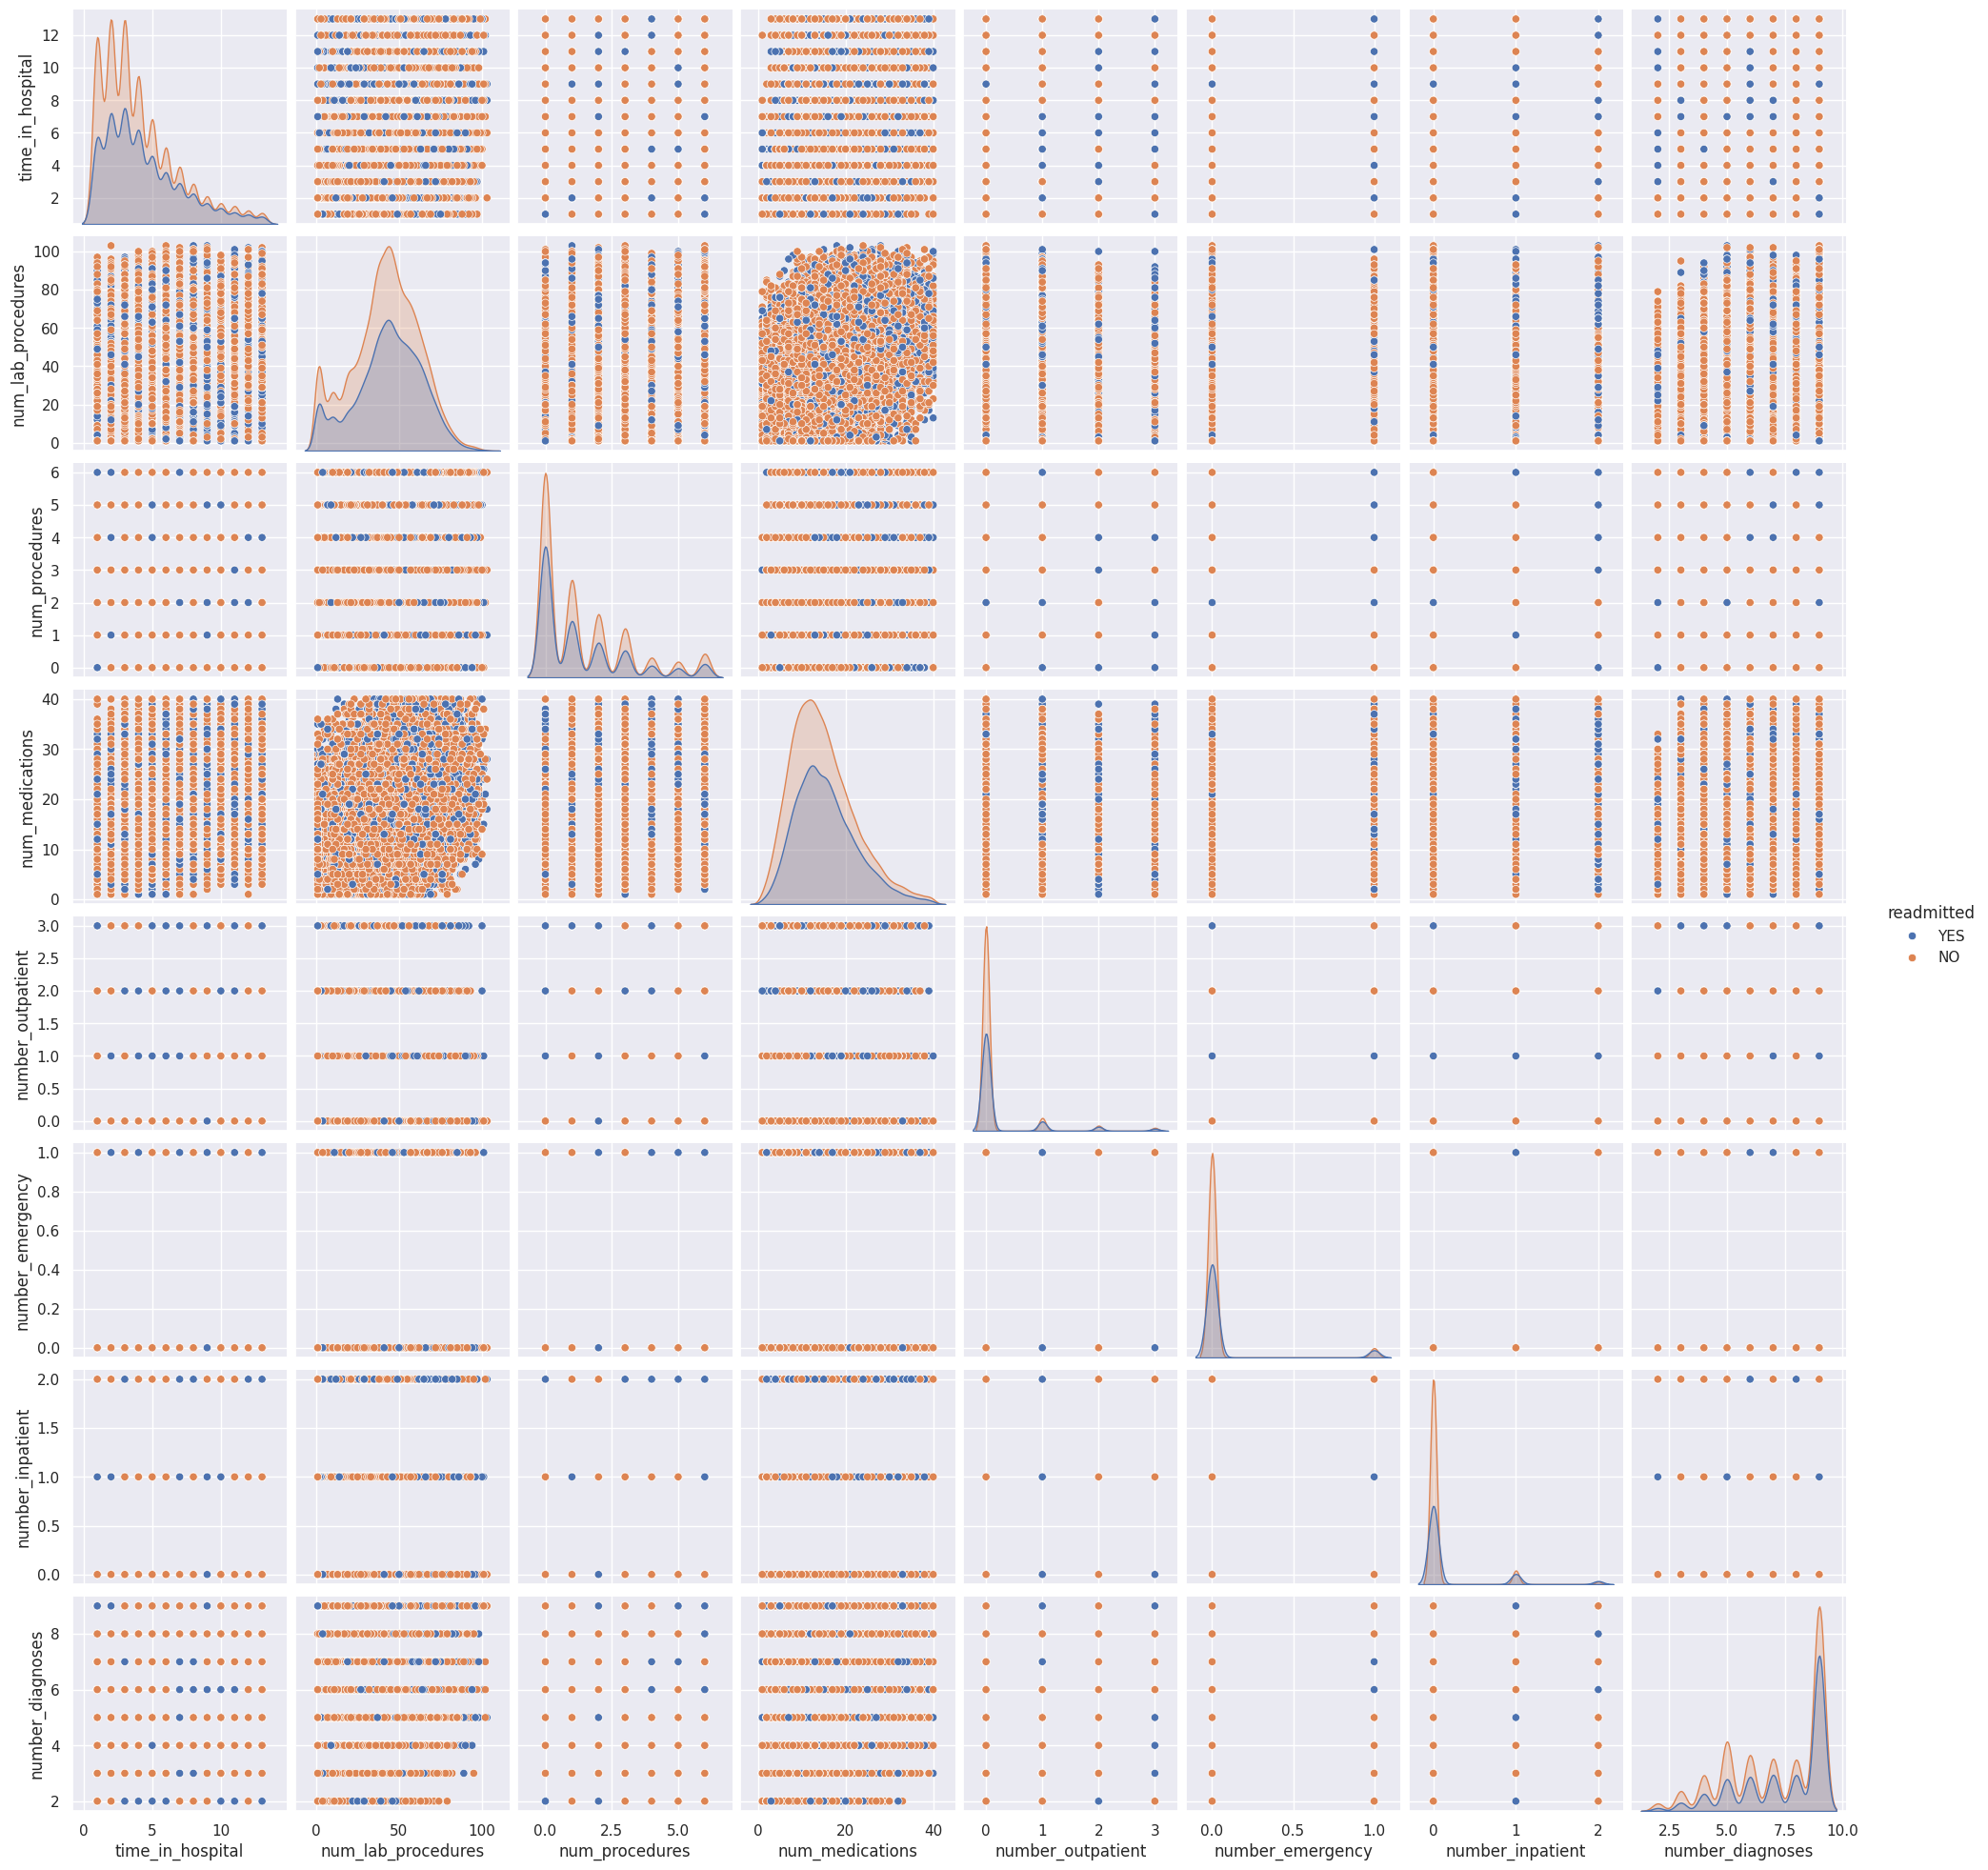

In [98]:
sns.pairplot(df, hue='readmitted');

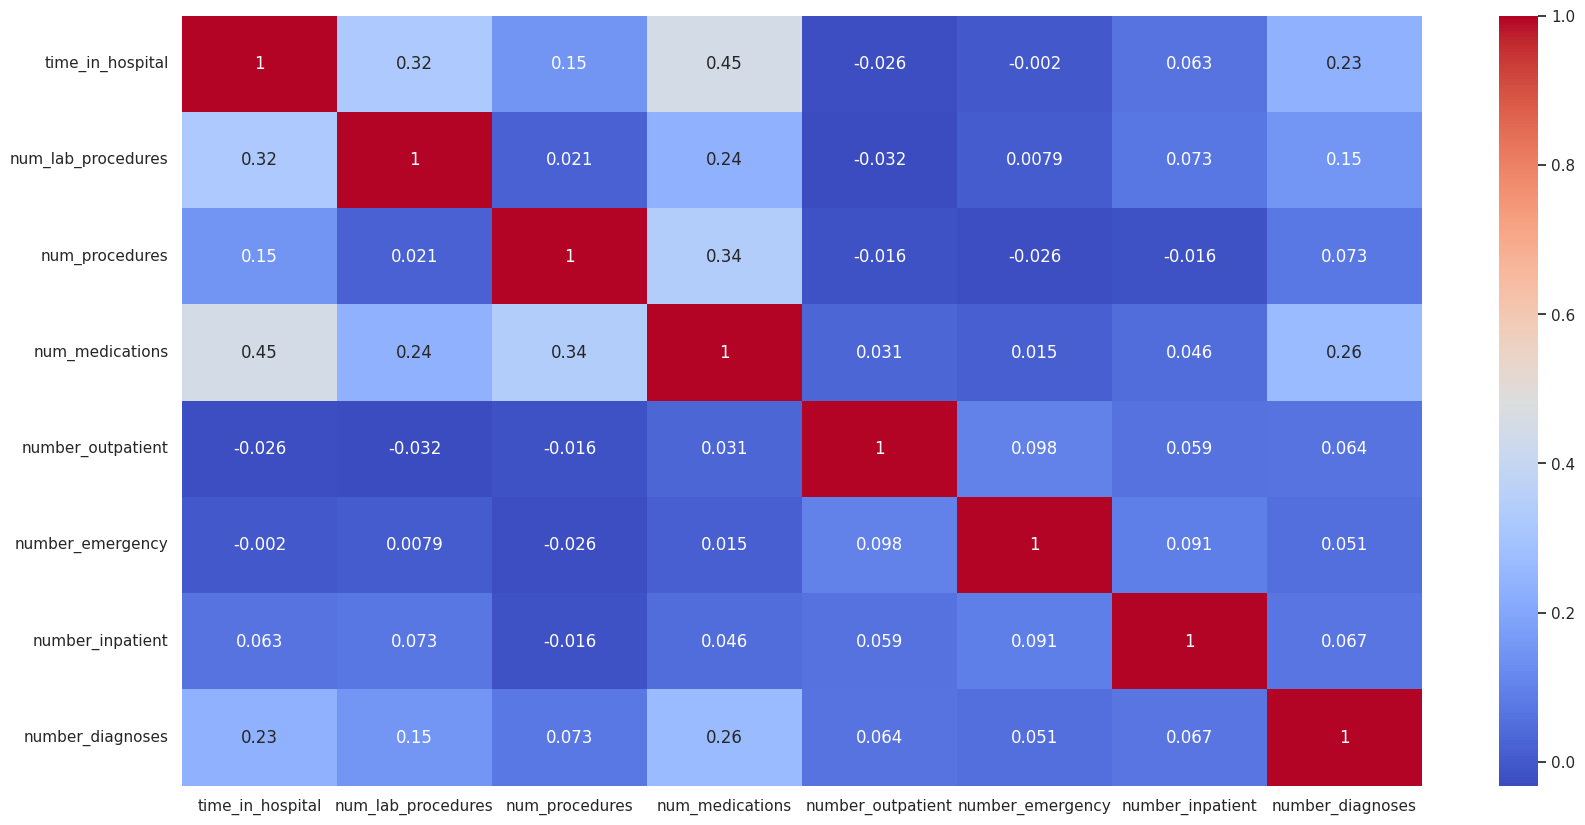

In [99]:
plt.figure(figsize=(20,10))
# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap="coolwarm");

### FOCUS ON "readmitted" patients overall

In [100]:
info('readmitted')

READMITTED : Available

0    YES
1     NO
2     NO
3     NO
4    YES
Name: readmitted, dtype: object


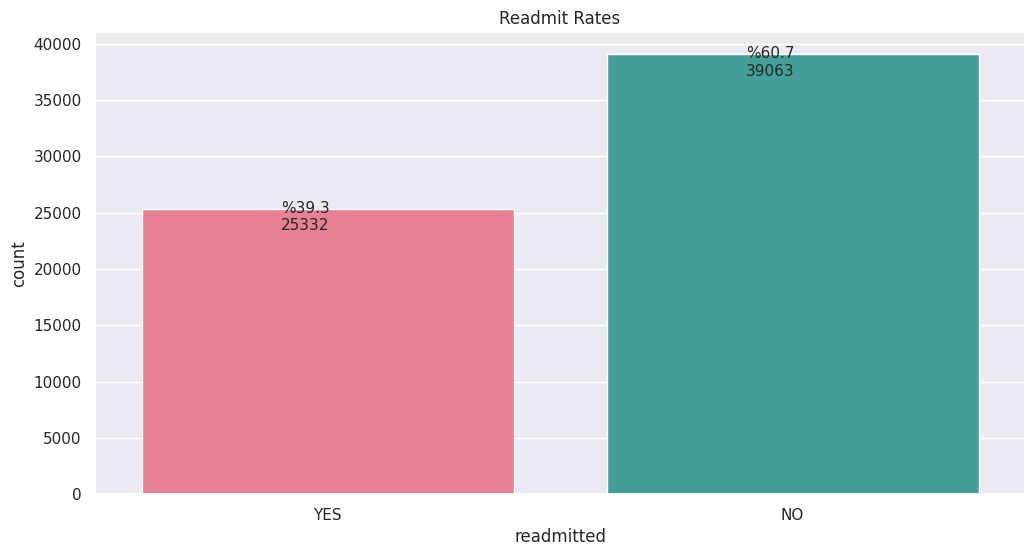

In [101]:
def labels(ax):
    for p in ax.patches:
            ax.annotate('%{:.1f}\n{:.0f}'.format(100*p.get_height()/len(df),p.get_height()),
                        (p.get_x()+0.3, p.get_height()-1900),size=11)

ax = sns.countplot(x='readmitted', palette='husl', data=df)
labels(ax)

# sns.catplot(x='readmitted', kind='count', palette='husl', data=df)  # alternative
plt.title('Readmit Rates')
plt.show()

### FOCUS ON "race"

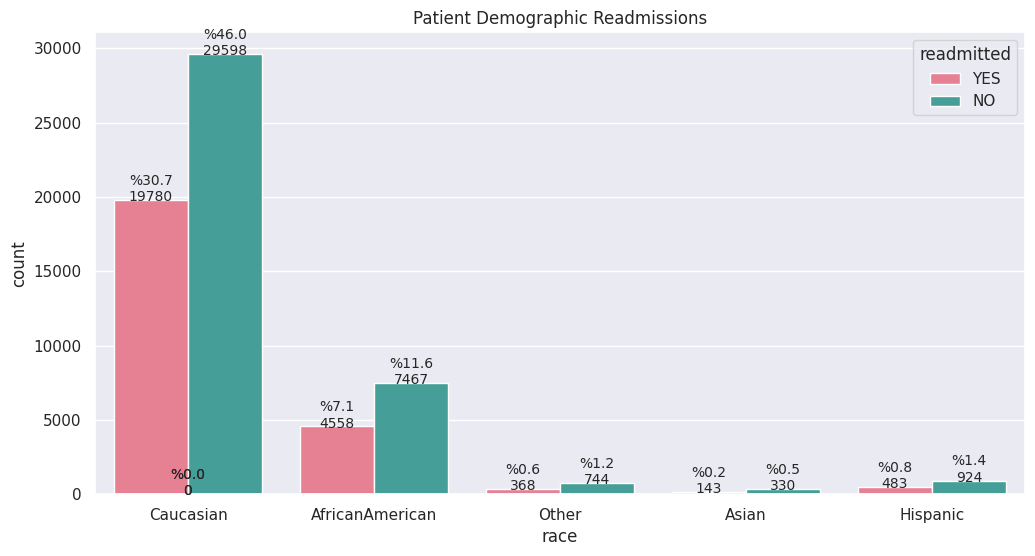

In [102]:
def labels(ax):
    for bar in ax.patches:
        ax.annotate('%{:.1f}\n{:.0f}'.format(100*bar.get_height()/len(df),bar.get_height()), (bar.get_x() + bar.get_width() / 2,
                        bar.get_height()), ha='center', va='center',
                       size=10, xytext=(0, 8),
                       textcoords='offset points')

rcParams['figure.figsize'] = 12,6
ax = sns.countplot(x='race', hue='readmitted', palette='husl', data=df)
labels(ax)
# sns.catplot(x='race', hue='readmitted', kind='count', palette='husl', data=df, aspect=2, legend_out=False)
plt.title('Patient Demographic Readmissions')
plt.show()

In [103]:
pd.crosstab(df.race, df.readmitted, margins=True, margins_name='Total')

readmitted,NO,YES,Total
race,,,
AfricanAmerican,7467,4558,12025
Asian,330,143,473
Caucasian,29598,19780,49378
Hispanic,924,483,1407
Other,744,368,1112
Total,39063,25332,64395


### FOCUS ON "gender"

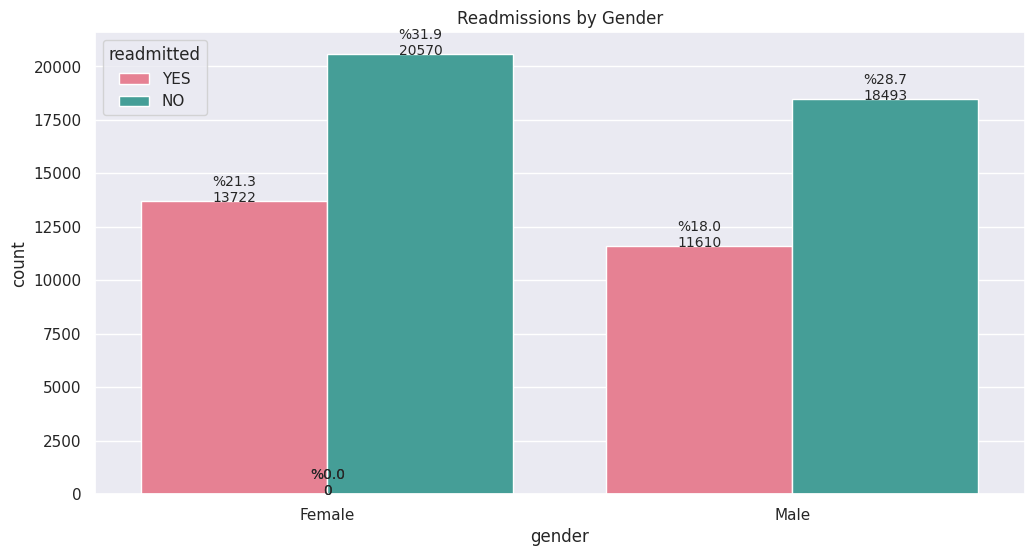

In [104]:
rcParams['figure.figsize'] = 12,6
ax = sns.countplot(x='gender', hue='readmitted', palette='husl', data=df)
labels(ax)
plt.title('Readmissions by Gender')
plt.show()

In [105]:
pd.crosstab(df.gender, df.readmitted, margins=True, margins_name='Total')

readmitted,NO,YES,Total
gender,,,
Female,20570,13722,34292
Male,18493,11610,30103
Total,39063,25332,64395


### FOCUS ON "age" groups

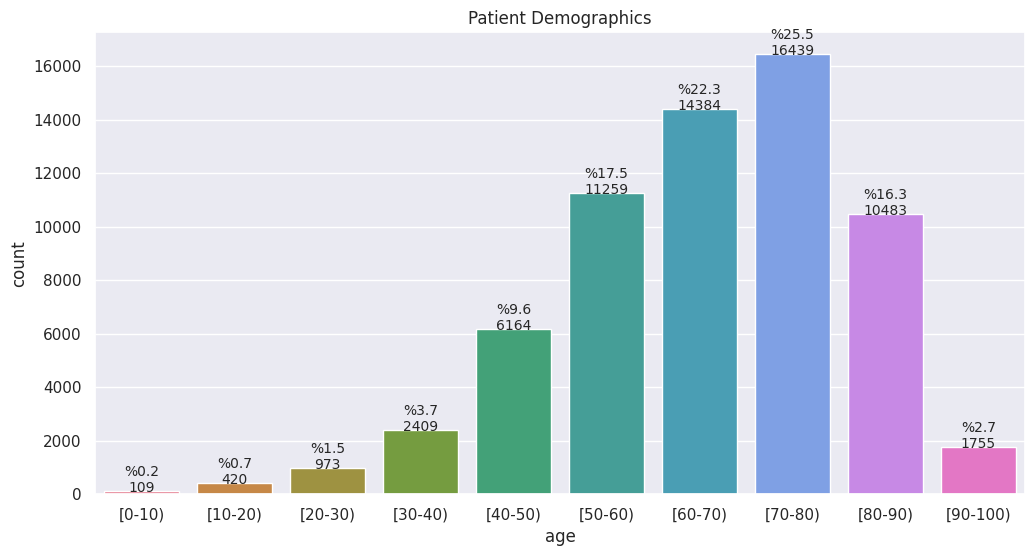

In [106]:
ax = sns.countplot(x='age', palette='husl', data=df.sort_values('age'))
labels(ax)
plt.title('Patient Demographics')
plt.show()

> It looks like most patients are older, 50+ years old, though there aren't many patients over 90.

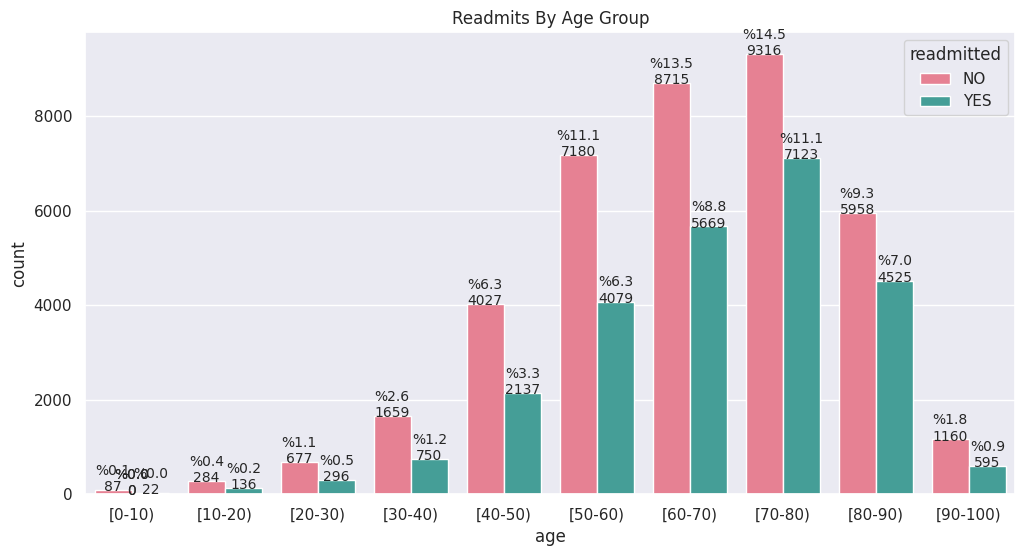

In [107]:
ax = sns.countplot(x='age', hue='readmitted', palette='husl', data=df.sort_values('age'))
labels(ax)
plt.title('Readmits By Age Group')
plt.show()

In [108]:
pd.crosstab(df.age, df.readmitted, margins=True, margins_name='Total').T

age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100),Total
readmitted,,,,,,,,,,,
NO,87,284,677,1659,4027,7180,8715,9316,5958,1160,39063
YES,22,136,296,750,2137,4079,5669,7123,4525,595,25332
Total,109,420,973,2409,6164,11259,14384,16439,10483,1755,64395


>In every age group, more patients are not readmitted. The 70-80 age group account has the highest number of readmitted and not readmitted patients.

### FOCUS ON "time_in_hospital"

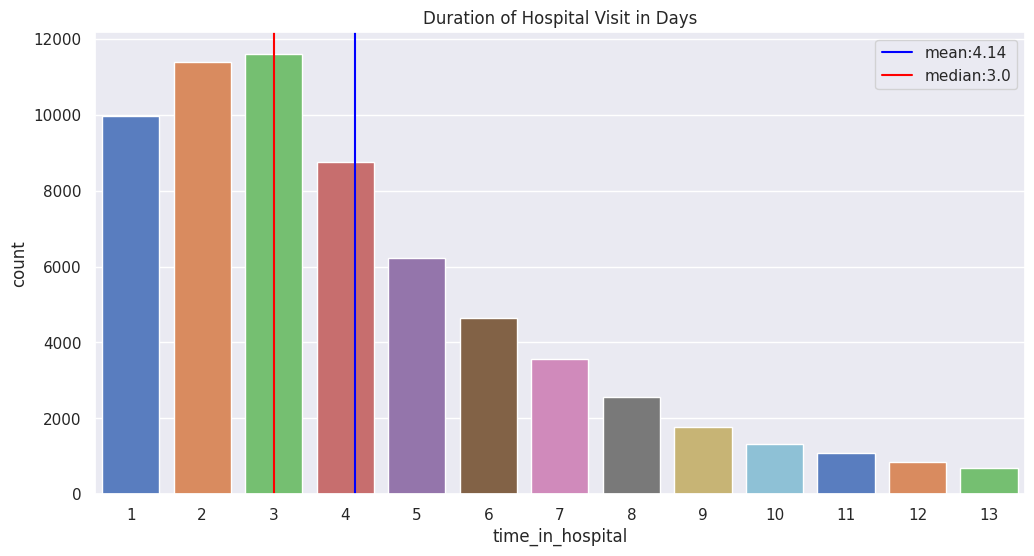

In [109]:
sns.countplot(x='time_in_hospital', palette='muted', data=df)
mean, median = np.mean(df.time_in_hospital), np.median(df.time_in_hospital)
plt.axvline(mean-df.time_in_hospital.min(), color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median-df.time_in_hospital.min(), color='red', label=f'median:{round(median,2)}')
plt.title('Duration of Hospital Visit in Days')
plt.legend()
plt.show()

> **Does the amount of time spent in the hospital impact a patient's chances of readmission?**

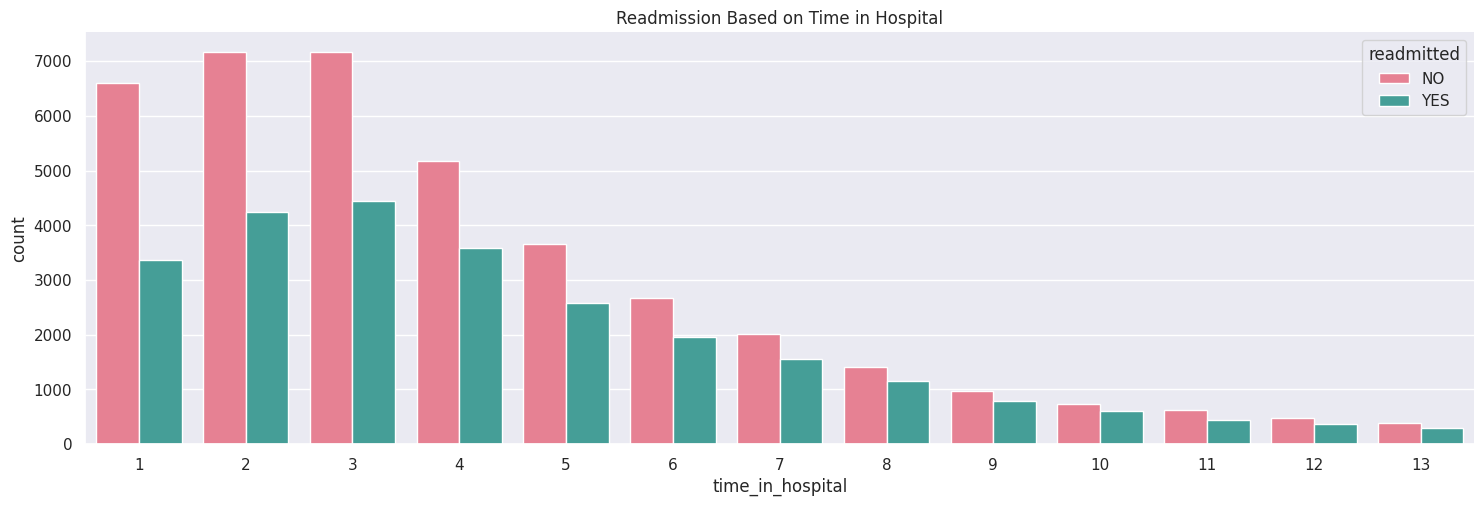

In [110]:
sns.catplot(x='time_in_hospital', hue='readmitted', kind='count', palette='husl', aspect=3, data=df, legend_out=False)
plt.title('Readmission Based on Time in Hospital')
plt.show()

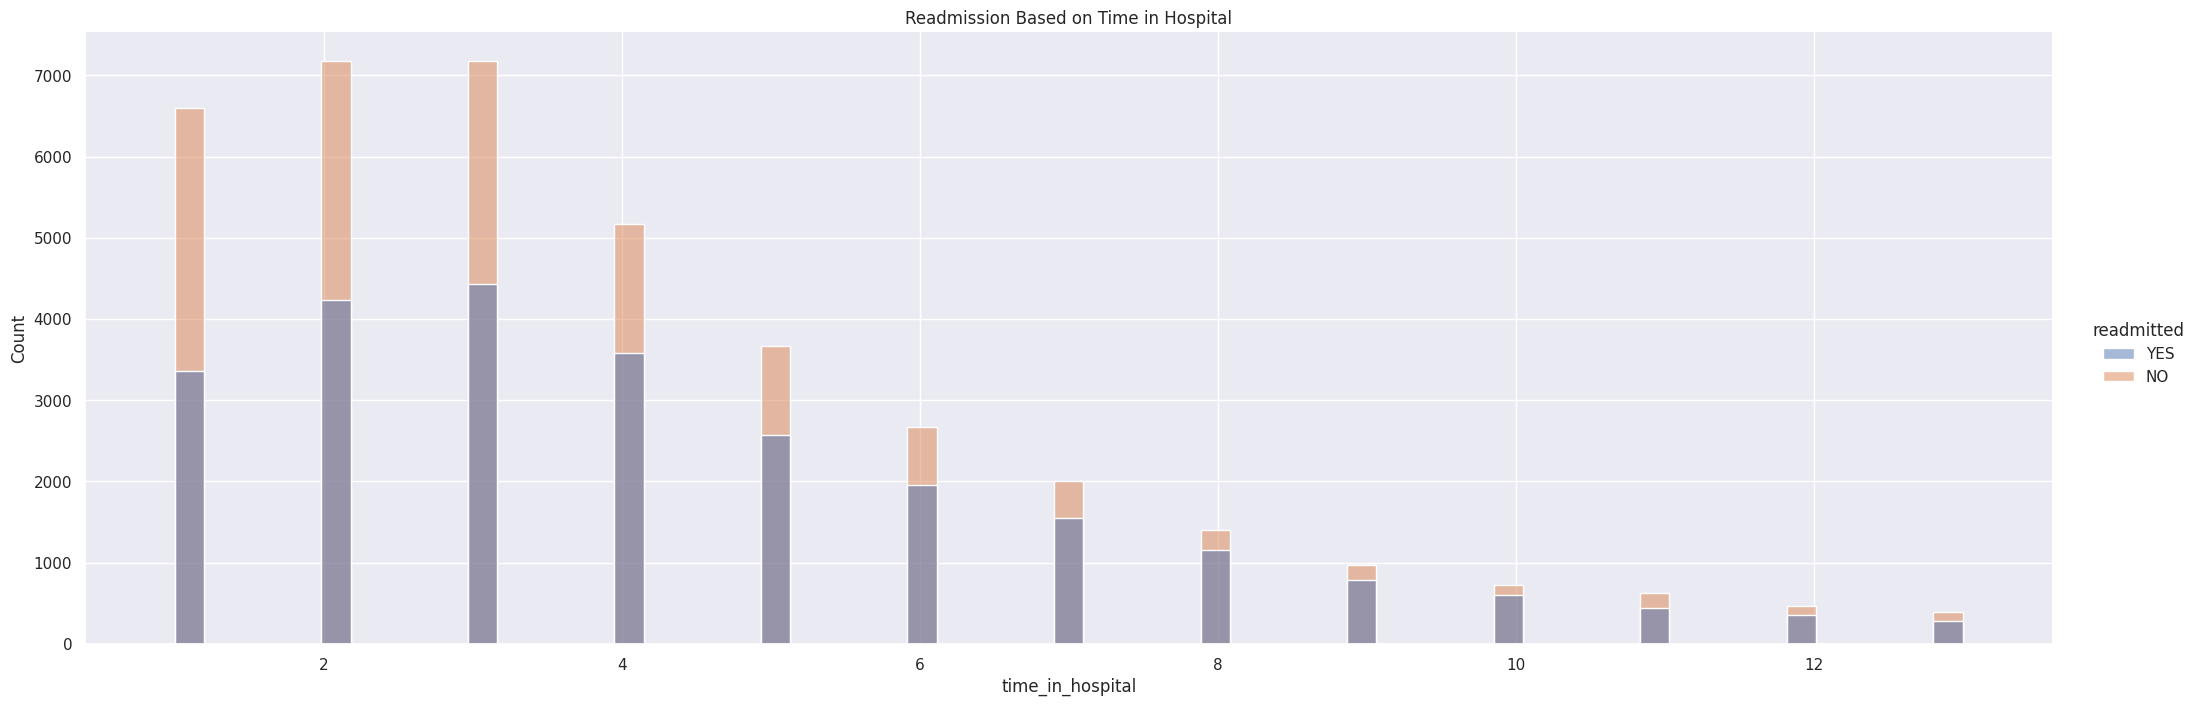

In [111]:
sns.displot(x='time_in_hospital', hue='readmitted', data=df, height=7, aspect=3)
plt.title('Readmission Based on Time in Hospital')
plt.show()

> Based on the graph, the longer a patient spends in the hospital, the likelier their chances are of being readmitted. Patients who spend more than a week in the hospital usually have a serious illness or complication that may reoccur depending on their ability to recover, which is why they may need to revisit the hospital.

> **Which age group is spending the most time in hospitals during visits?**

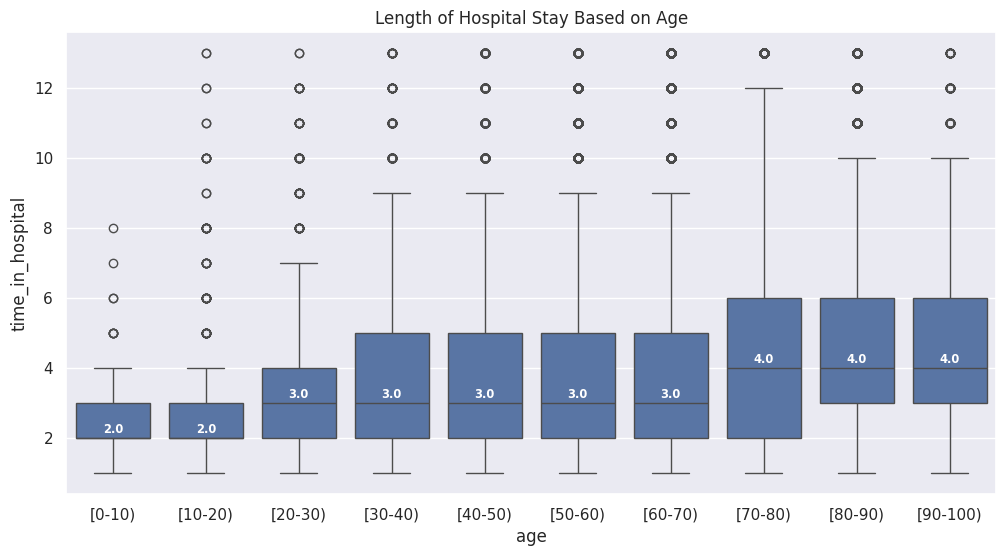

In [112]:
def box_labels(ax, df,col1,col2):
    medians = df.groupby([col1])[col2].median()
    vertical_offset = df[col2].median() * 0.05 # offset from median for display

    for xtick in ax.get_xticks():
        ax.text(xtick,medians[xtick] + vertical_offset,medians[xtick],
                horizontalalignment='center',size='x-small',color='w',weight='semibold')

ax = sns.boxplot(x='age', y='time_in_hospital', data=df.sort_values('age'))
box_labels(ax, df.sort_values('age'),'age','time_in_hospital')
plt.title('Length of Hospital Stay Based on Age')
plt.show()

> **What is the comparison of time in hospital for readmitted patients?**

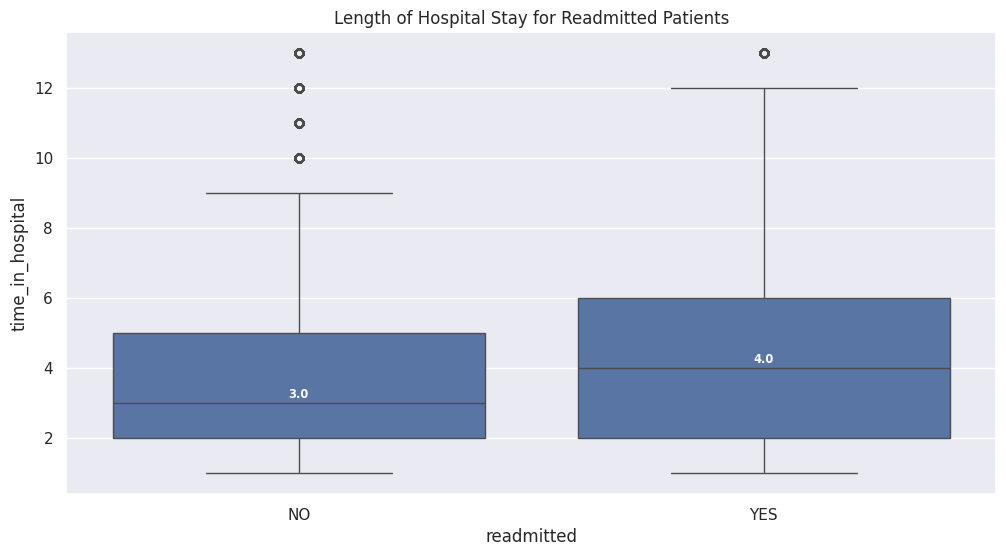

In [113]:
ax = sns.boxplot(x='readmitted', y='time_in_hospital', data=df.sort_values('readmitted'))
box_labels(ax, df.sort_values('readmitted'),'readmitted','time_in_hospital')
plt.title('Length of Hospital Stay for Readmitted Patients')
plt.show()

> Readmitted patients stay longer in the hospital on average compared to those who are not readmitted.

### FOCUS ON "number of lab procedures`

In [114]:
info("num_lab_procedures")

NUM_LAB_PROCEDURES : Available

0    59
1    11
2    44
3    51
4    31
Name: num_lab_procedures, dtype: int64


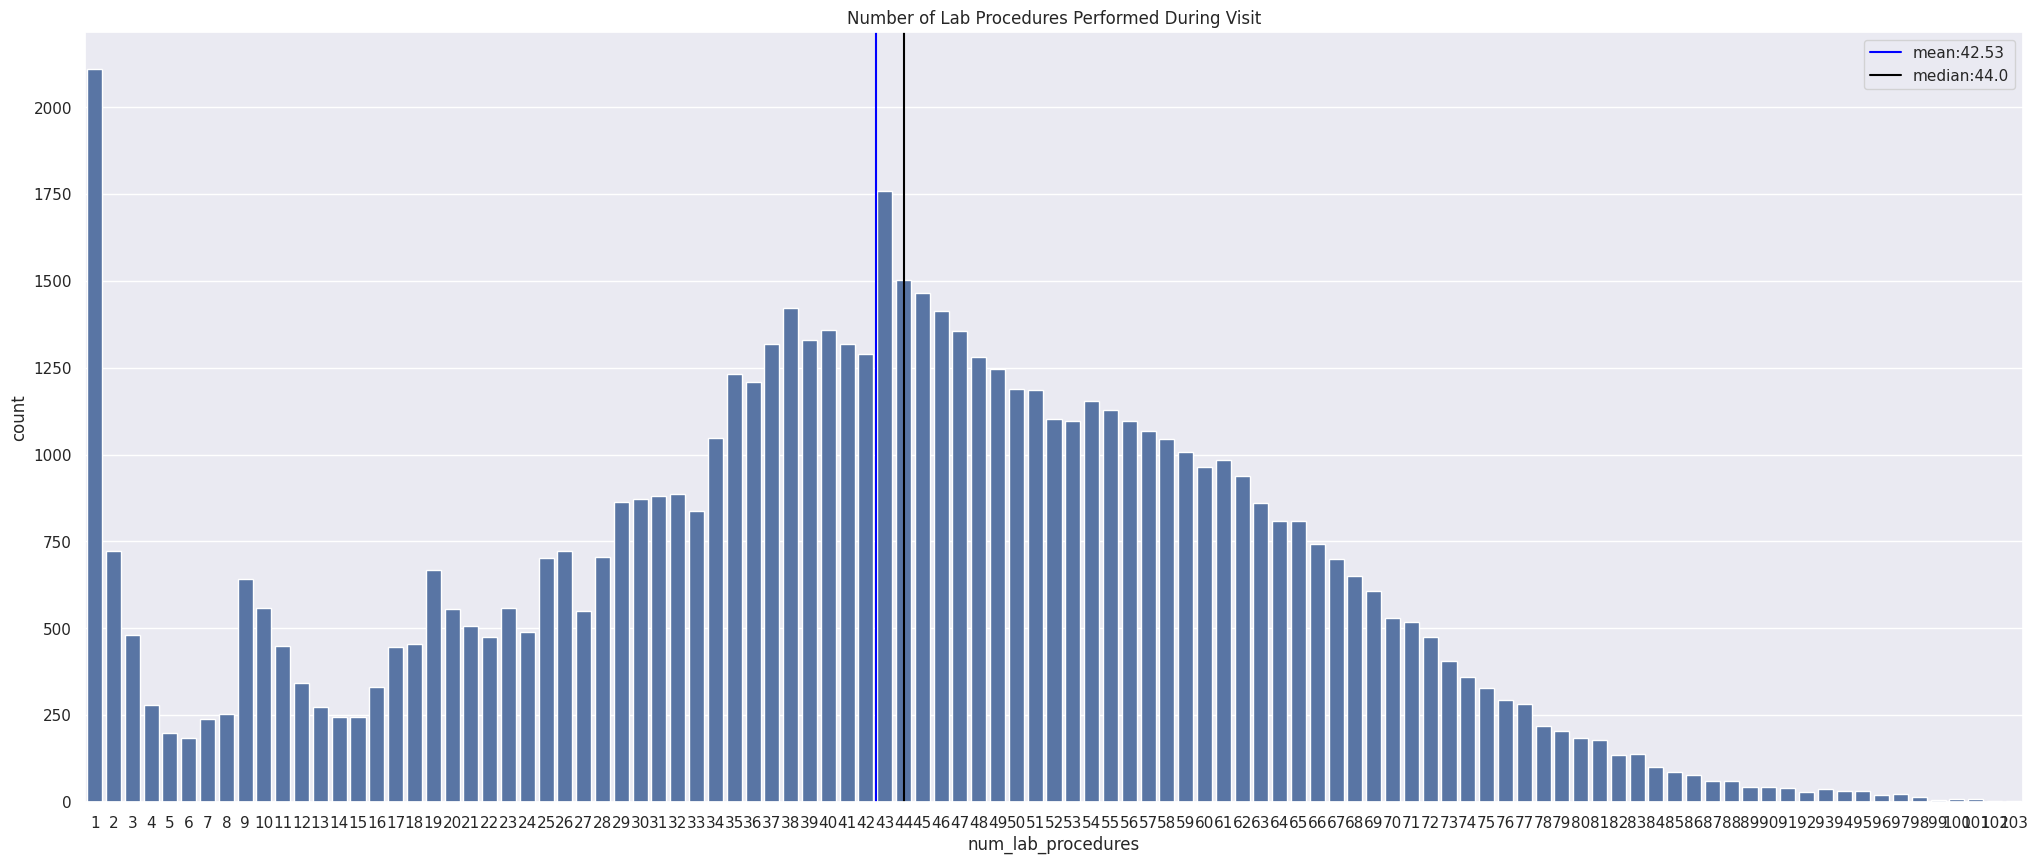

In [115]:
rcParams['figure.figsize'] = 25,10
sns.countplot(x='num_lab_procedures', data=df)
mean, median = np.mean(df.num_lab_procedures), np.median(df.num_lab_procedures)
plt.axvline(mean-df.num_lab_procedures.min(), color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median-df.num_lab_procedures.min(), color='black', label=f'median:{round(median,2)}')
plt.title('Number of Lab Procedures Performed During Visit')
plt.legend()
plt.show()

In [116]:
df.groupby('readmitted')['num_lab_procedures'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
NO,39063.0,41.87,19.85,1.0,30.0,43.0,56.0,103.0
YES,25332.0,43.56,19.78,1.0,32.0,45.0,58.0,103.0


> **Do the patients with longer hospital stays have more lab tests?**

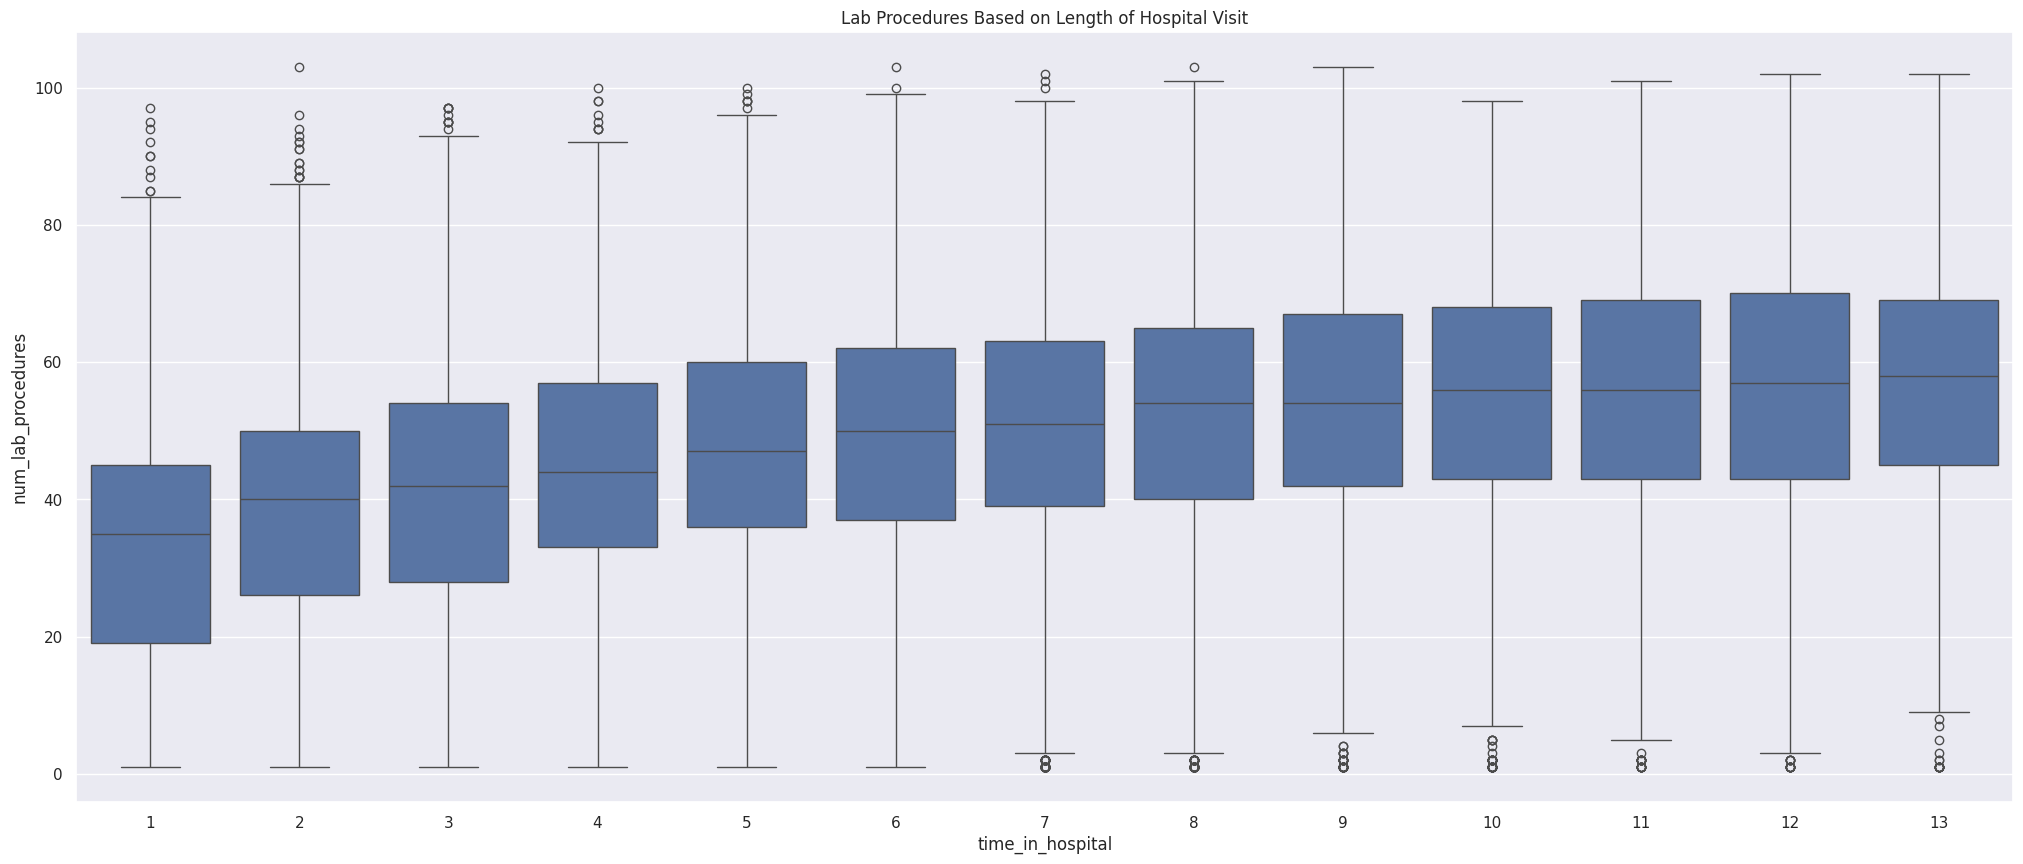

In [117]:
def box_labels(ax, df,col1,col2):
    medians = df.groupby([col1])[col2].median()
    vertical_offset = df[col2].median() * 0.05 # offset from median for display

    for xtick in ax.get_xticks():
        ax.text(xtick,medians[xtick] + vertical_offset,medians[xtick],
                horizontalalignment='center',size=12,color='w',weight='semibold')

ax = sns.boxplot(x='time_in_hospital', y='num_lab_procedures', data=df.sort_values('time_in_hospital'))
# box_labels(ax, df.sort_values('time_in_hospital'),'time_in_hospital','num_lab_procedures')
plt.title('Lab Procedures Based on Length of Hospital Visit')
plt.show()

* There is a positive correlation between time spent in the hospital and number of lab tests completed.
* This makes sense since patients with longer stays had more tests completed to properly diagnose their conditions.

> **Do readmitted patients have more lab tests?**

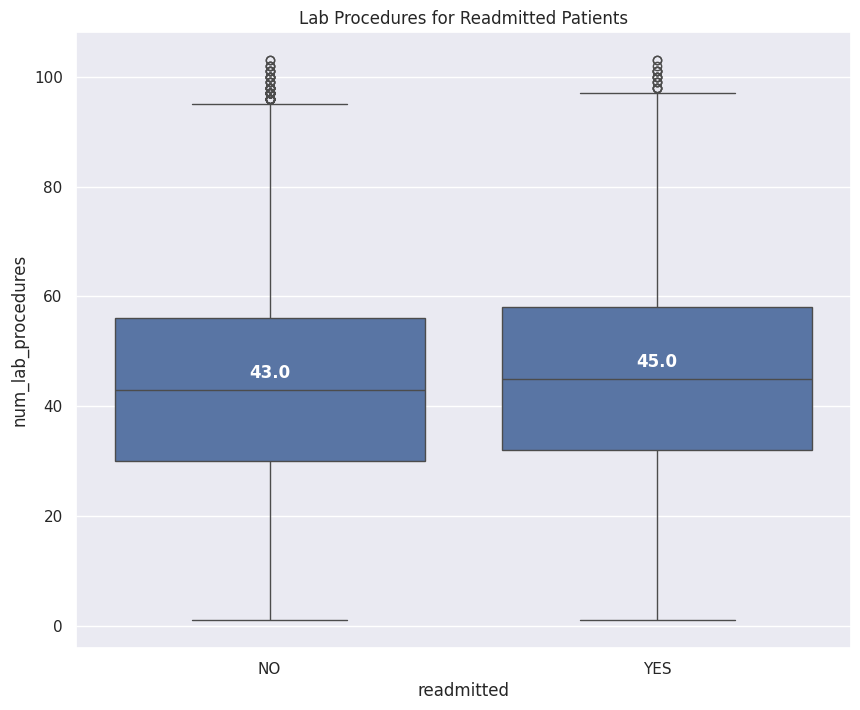

In [118]:
plt.figure(figsize=(10, 8))
ax = sns.boxplot(x='readmitted', y='num_lab_procedures', data=df.sort_values('readmitted'))
box_labels(ax, df.sort_values('readmitted'),'readmitted','num_lab_procedures')
plt.title('Lab Procedures for Readmitted Patients')
plt.show()

* The average number of lab procedures is about equal for readmitted and not readmitted patients.
* Not readmitted patients have a slightly lower number of lab procedures done during their visit.

### FOCUS ON "`number of procedures`" (other than lab)

In [119]:
info('num_procedures')

NUM_PROCEDURES : Available

0    0
1    5
2    1
3    0
4    6
Name: num_procedures, dtype: int64


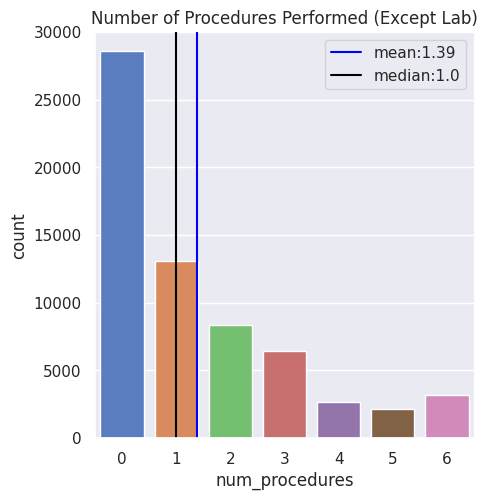

In [120]:
sns.catplot(x='num_procedures', kind='count', palette='muted', data=df)
mean, median = np.mean(df.num_procedures), np.median(df.num_procedures)
plt.axvline(mean, color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median, color='black', label=f'median:{round(median,2)}')
plt.title('Number of Procedures Performed (Except Lab)')
plt.legend()
plt.show()

> **Do the number of tests performed indicate whether a patient will be readmitted?**

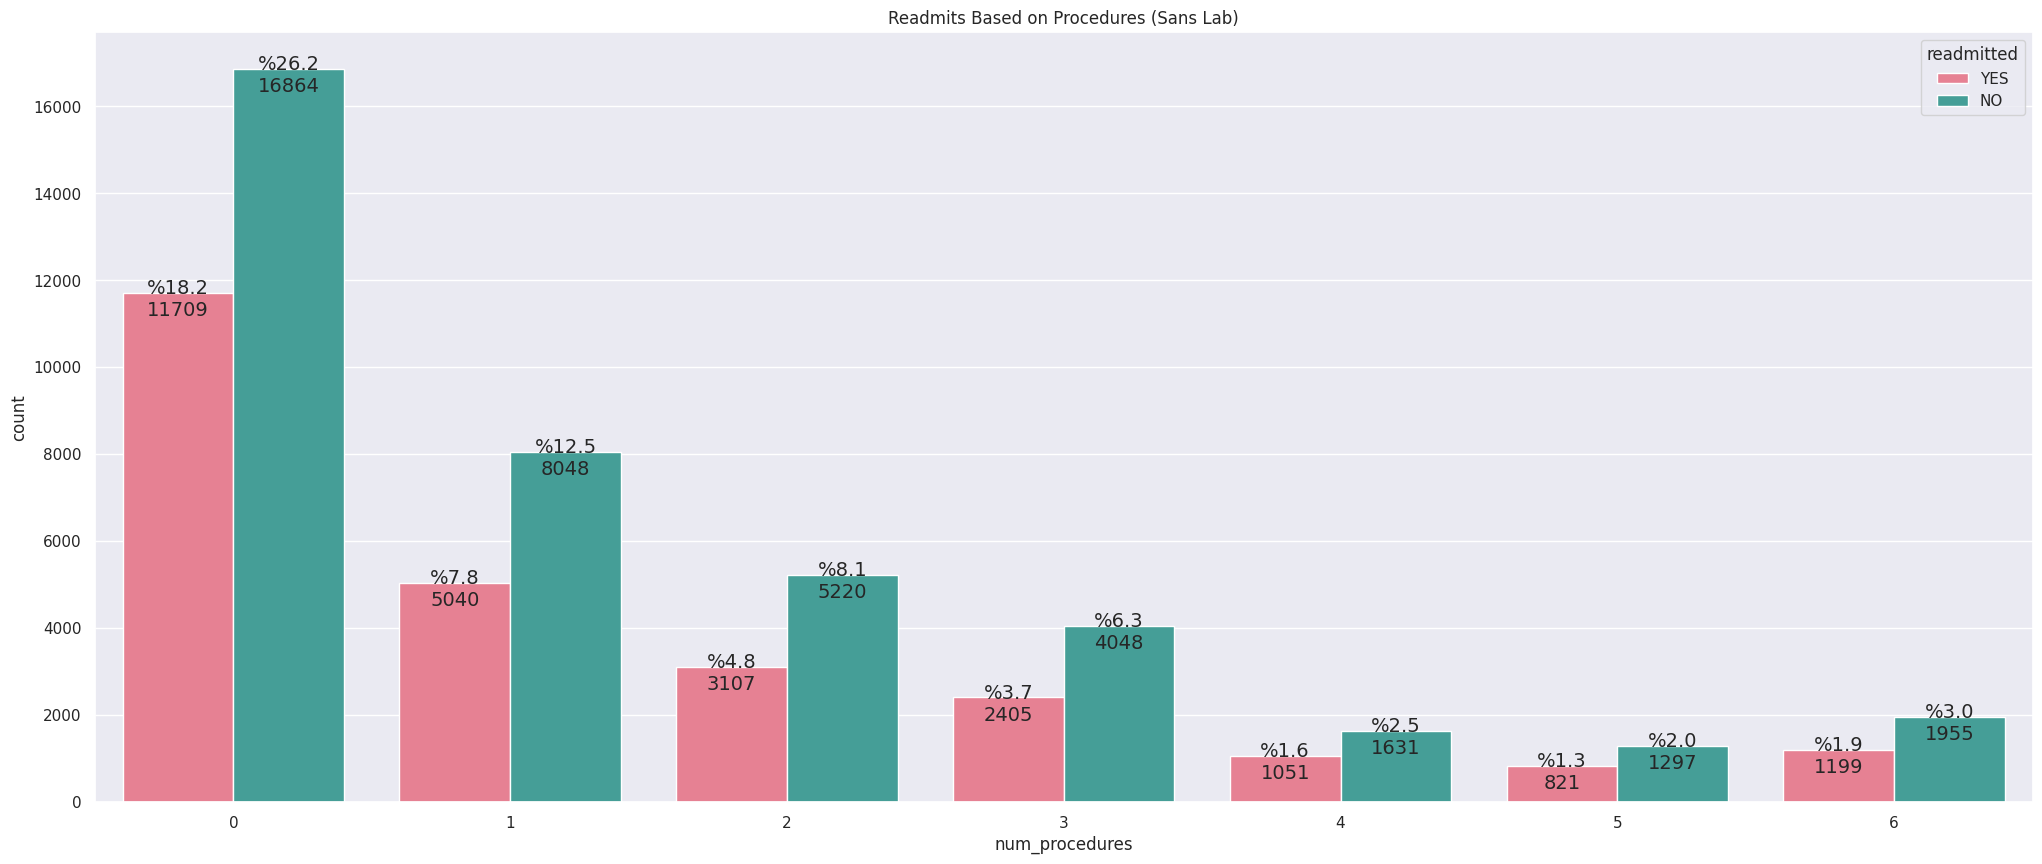

In [121]:
def labels(ax):
    for bar in ax.patches:
        ax.annotate('%{:.1f}\n{:.0f}'.format(100*bar.get_height()/len(df),bar.get_height()), (bar.get_x() + bar.get_width() / 2,
                        bar.get_height()-400), ha='center', va='center',
                       size=14, xytext=(0, 8),
                       textcoords='offset points')

ax = sns.countplot(x='num_procedures', hue='readmitted', palette='husl', data=df)
labels(ax)
plt.title('Readmits Based on Procedures (Sans Lab)')
plt.show()

### FOCUS ON "number of medications"

In [122]:
info('num_medications')

NUM_MEDICATIONS : Available

0    18
1    13
2    16
3     8
4    16
Name: num_medications, dtype: int64


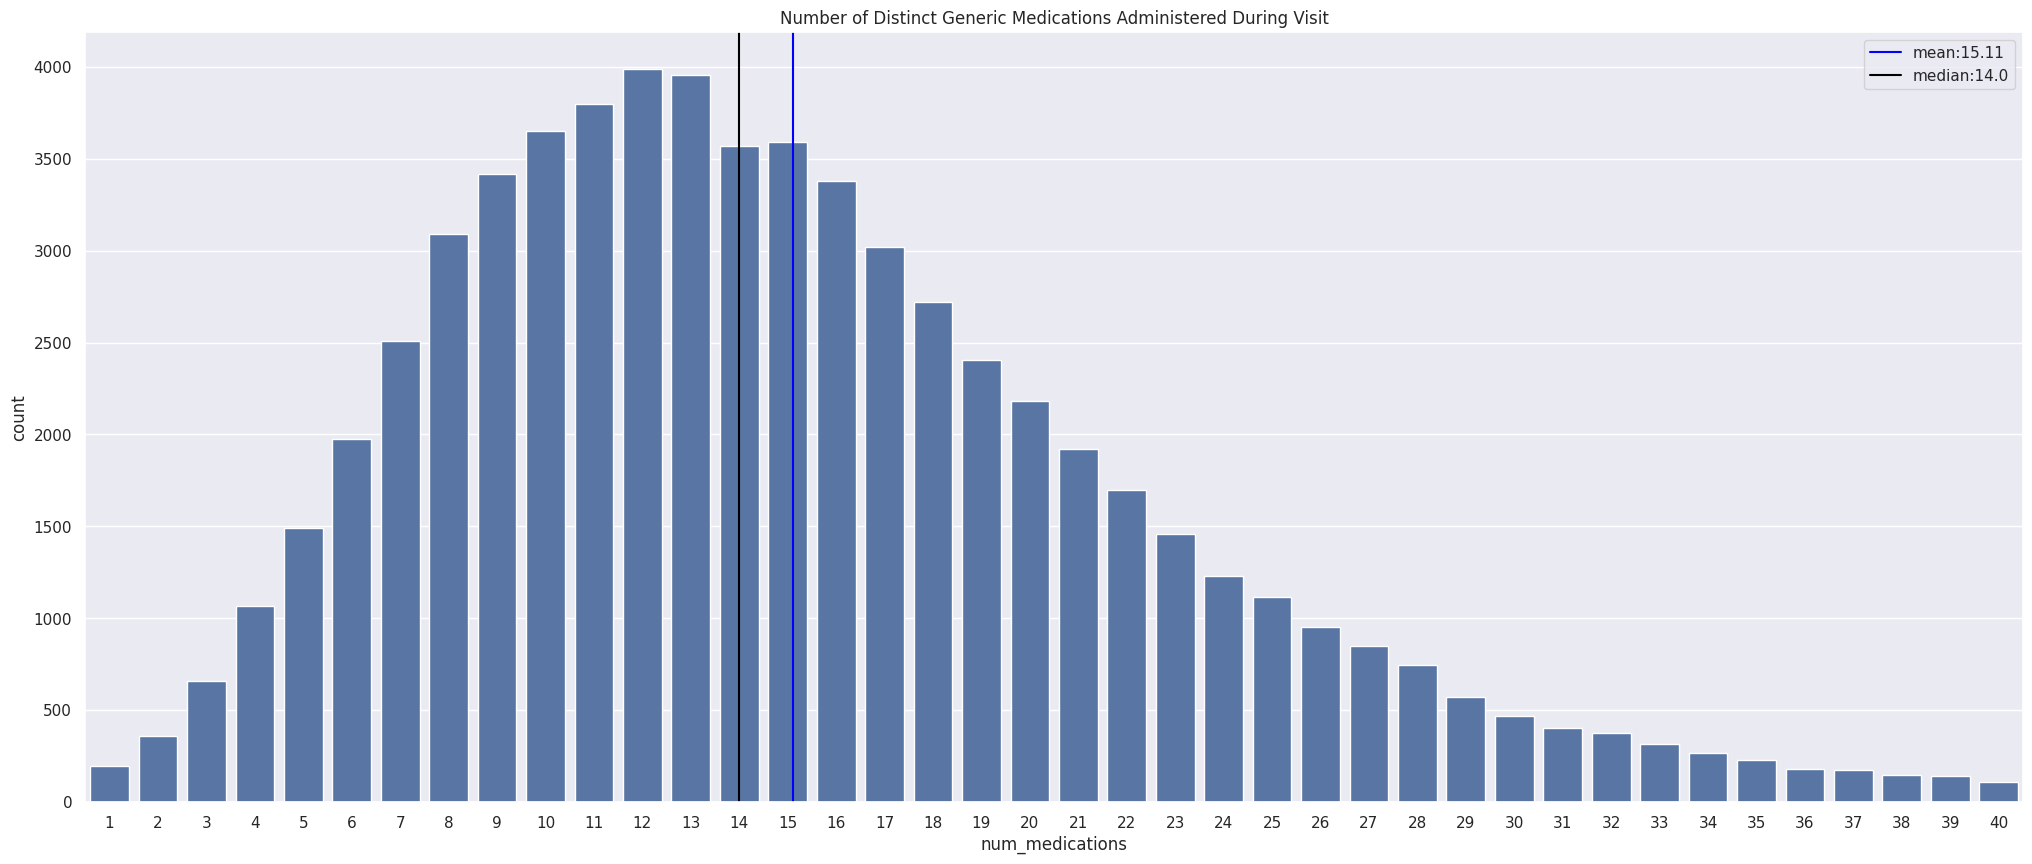

In [123]:
rcParams['figure.figsize'] = 25,10
sns.countplot(x='num_medications', data=df)
mean, median = np.mean(df.num_medications), np.median(df.num_medications)
plt.axvline(mean-df.num_medications.min(), color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median-df.num_medications.min(), color='black', label=f'median:{round(median,2)}')
plt.title('Number of Distinct Generic Medications Administered During Visit')
plt.legend()
plt.show()

In [124]:
df.groupby('readmitted')['num_medications'].describe()

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
NO,39063.0,14.833039,7.302302,1.0,10.0,14.0,19.0,40.0
YES,25332.0,15.544568,7.024022,1.0,10.0,15.0,20.0,40.0


> **How many medications are patients receiving during their visit?**

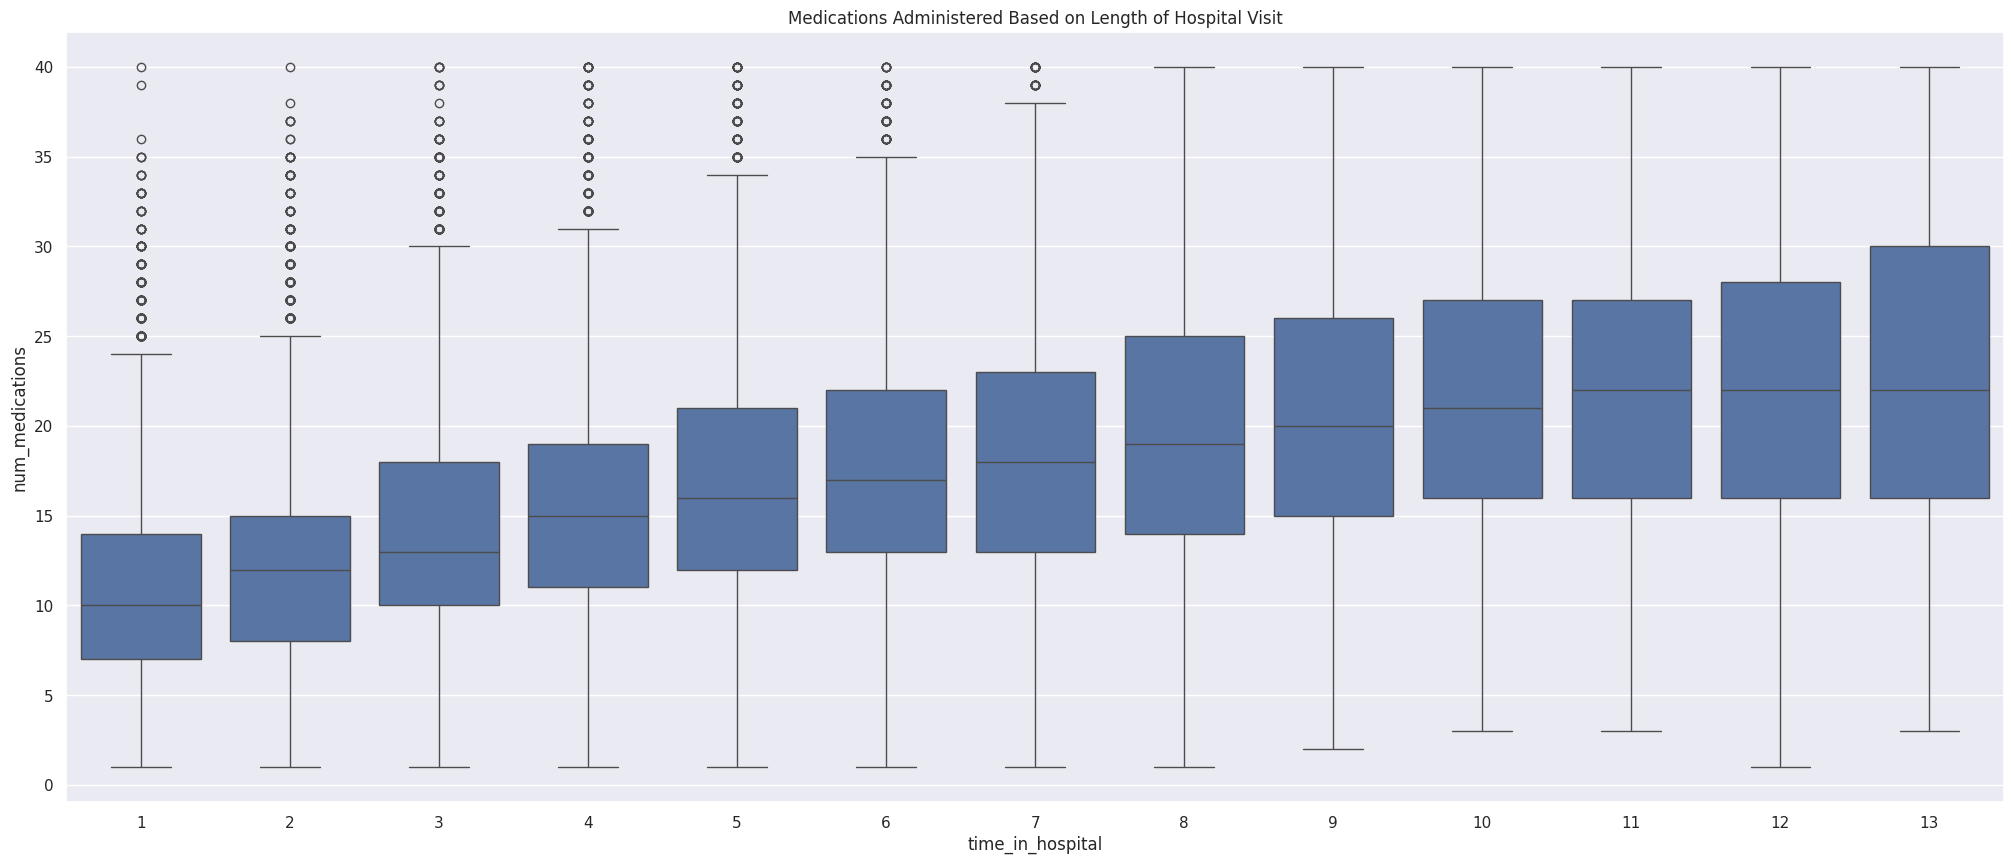

In [125]:
ax = sns.boxplot(x='time_in_hospital', y='num_medications', data=df)
# box_labels(ax, df.sort_values('time_in_hospital'),'time_in_hospital','num_medications')
plt.title('Medications Administered Based on Length of Hospital Visit')
plt.show()

> Patients who spend more time in the hospital receive more medications, but there are a few that receive over 60 different kinds of medications.

> **How many medications are patients receiving during their visit?**

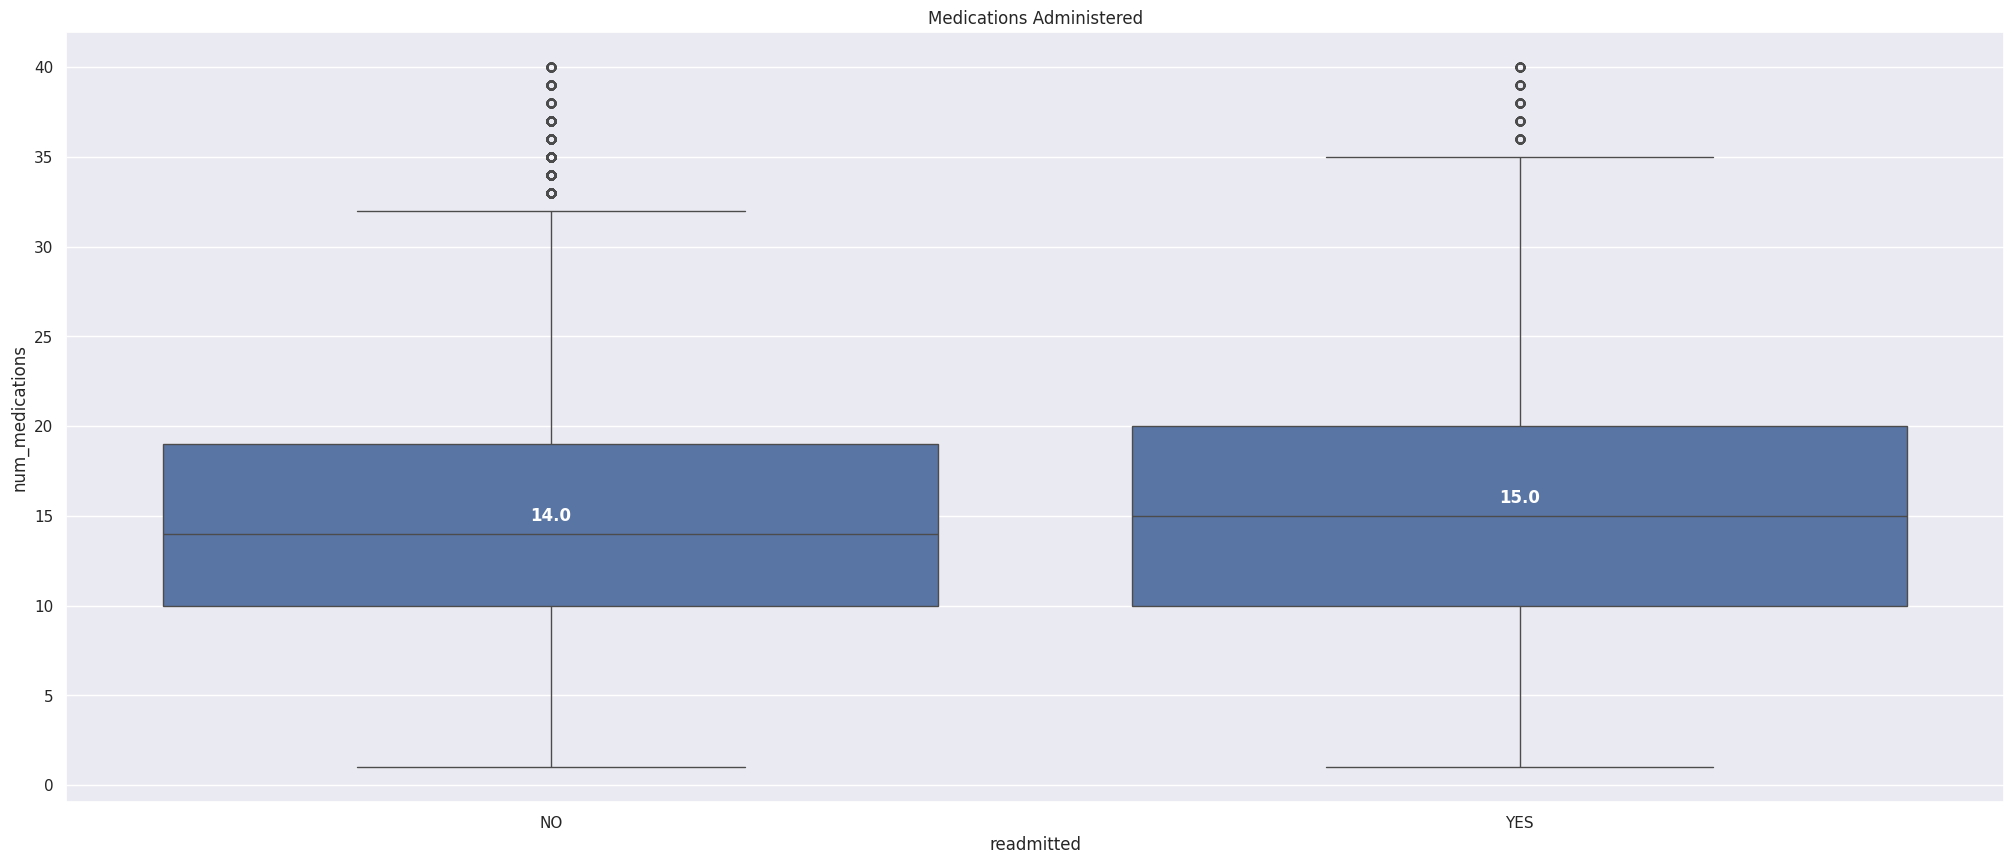

In [126]:
ax = sns.boxplot(x='readmitted', y='num_medications', data=df.sort_values('readmitted'))
box_labels(ax, df.sort_values('readmitted'),'readmitted','num_medications')
plt.title('Medications Administered')
plt.show()

> The distribution is almost equal for readmitted and not readmitted patients, with readmits being slightly higher on average.

### FOCUS ON "`number of outpatient`" visits

In [127]:
info('number_outpatient')

NUMBER_OUTPATIENT : Available

0    0
1    2
2    0
3    0
4    0
Name: number_outpatient, dtype: int64


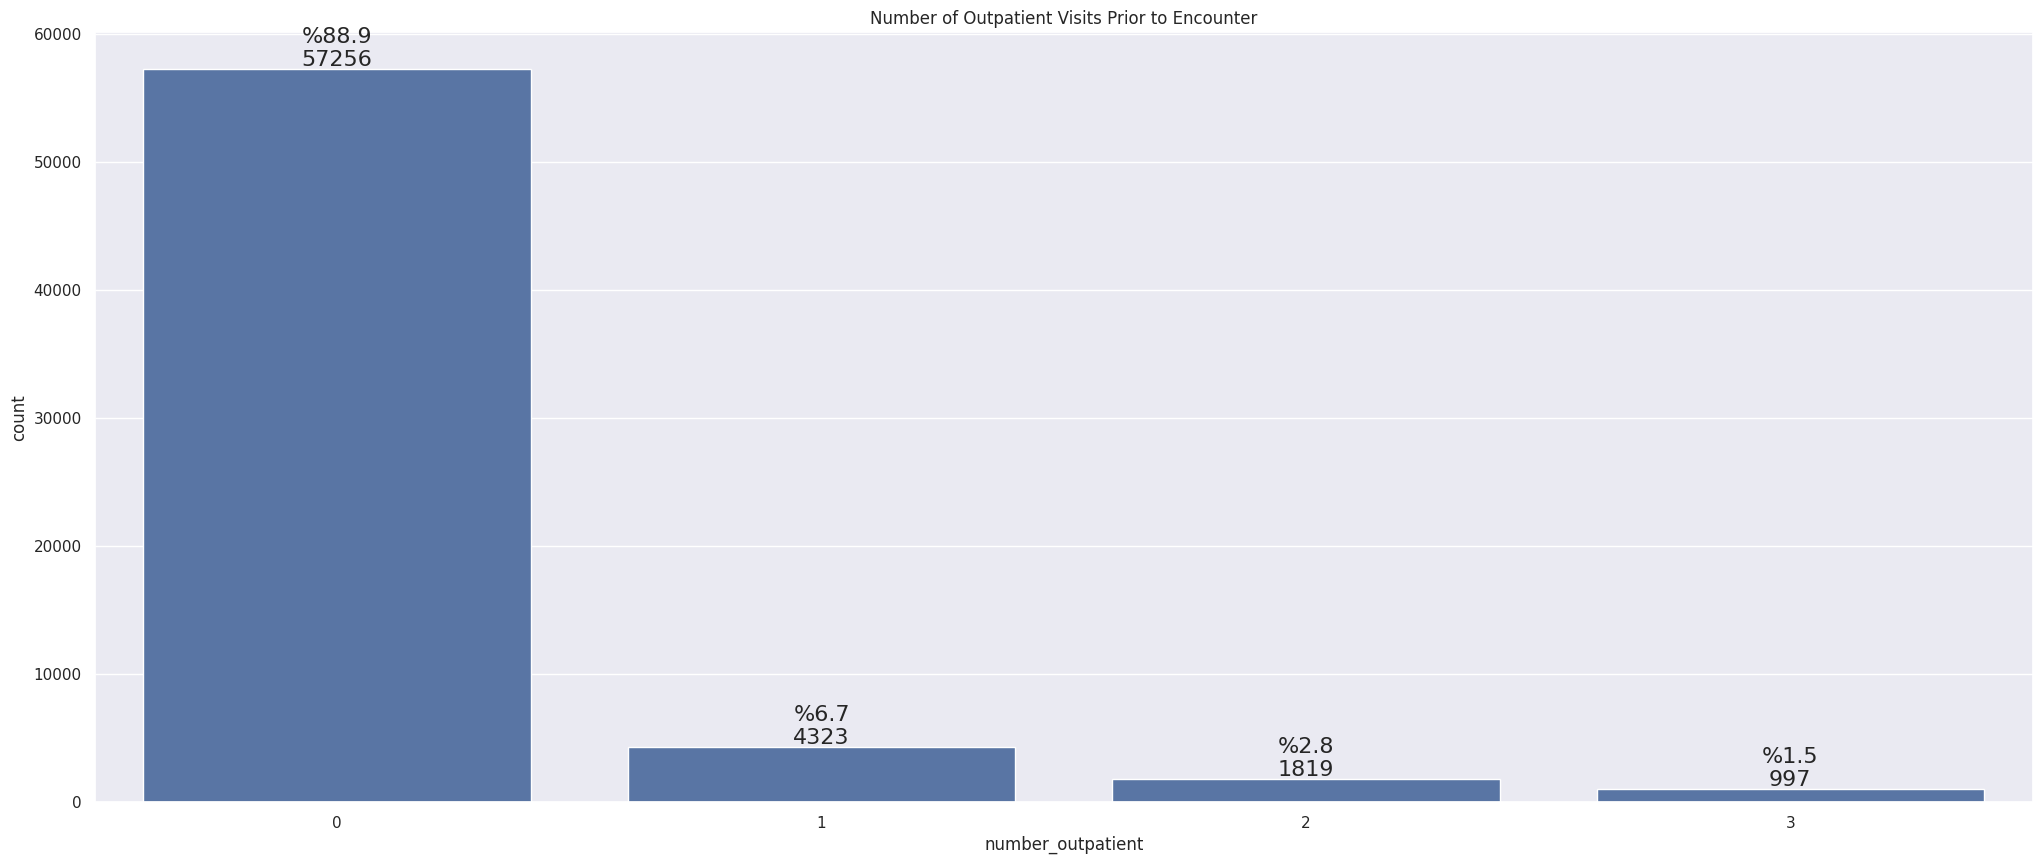

In [128]:
def labels(ax):
    for bar in ax.patches:
        ax.annotate('%{:.1f}\n{:.0f}'.format(100*bar.get_height()/len(df),bar.get_height()), (bar.get_x() + bar.get_width() / 2,
                        bar.get_height()+750), ha='center', va='center',
                       size=16, xytext=(0, 8),
                       textcoords='offset points')

ax = sns.countplot(x='number_outpatient',data=df)
labels(ax)
plt.title('Number of Outpatient Visits Prior to Encounter')
plt.show()

In [129]:
# outpatient visit stats
df.groupby('readmitted')['number_outpatient'].describe()

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
NO,39063.0,0.143128,0.499008,0.0,0.0,0.0,0.0,3.0
YES,25332.0,0.211630,0.593094,0.0,0.0,0.0,0.0,3.0


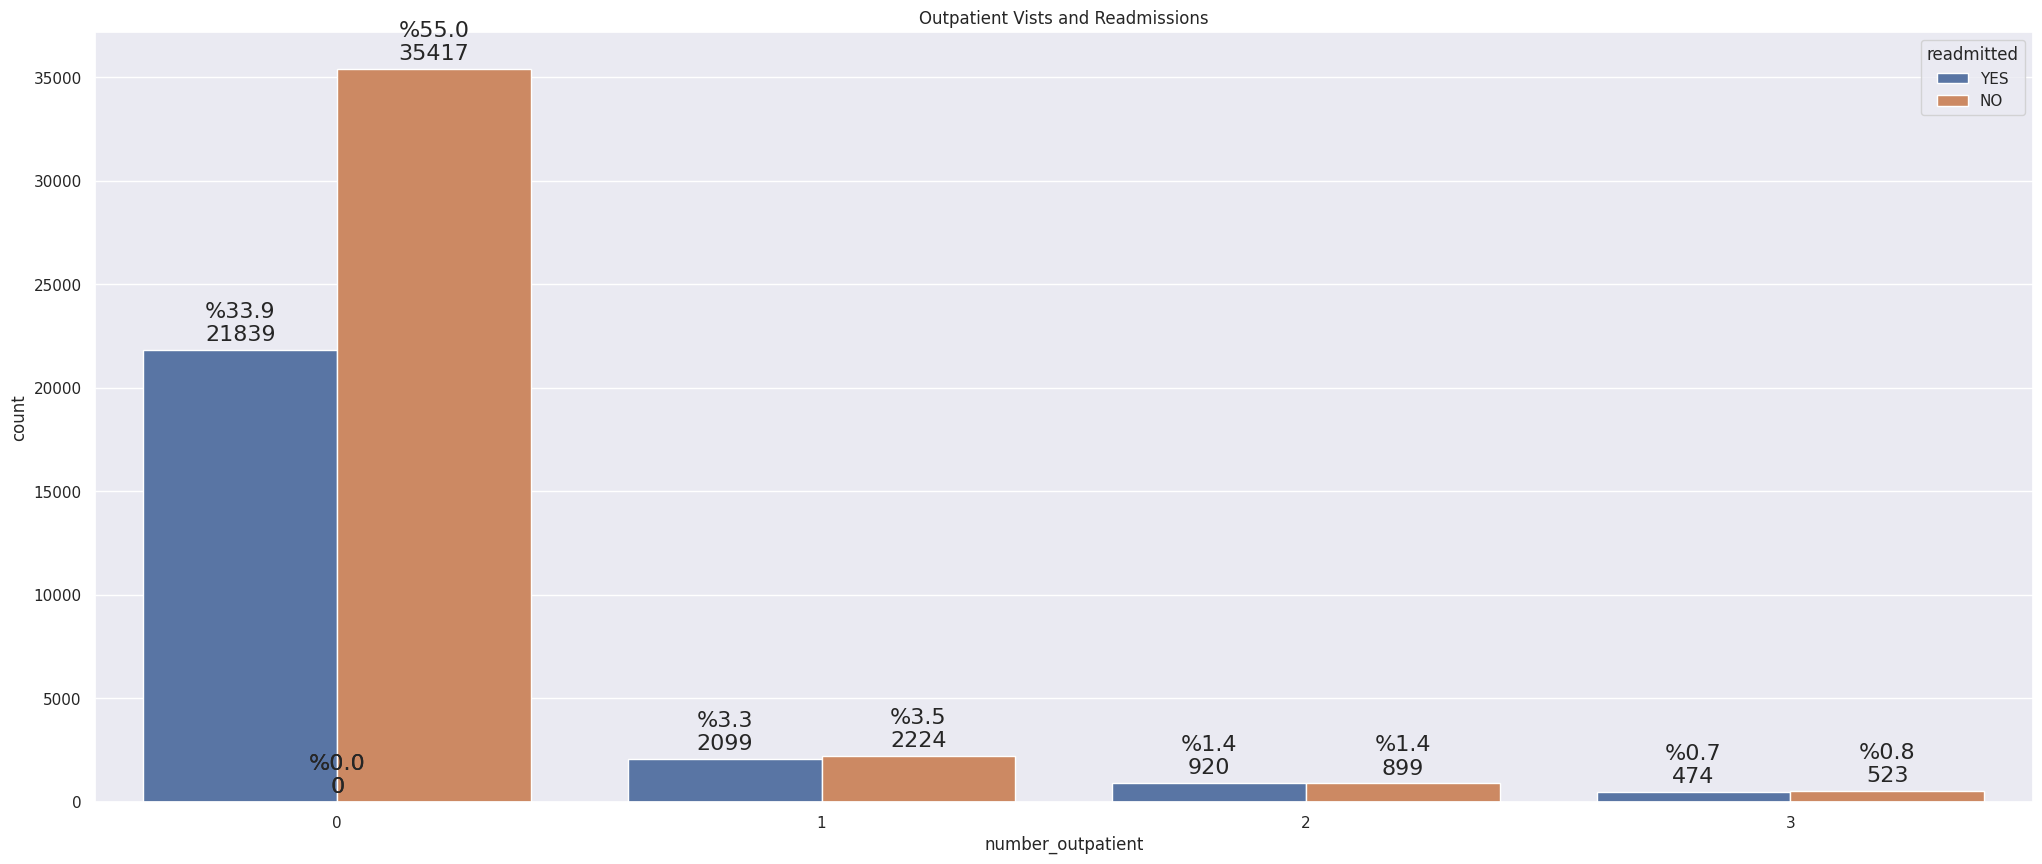

In [130]:
# outpatient vists and readmissions
ax = sns.countplot(x='number_outpatient',data=df, hue='readmitted')
labels(ax)
plt.title('Outpatient Vists and Readmissions')
plt.show()

In [131]:
pd.crosstab(df.readmitted, df.number_outpatient, margins=True, margins_name='Total')

number_outpatient,0,1,2,3,Total
readmitted,,,,,
NO,35417,2224,899,523,39063
YES,21839,2099,920,474,25332
Total,57256,4323,1819,997,64395


> Most patients did not have any outpatient visits prior to the recorded one.

### FOCUS ON "`number of emergency`" visits

In [132]:
info('number_emergency')

NUMBER_EMERGENCY : Available

0    0
1    0
2    0
3    0
4    0
Name: number_emergency, dtype: int64


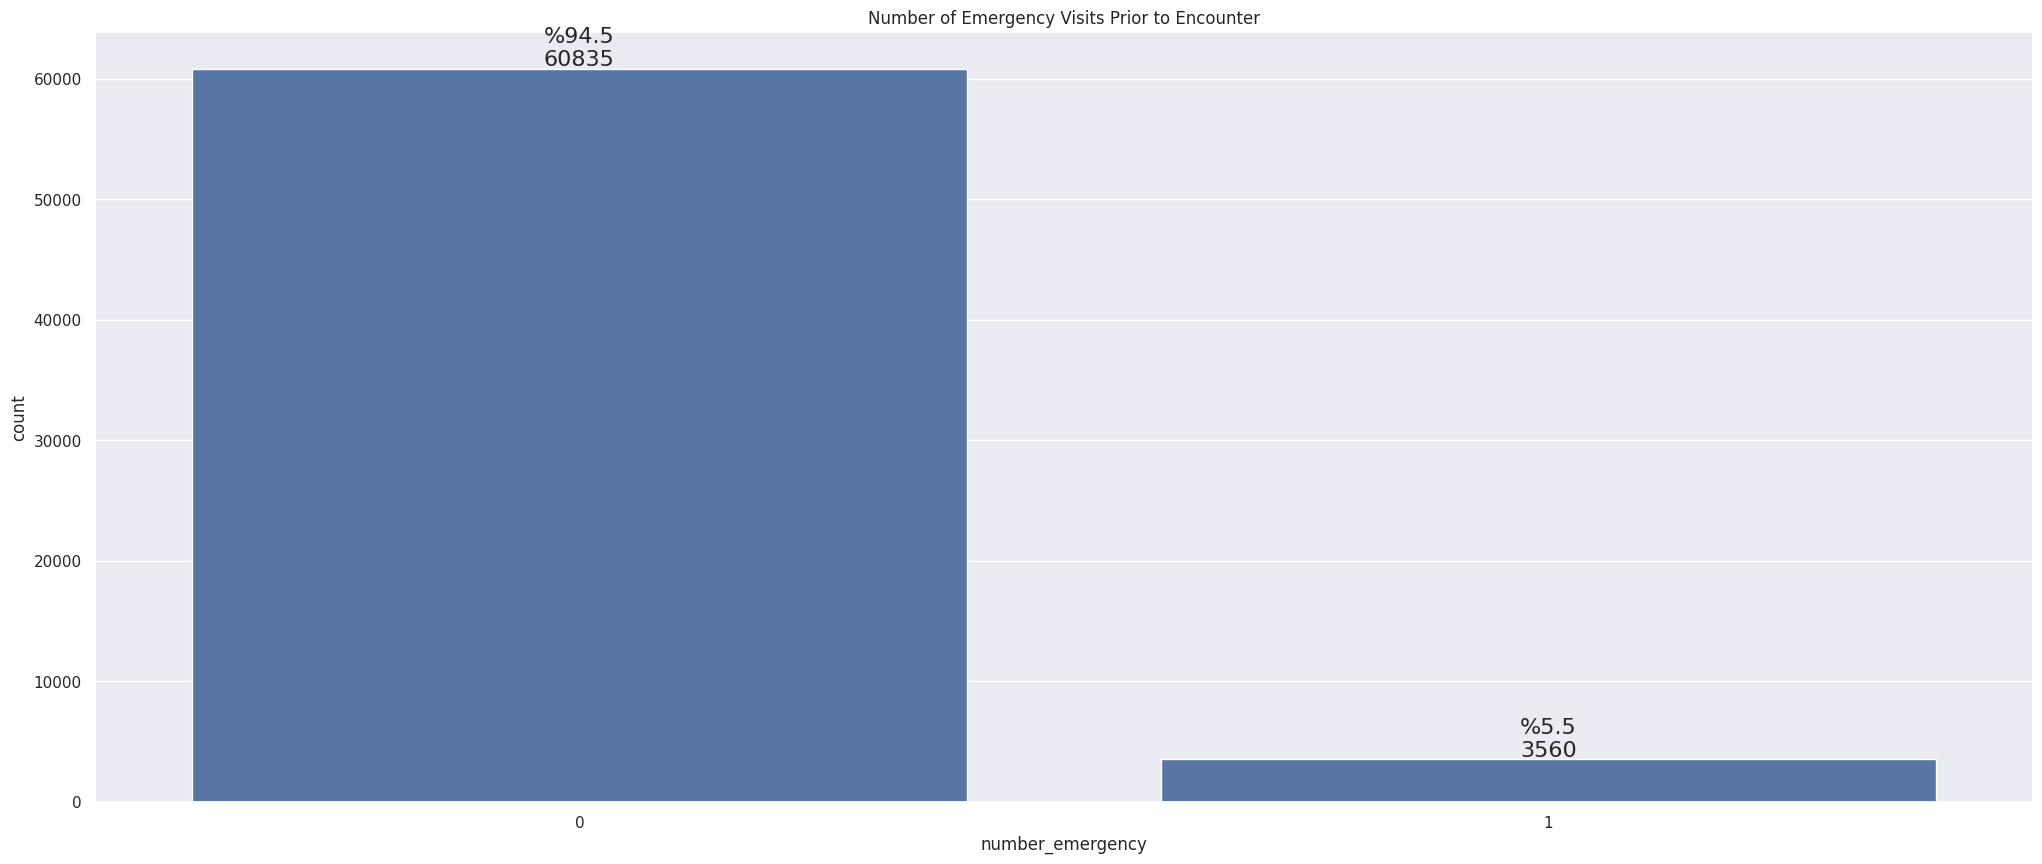

In [133]:
# plt.figure(figsize=(20,5))
ax = sns.countplot(x='number_emergency', data=df)
labels(ax)
plt.title('Number of Emergency Visits Prior to Encounter')
plt.show()

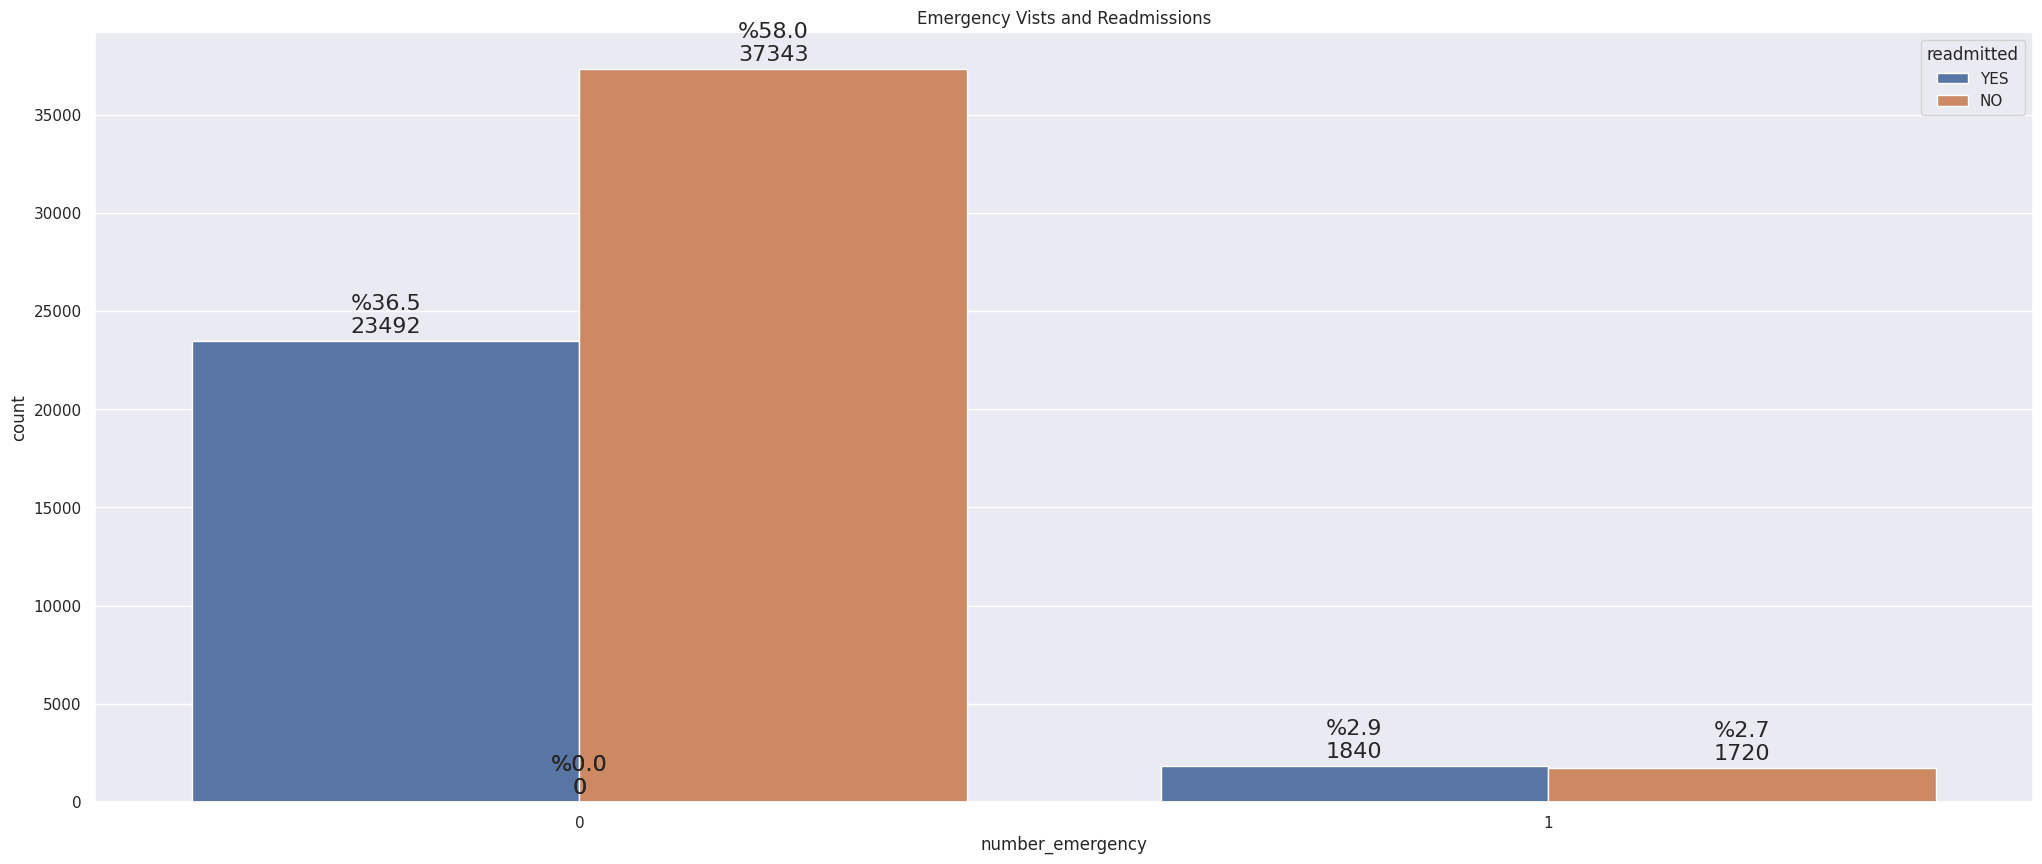

In [134]:
# emergency vists and readmissions
ax = sns.countplot(x='number_emergency', hue='readmitted', data=df)
labels(ax)
plt.title('Emergency Vists and Readmissions')
plt.show()

> Most patients did not visit the emergency room prior to their recorded visit.

In [135]:
pd.crosstab(df.readmitted, df.number_emergency, margins=True, margins_name='Total')

number_emergency,0,1,Total
readmitted,,,
NO,37343,1720,39063
YES,23492,1840,25332
Total,60835,3560,64395


> **How many emergency visits did patients have prior to this visit?**

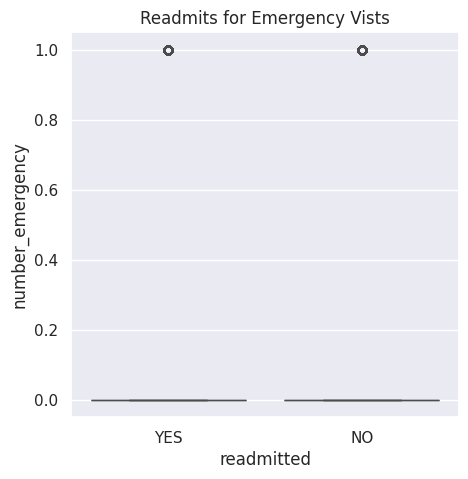

In [136]:
plt.figure(figsize=(5, 5))
sns.boxplot(x='readmitted', y='number_emergency', data=df)
plt.title('Readmits for Emergency Vists')
plt.show()

### FOCUS ON "`number of inpatient`" visits

In [137]:
info('number_inpatient') # onceki yildaki yatarak tedavi sayisi

NUMBER_INPATIENT : Available

0    0
1    1
2    0
3    0
4    0
Name: number_inpatient, dtype: int64


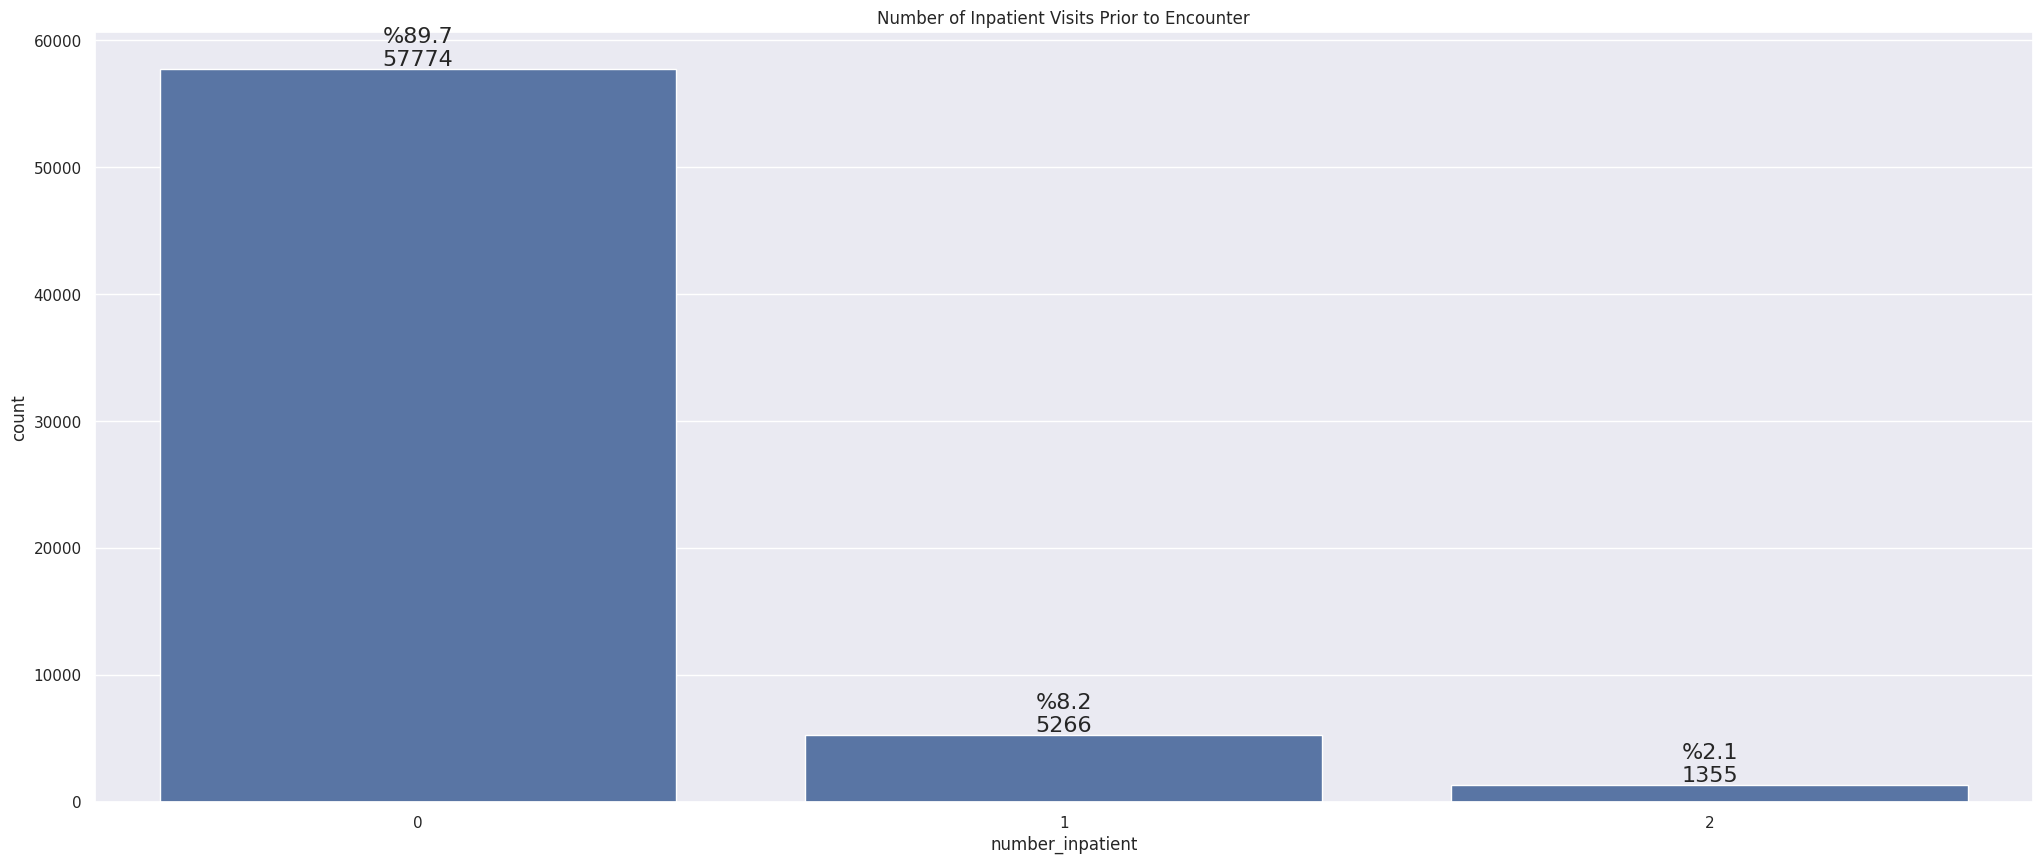

In [138]:
ax = sns.countplot(x='number_inpatient',data=df)
labels(ax)
plt.title('Number of Inpatient Visits Prior to Encounter')
plt.show()

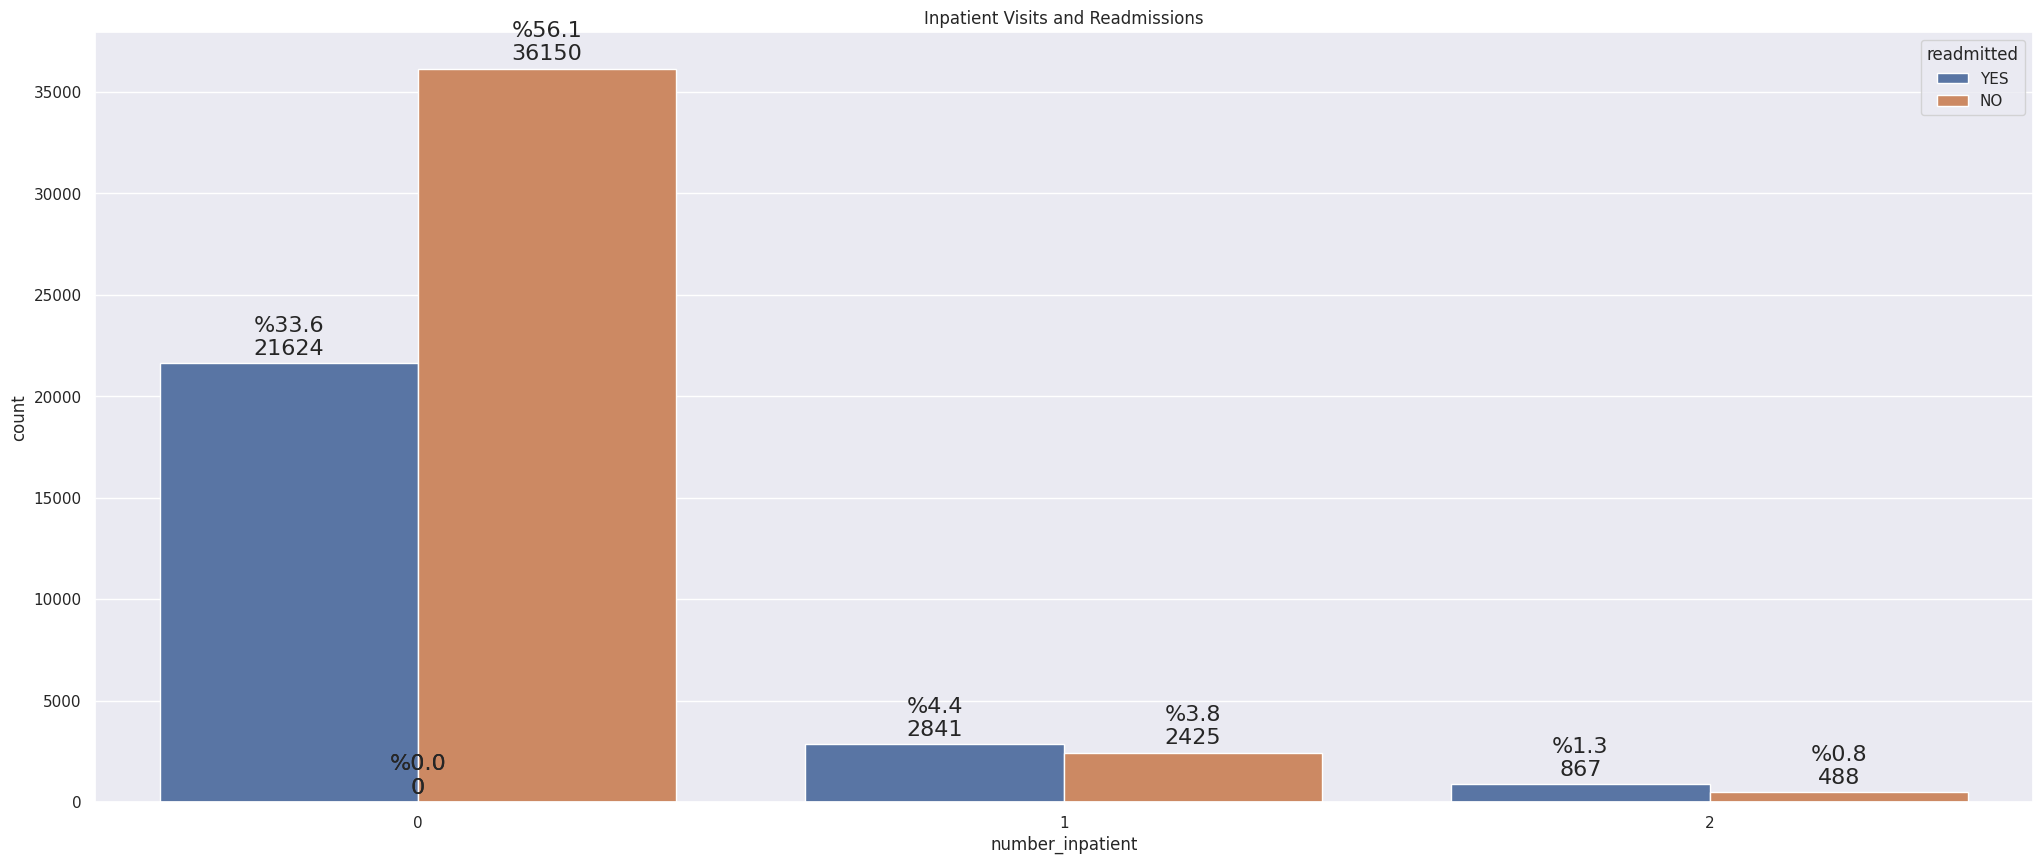

In [139]:
# inpatient visits and readmissions
ax = sns.countplot(x='number_inpatient', hue='readmitted',data=df)
labels(ax)
plt.title('Inpatient Visits and Readmissions')
plt.show()

> Inpatient visits are not common for most patients prior to this visit.

In [140]:
pd.crosstab(df.readmitted, df.number_inpatient, margins=True, margins_name='Total')

number_inpatient,0,1,2,Total
readmitted,,,,
NO,36150,2425,488,39063
YES,21624,2841,867,25332
Total,57774,5266,1355,64395


### FOCUS ON "`number of diagnoses`"

In [141]:
info('number_diagnoses')

NUMBER_DIAGNOSES : Available

0    9
1    6
2    7
3    5
4    9
Name: number_diagnoses, dtype: int64


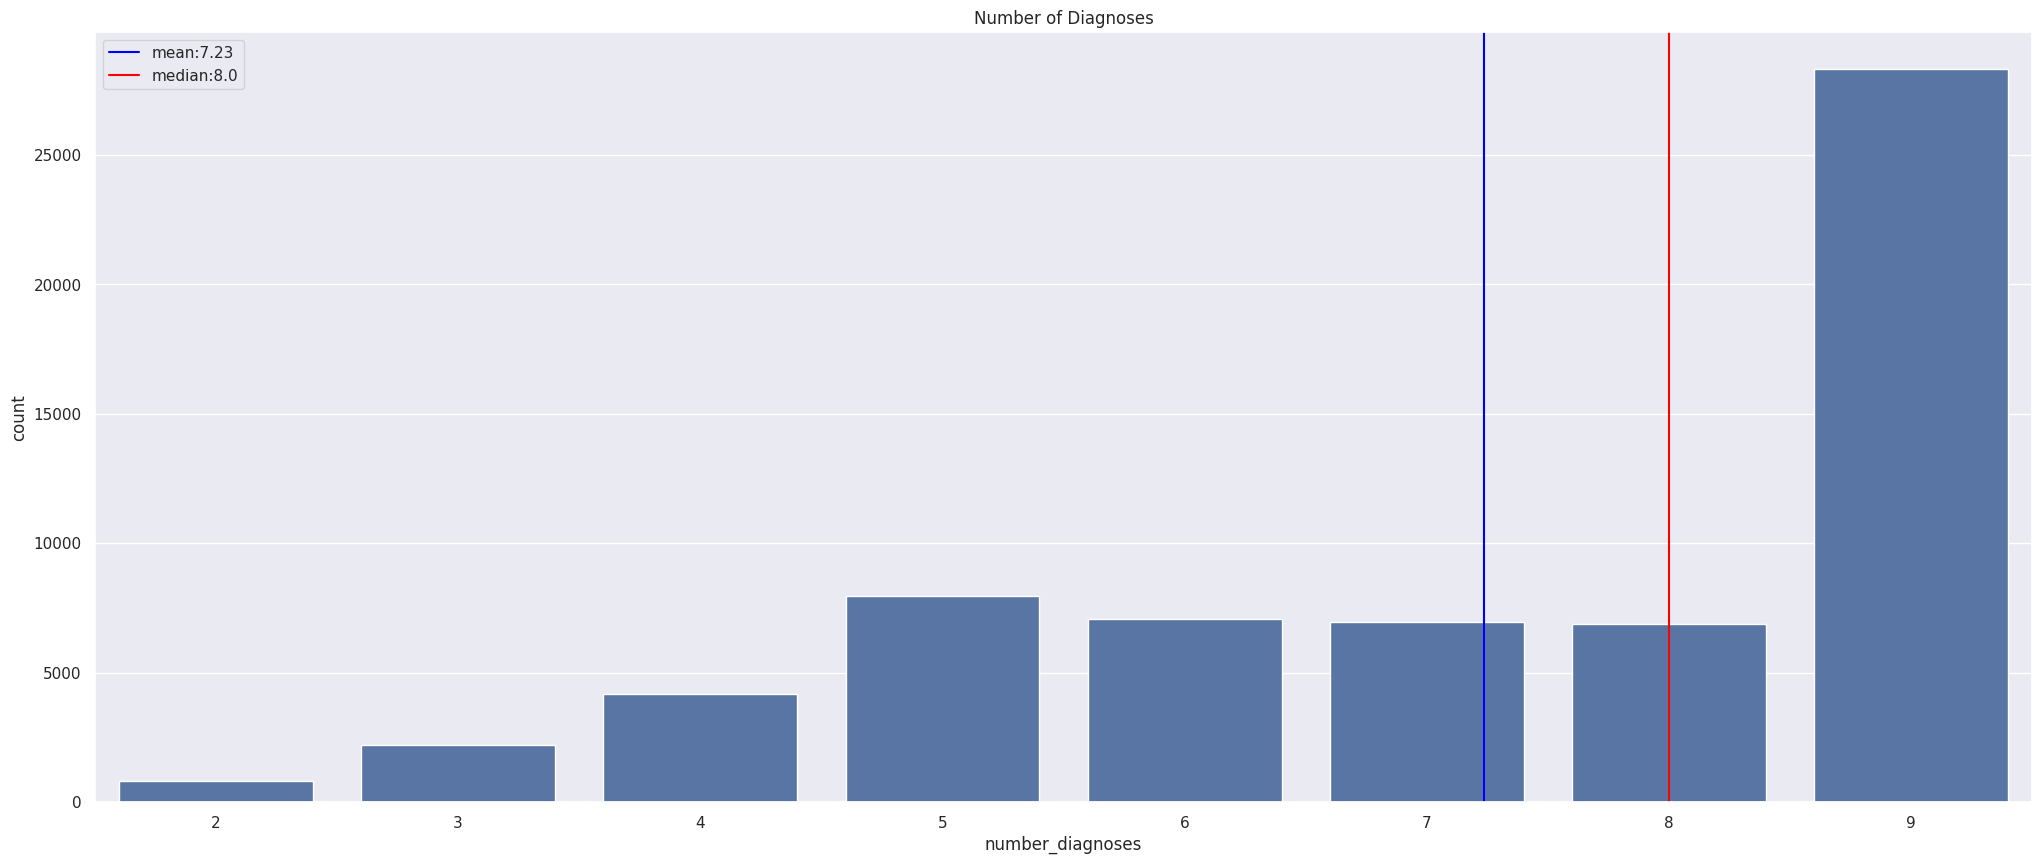

In [142]:
ax = sns.countplot(x='number_diagnoses',data=df)
mean, median = np.mean(df.number_diagnoses), np.median(df.number_diagnoses)
plt.axvline(mean-df.number_diagnoses.min(), color='blue', label=f'mean:{round(mean,2)}')
plt.axvline(median-df.number_diagnoses.min(), color='red', label=f'median:{round(median,2)}')
plt.title('Number of Diagnoses')
plt.legend()
plt.show()

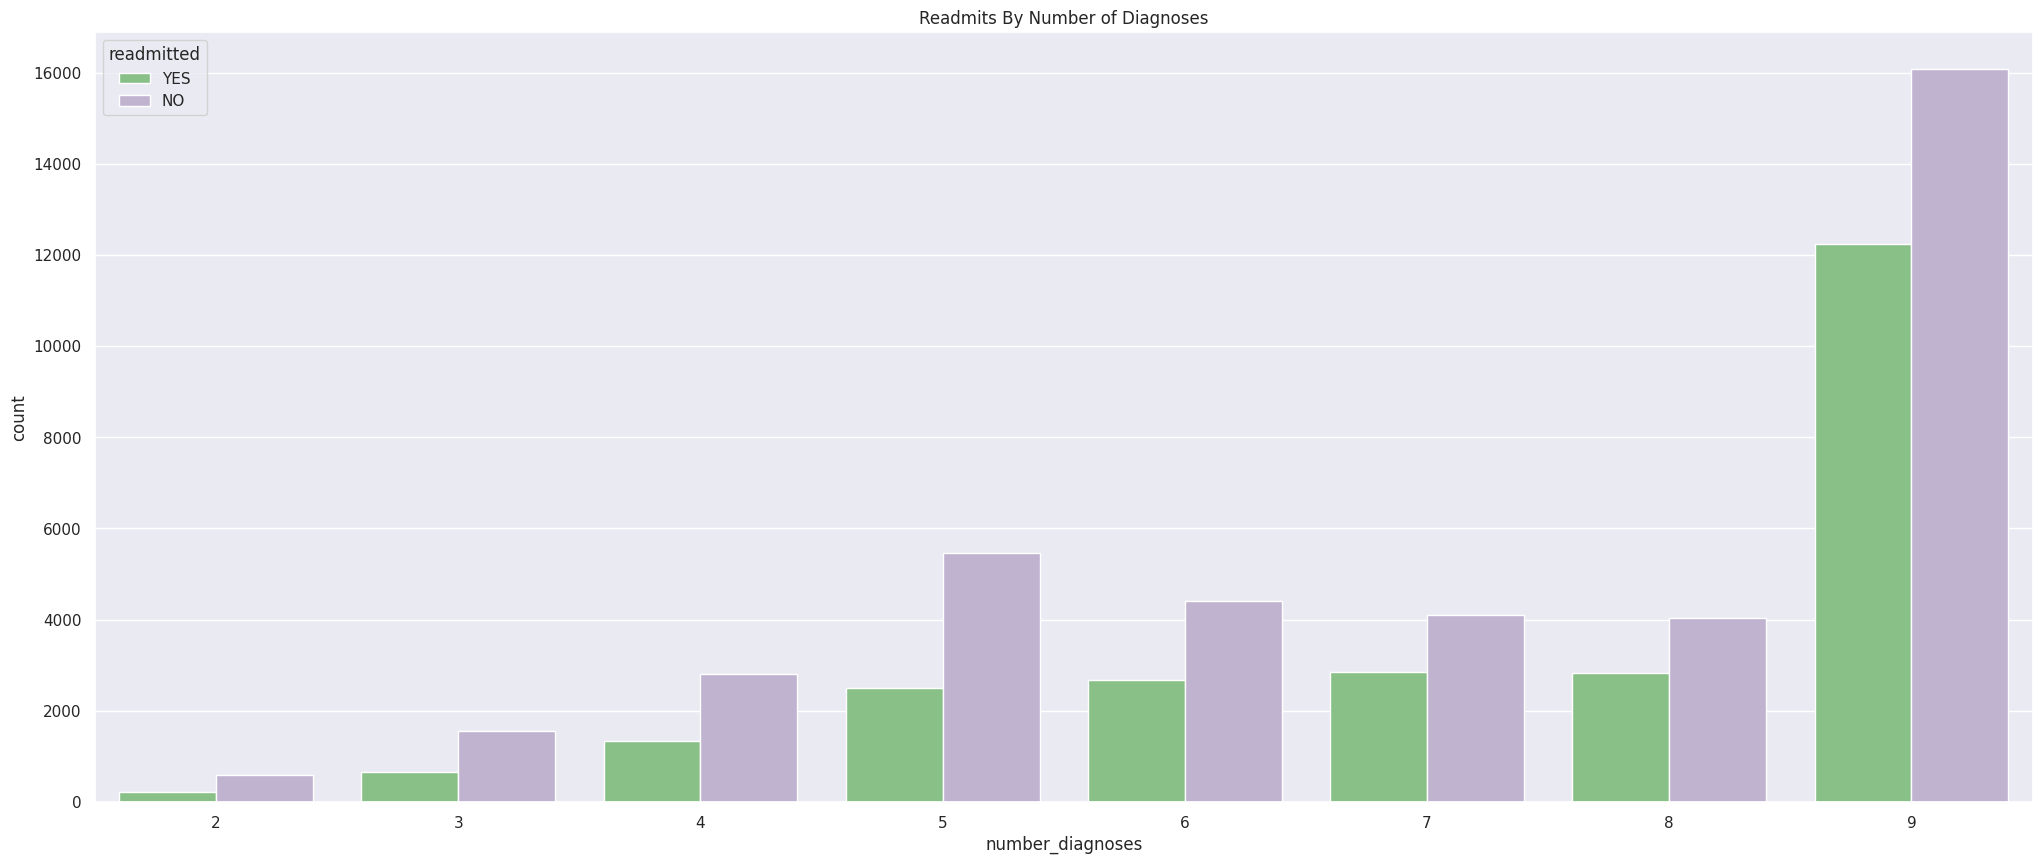

In [143]:
# number of diagnoses and readmit rate
ax = sns.countplot(x='number_diagnoses', hue='readmitted', palette='Accent', data=df)
# labels(ax)
plt.title('Readmits By Number of Diagnoses')
plt.show()

In [144]:
pd.DataFrame(df.number_diagnoses.describe()).T.round(2)

,count,mean,std,min,25%,50%,75%,max
number_diagnoses,64395.0,7.23,1.97,2.0,6.0,8.0,9.0,9.0


In [145]:
df.groupby('readmitted')['number_diagnoses'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
NO,39063.0,7.08,2.02,2.0,5.0,8.0,9.0,9.0
YES,25332.0,7.47,1.86,2.0,6.0,8.0,9.0,9.0


In [146]:
# number of diagnoses
pd.crosstab(df.readmitted, df.number_diagnoses, margins=True, margins_name='Total')

number_diagnoses,2,3,4,5,6,7,8,9,Total
readmitted,,,,,,,,,
NO,588,1567,2816,5466,4399,4106,4035,16086,39063
YES,228,650,1347,2505,2686,2848,2828,12240,25332
Total,816,2217,4163,7971,7085,6954,6863,28326,64395


* Most patients have up to nine diagnosed conditions during their visit, after that, only a handful have more than nine in one visit.
* Readmitted patients tend to have more diagnosed conditions but their average is only slightly higher than those not readmitted.

> **How many diagnoses do readmitted patients have?**

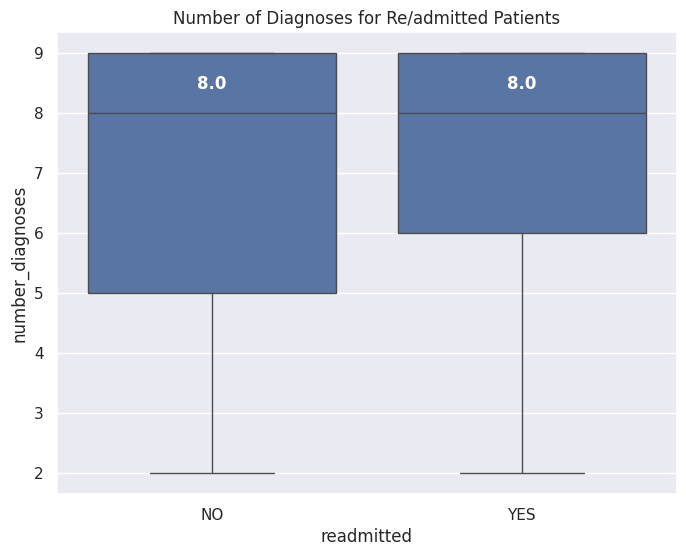

In [147]:
plt.figure(figsize=(8, 6))
ax = sns.boxplot(x='readmitted', y='number_diagnoses', data=df.sort_values('readmitted'))
box_labels(ax, df.sort_values('readmitted'),'readmitted','number_diagnoses')
plt.title('Number of Diagnoses for Re/admitted Patients')
plt.show()

# FOCUS ON "`glucose serum test results`"

In [148]:
info('max_glu_serum')

MAX_GLU_SERUM : Available

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: max_glu_serum, dtype: object


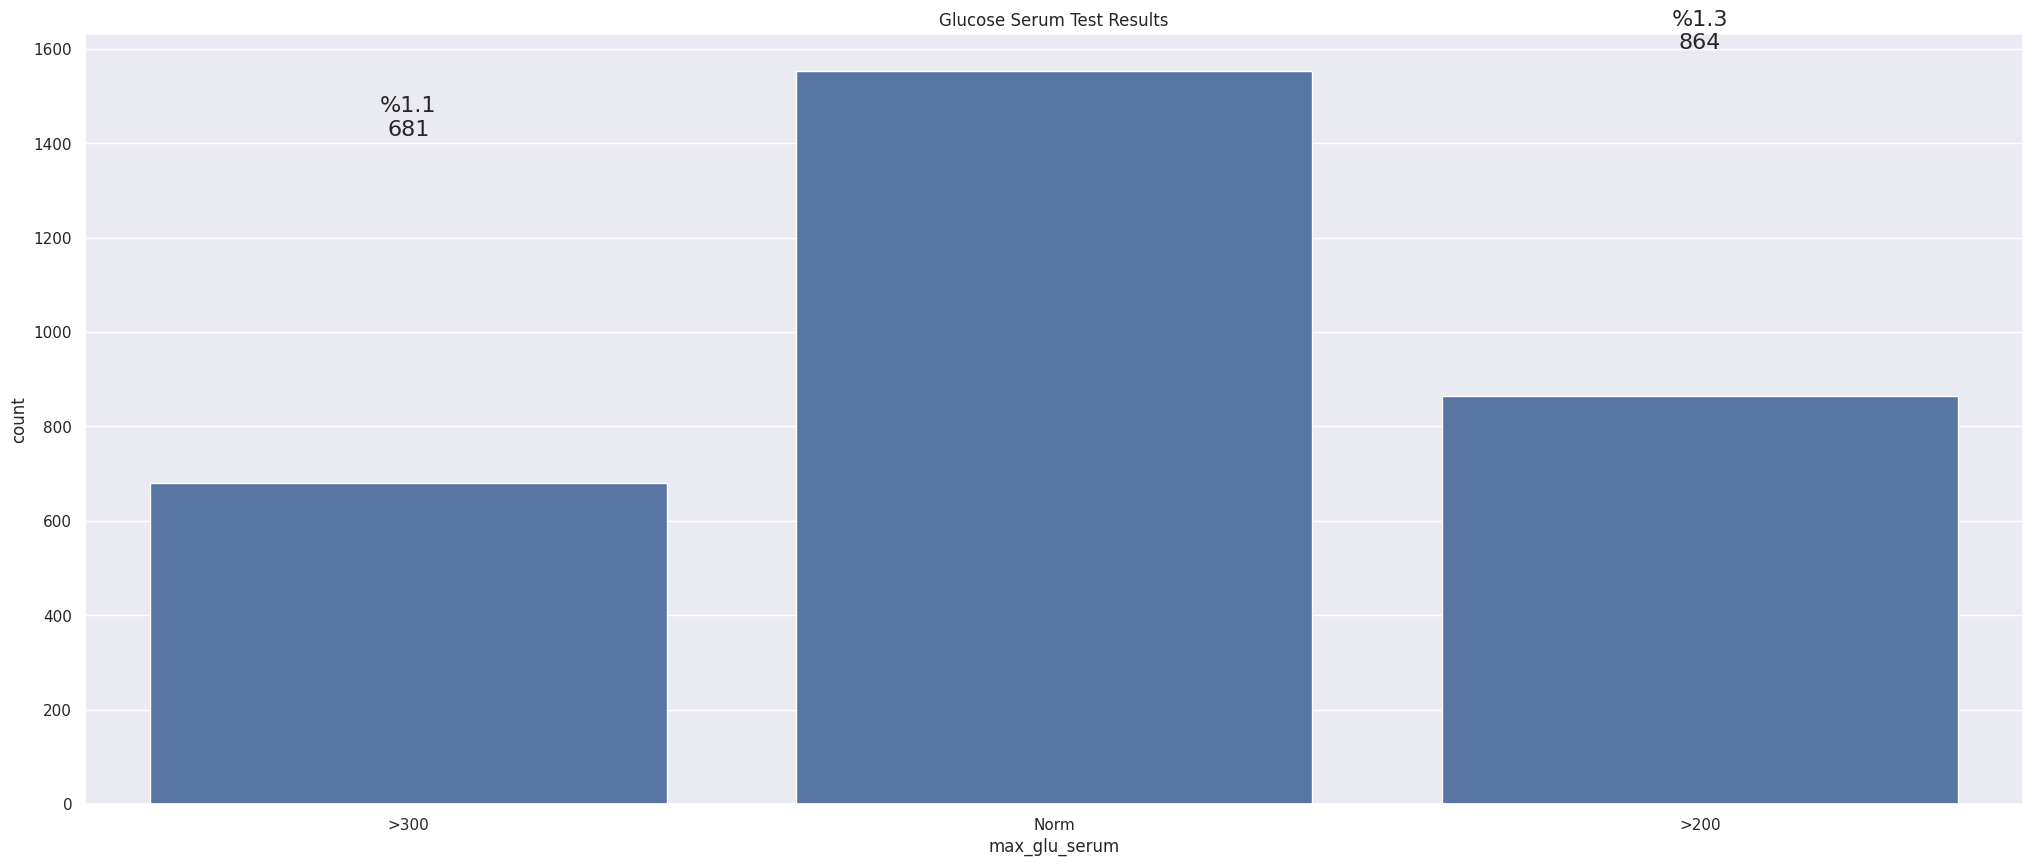

In [149]:
ax = sns.countplot(x='max_glu_serum', data=df)
labels(ax)
plt.title('Glucose Serum Test Results')
plt.show()

> Since the majority of patients do not have a glucose reading, they will be excluded for the next graph in order to show the readmit rates for patients who do have a reading.

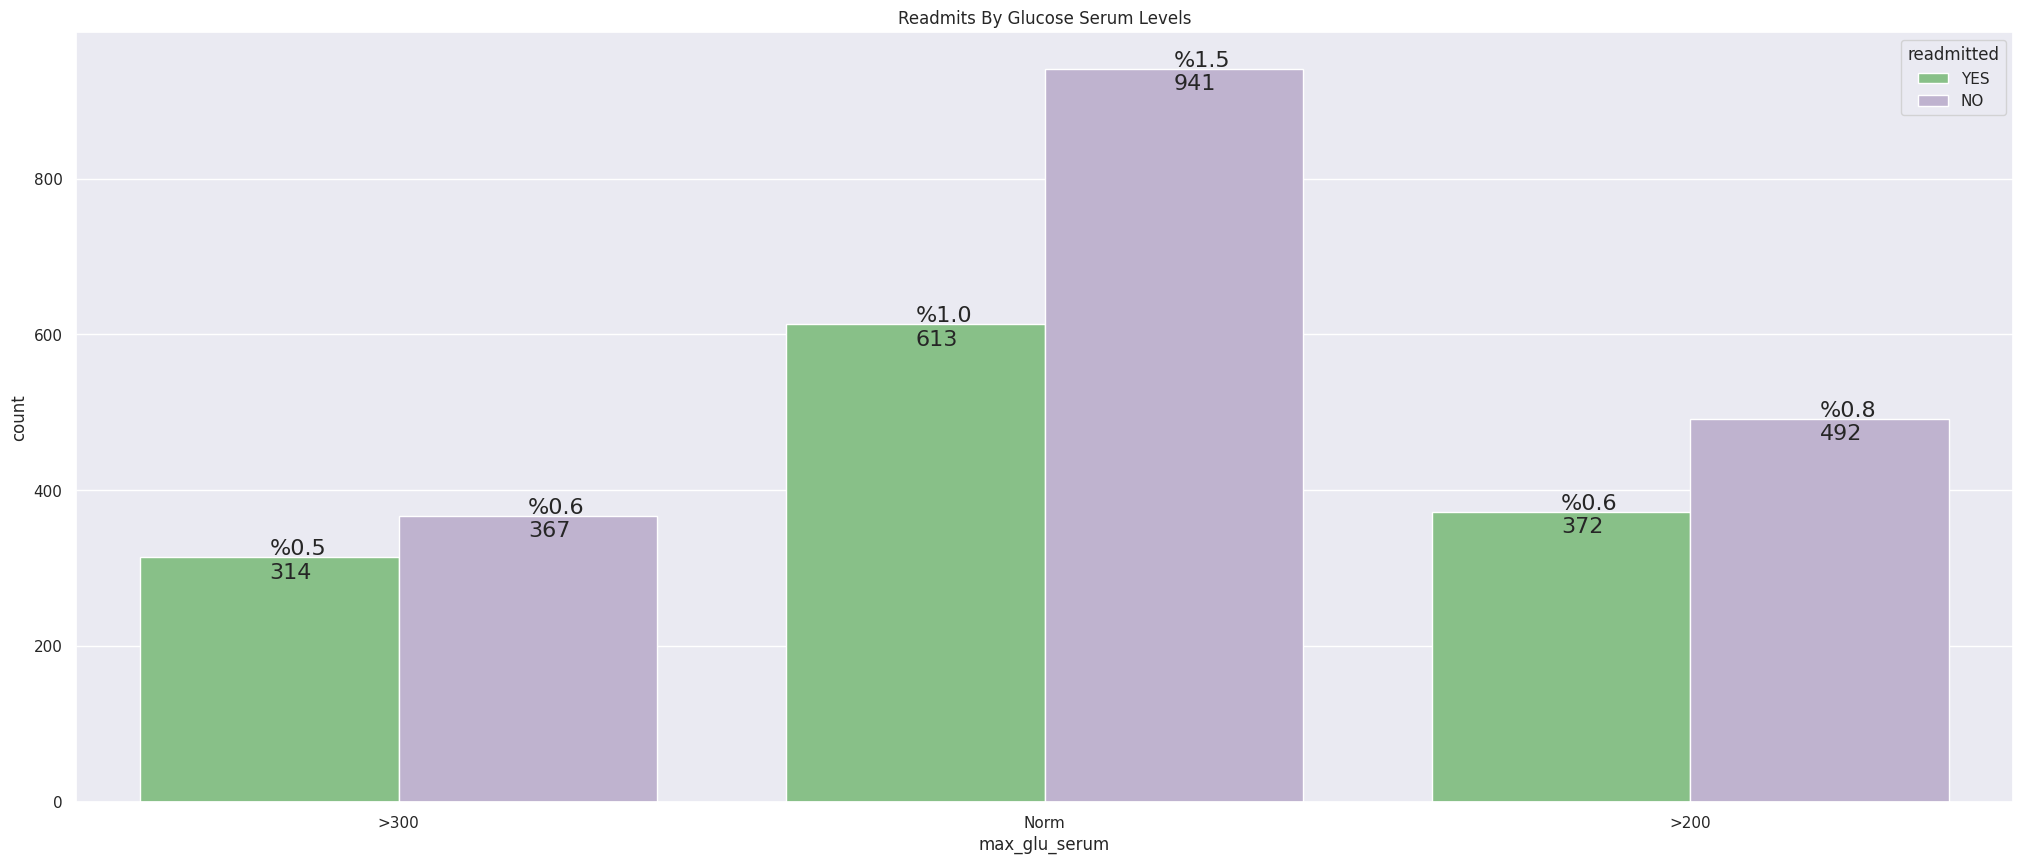

In [150]:
def labels(ax, df=df):
    for p in ax.patches:
            ax.annotate('%{:.1f}\n{:.0f}'.format(100*p.get_height()/len(df),p.get_height()),
                        (p.get_x()+0.2, p.get_height()-27),size=16)

# exclude patients without a glucose reading
glucose_none = df[df.max_glu_serum != 'None']

# glucose serum results and readmit impact
ax = sns.countplot(x='max_glu_serum', hue='readmitted', palette='Accent', data=glucose_none)
labels(ax,glucose_none)
plt.title('Readmits By Glucose Serum Levels')
plt.show()

Patients with a glucose serum reading of over 300 have a 50-50 chance of being readmitted. High blood sugar levels are often dangerous for older patients due to the medical complications involved, so it's understandable that more patients return to the hospital for additional care.

In [151]:

pd.crosstab(df.readmitted, df.max_glu_serum, margins=True, margins_name='Total')

max_glu_serum,>200,>300,Norm,Total
readmitted,,,,
NO,492,367,941,1800
YES,372,314,613,1299
Total,864,681,1554,3099


### FOCUS ON "`A1C results`"

In [152]:
info('A1Cresult')

A1CRESULT : Available

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: A1Cresult, dtype: object


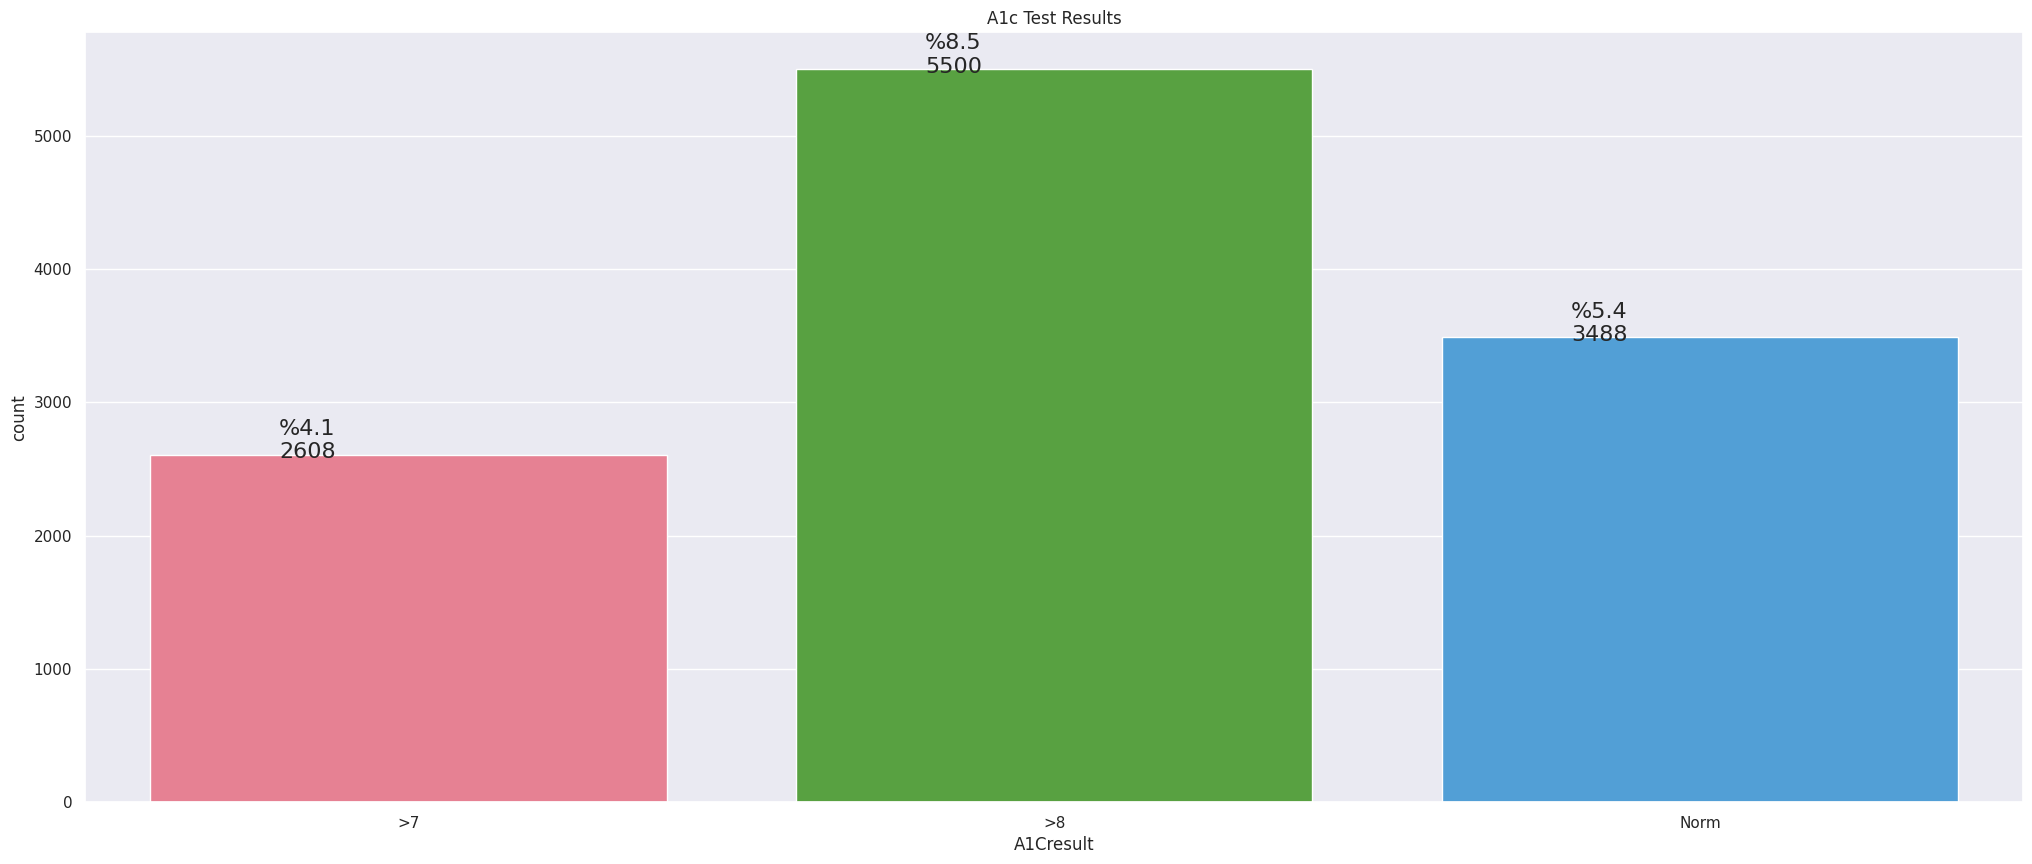

In [153]:
ax = sns.countplot(x='A1Cresult', palette='husl', data=df)
labels(ax)
plt.title('A1c Test Results')
plt.show()

* Similar to the glucose reading, the majority of patients also do not have a HbA1c test reading.
* In order to understand the impact of A1c tests on readmit rates, patients without a reading will be excluded in the graph below.

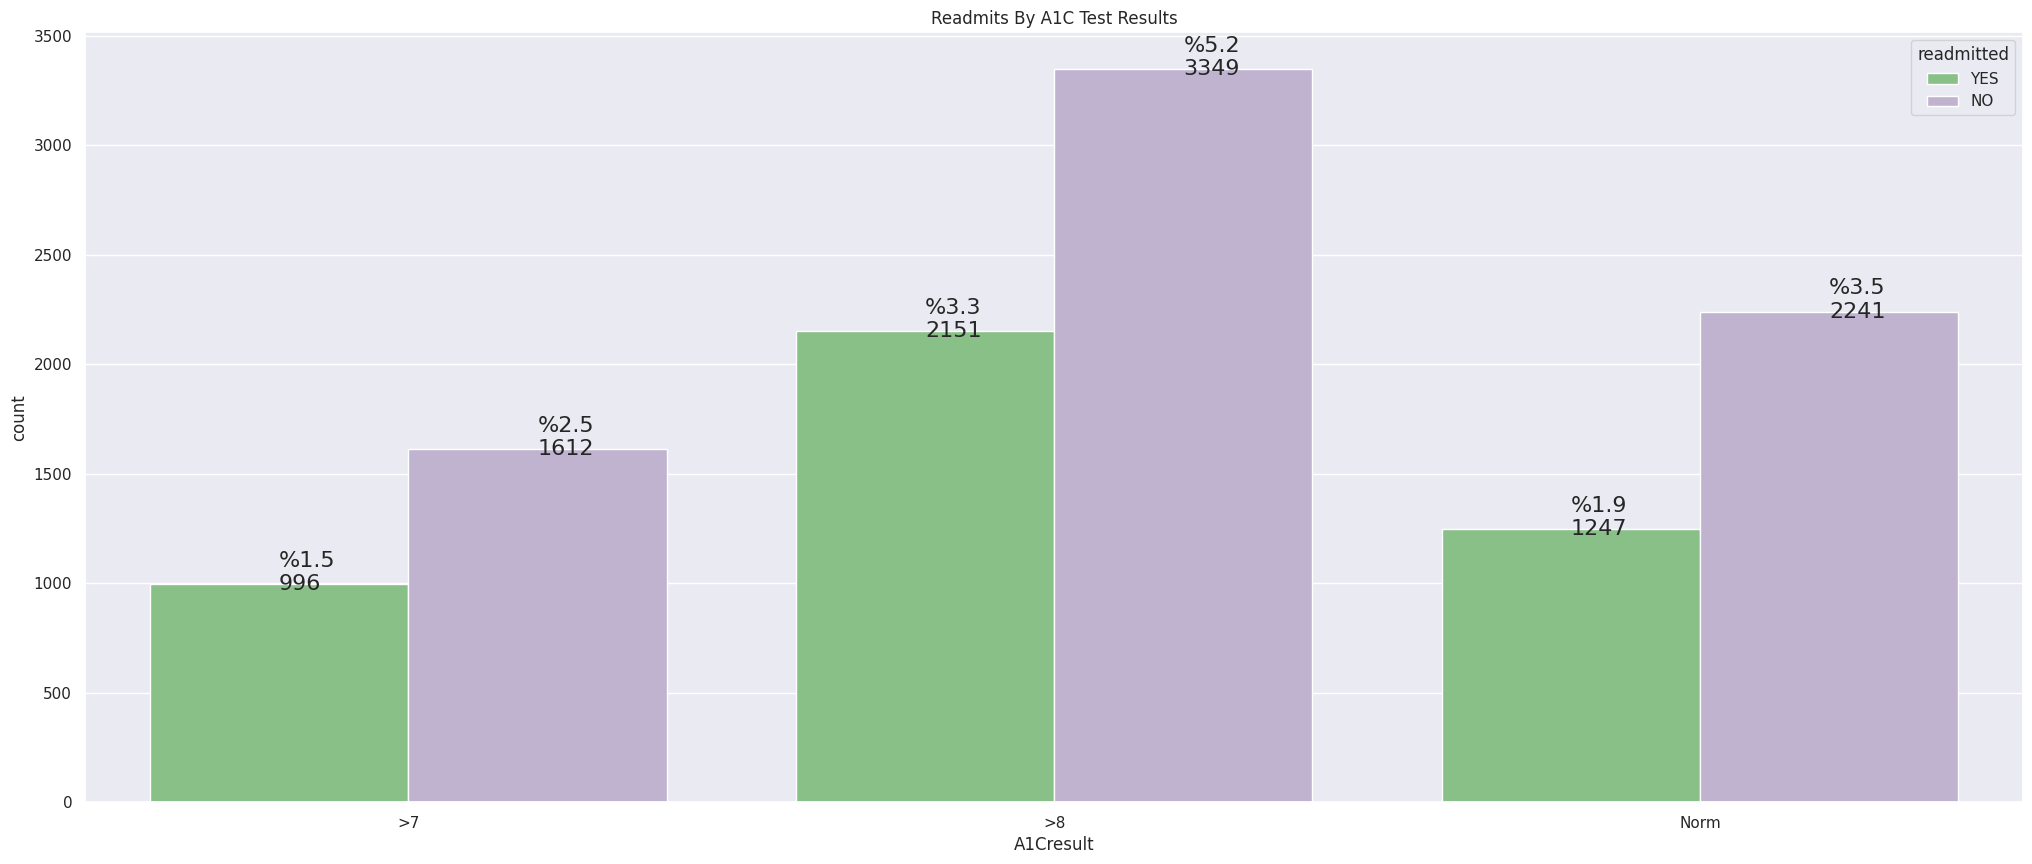

In [154]:
# exclude patients without an A1C reading
alc_none = df[df.A1Cresult != 'None']

# A1C results and readmit impact
ax = sns.countplot(x='A1Cresult', hue='readmitted', palette='Accent', data=alc_none)
labels(ax, alc_none)
plt.title('Readmits By A1C Test Results')
plt.show()

In [155]:
pd.crosstab(df.readmitted, df.A1Cresult, margins=True, margins_name='Total')

A1Cresult,>7,>8,Norm,Total
readmitted,,,,
NO,1612,3349,2241,7202
YES,996,2151,1247,4394
Total,2608,5500,3488,11596


### FOCUS ON "`change`" column

In [156]:
info('change')

CHANGE : Available

0    Ch
1    No
2    Ch
3    Ch
4    No
Name: change, dtype: object


## change in medications, dosage or brand

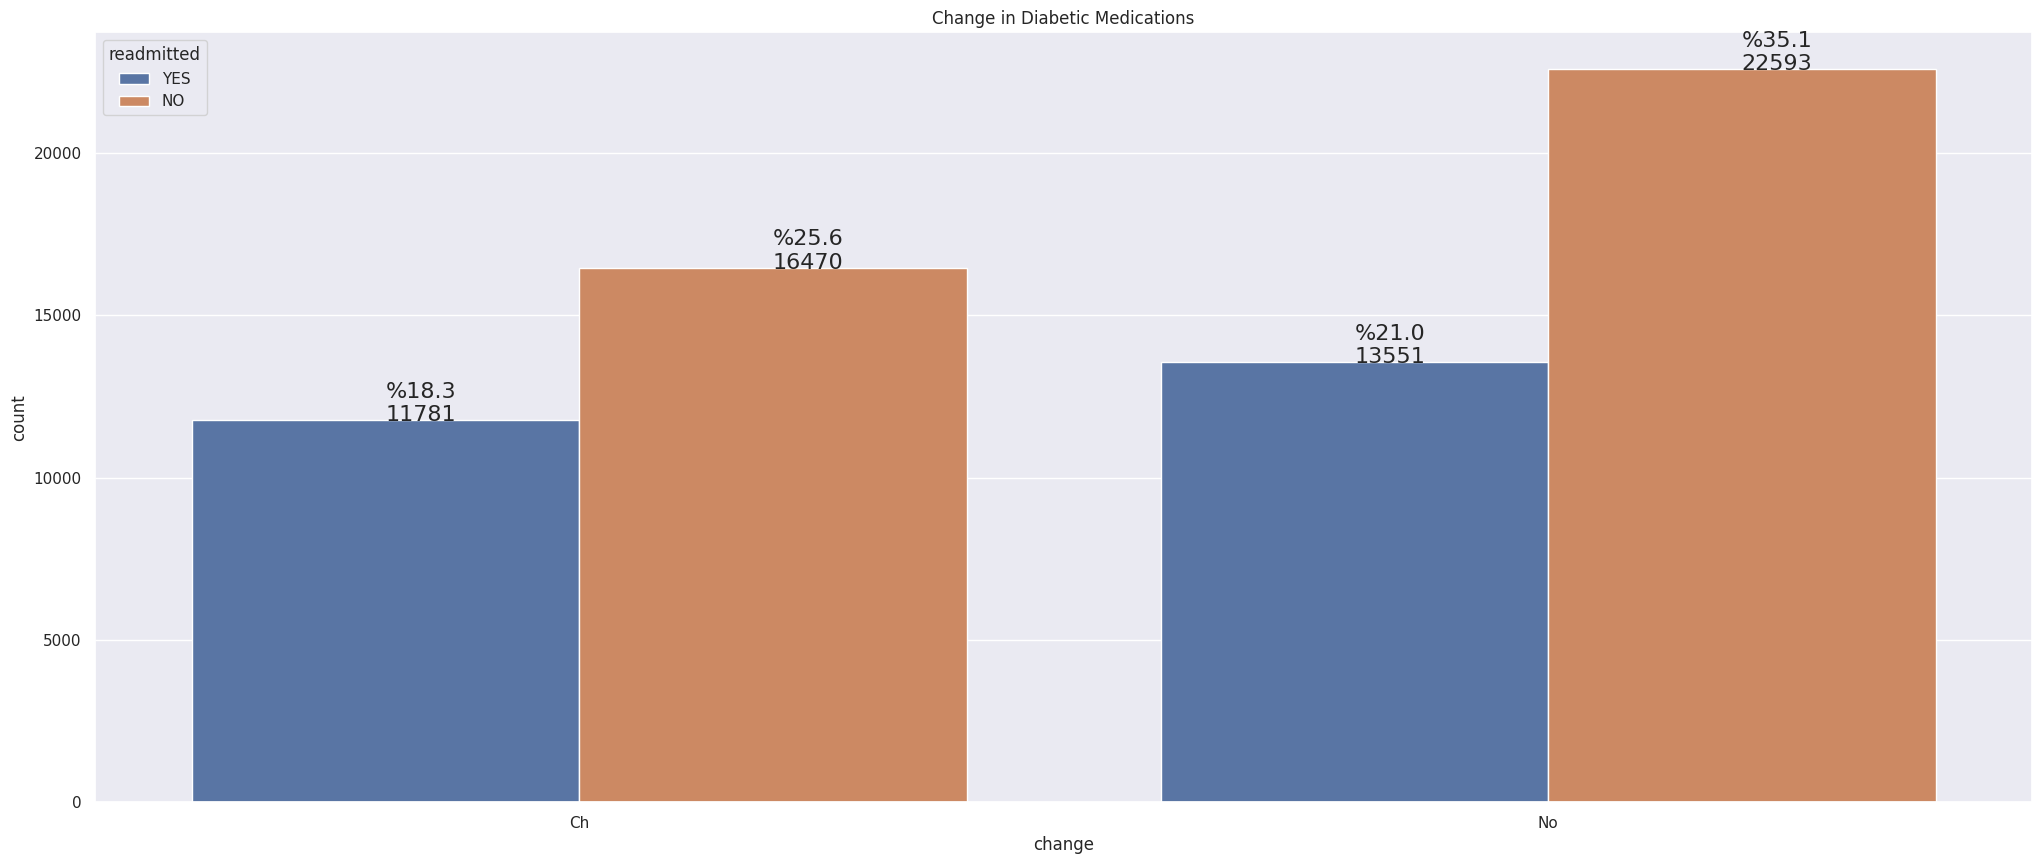

In [157]:
# change in medications
ax = sns.countplot(x='change', hue='readmitted', data=df)
labels(ax)
plt.title('Change in Diabetic Medications')
plt.show()

In [158]:
pd.crosstab(df.change, df.readmitted, margins=True, margins_name='Total')

readmitted,NO,YES,Total
change,,,
Ch,16470,11781,28251
No,22593,13551,36144
Total,39063,25332,64395


> **who is likely to have a change in medication?**

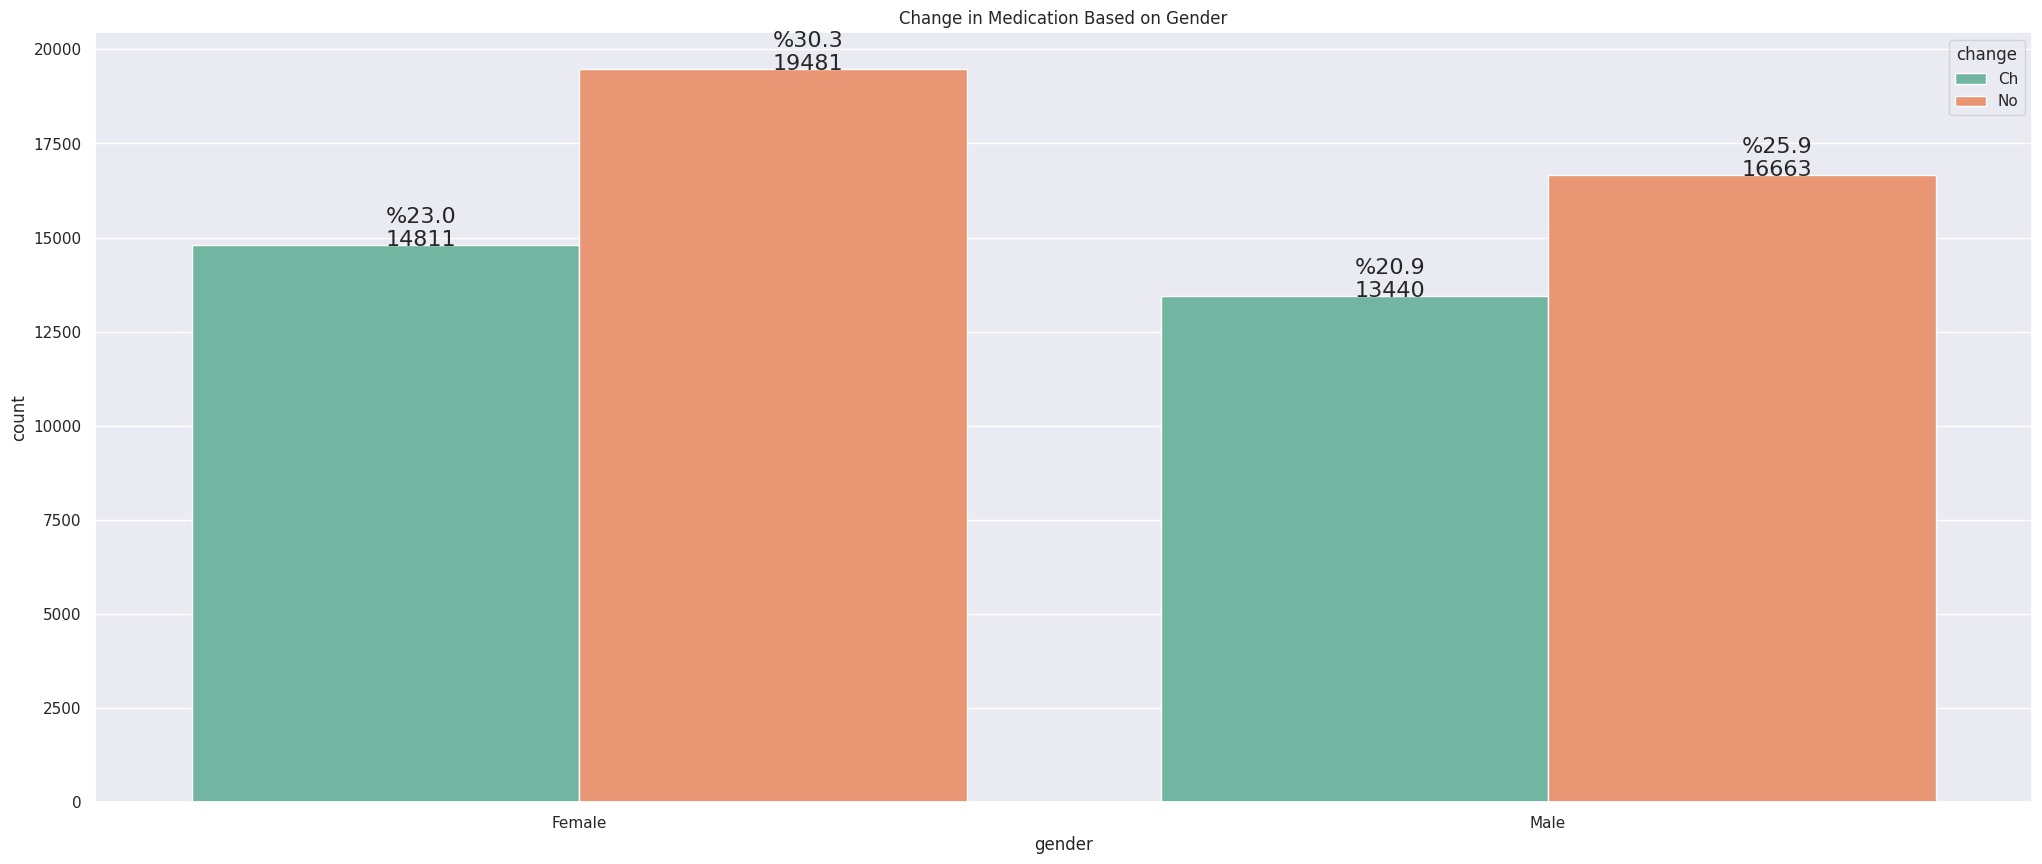

In [159]:
ax = sns.countplot(x='gender', hue='change', palette='Set2', data=df)
labels(ax)
plt.title('Change in Medication Based on Gender')
plt.show()

In [160]:
pd.crosstab(df.gender, df.change, margins=True, margins_name='Total')

change,Ch,No,Total
gender,,,
Female,14811,19481,34292
Male,13440,16663,30103
Total,28251,36144,64395


### FOCUS ON "`diabetesMed`"

In [161]:
info('diabetesMed')

DIABETESMED : Available

0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: diabetesMed, dtype: object


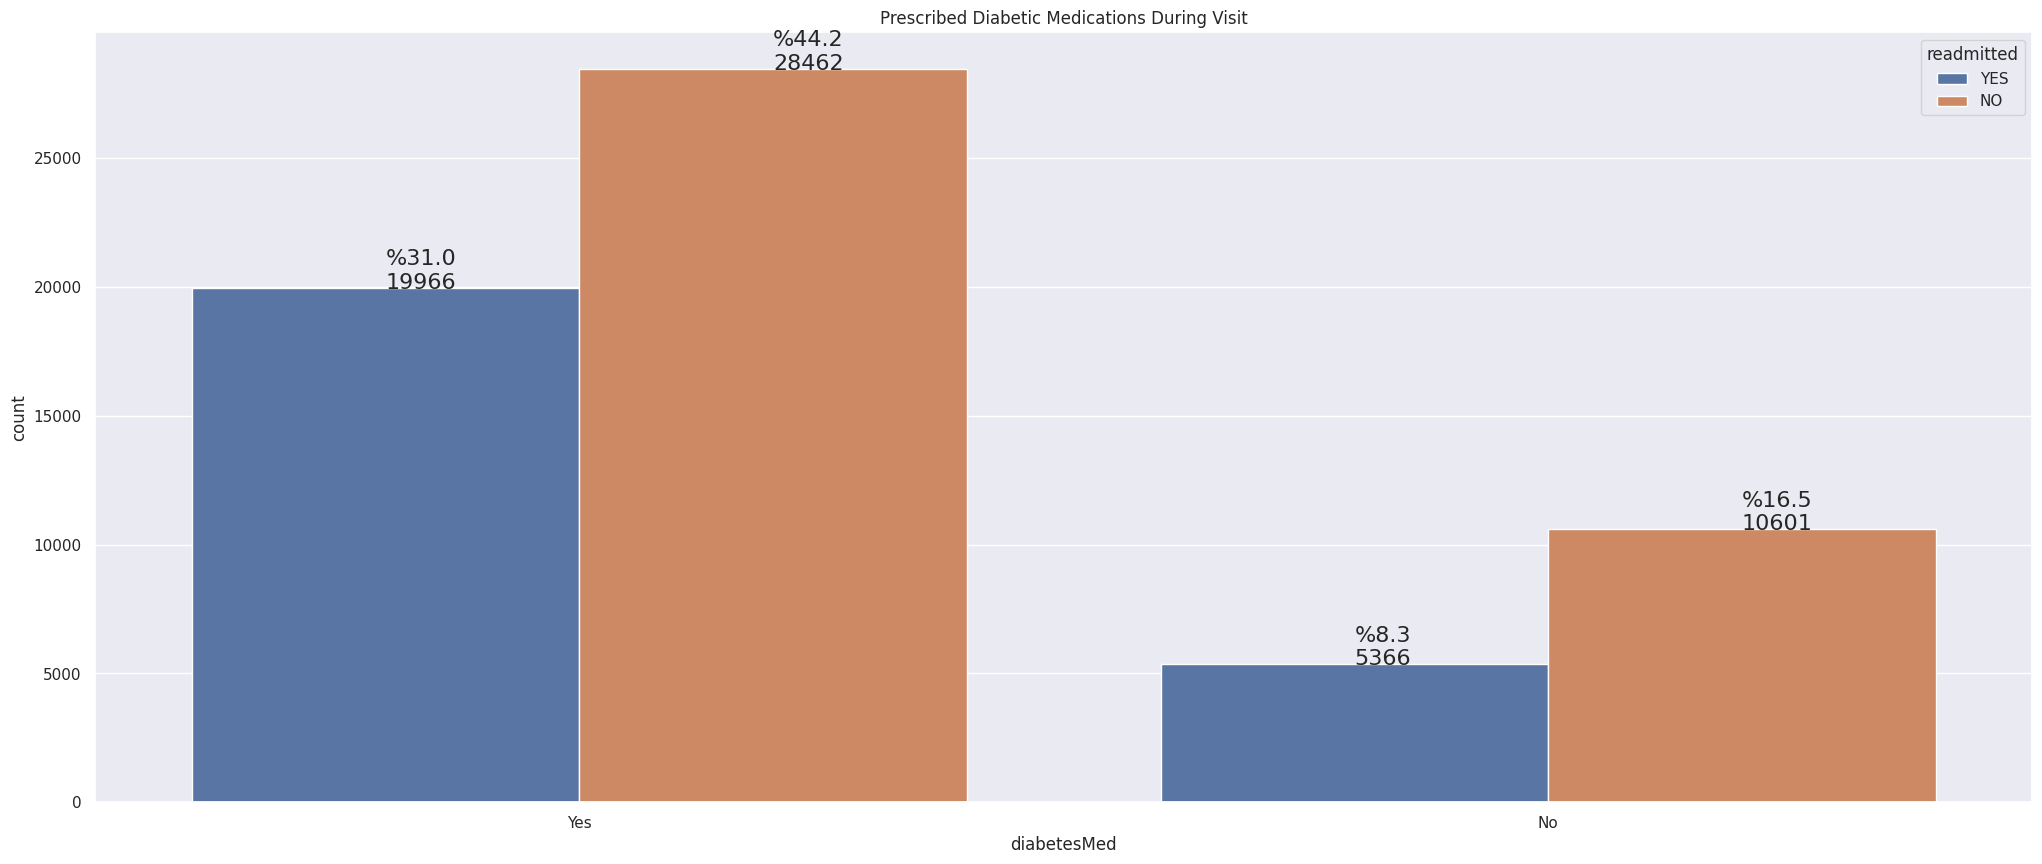

In [162]:
ax = sns.countplot(x='diabetesMed', hue='readmitted', data=df)
labels(ax)
plt.title('Prescribed Diabetic Medications During Visit')
plt.show()

In [163]:
pd.crosstab(df.diabetesMed, df.readmitted, margins=True, margins_name='Total')

readmitted,NO,YES,Total
diabetesMed,,,
No,10601,5366,15967
Yes,28462,19966,48428
Total,39063,25332,64395


> **Who is likely or not likely to have a change in medication?**

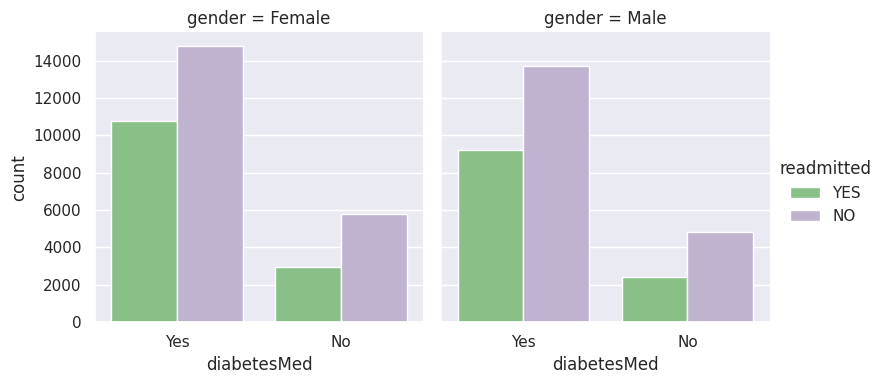

In [164]:
sns.catplot(x='diabetesMed', hue='readmitted', col='gender', palette='Accent', data=df, kind='count', height=4, aspect=1)
plt.show()

### medications used by patients

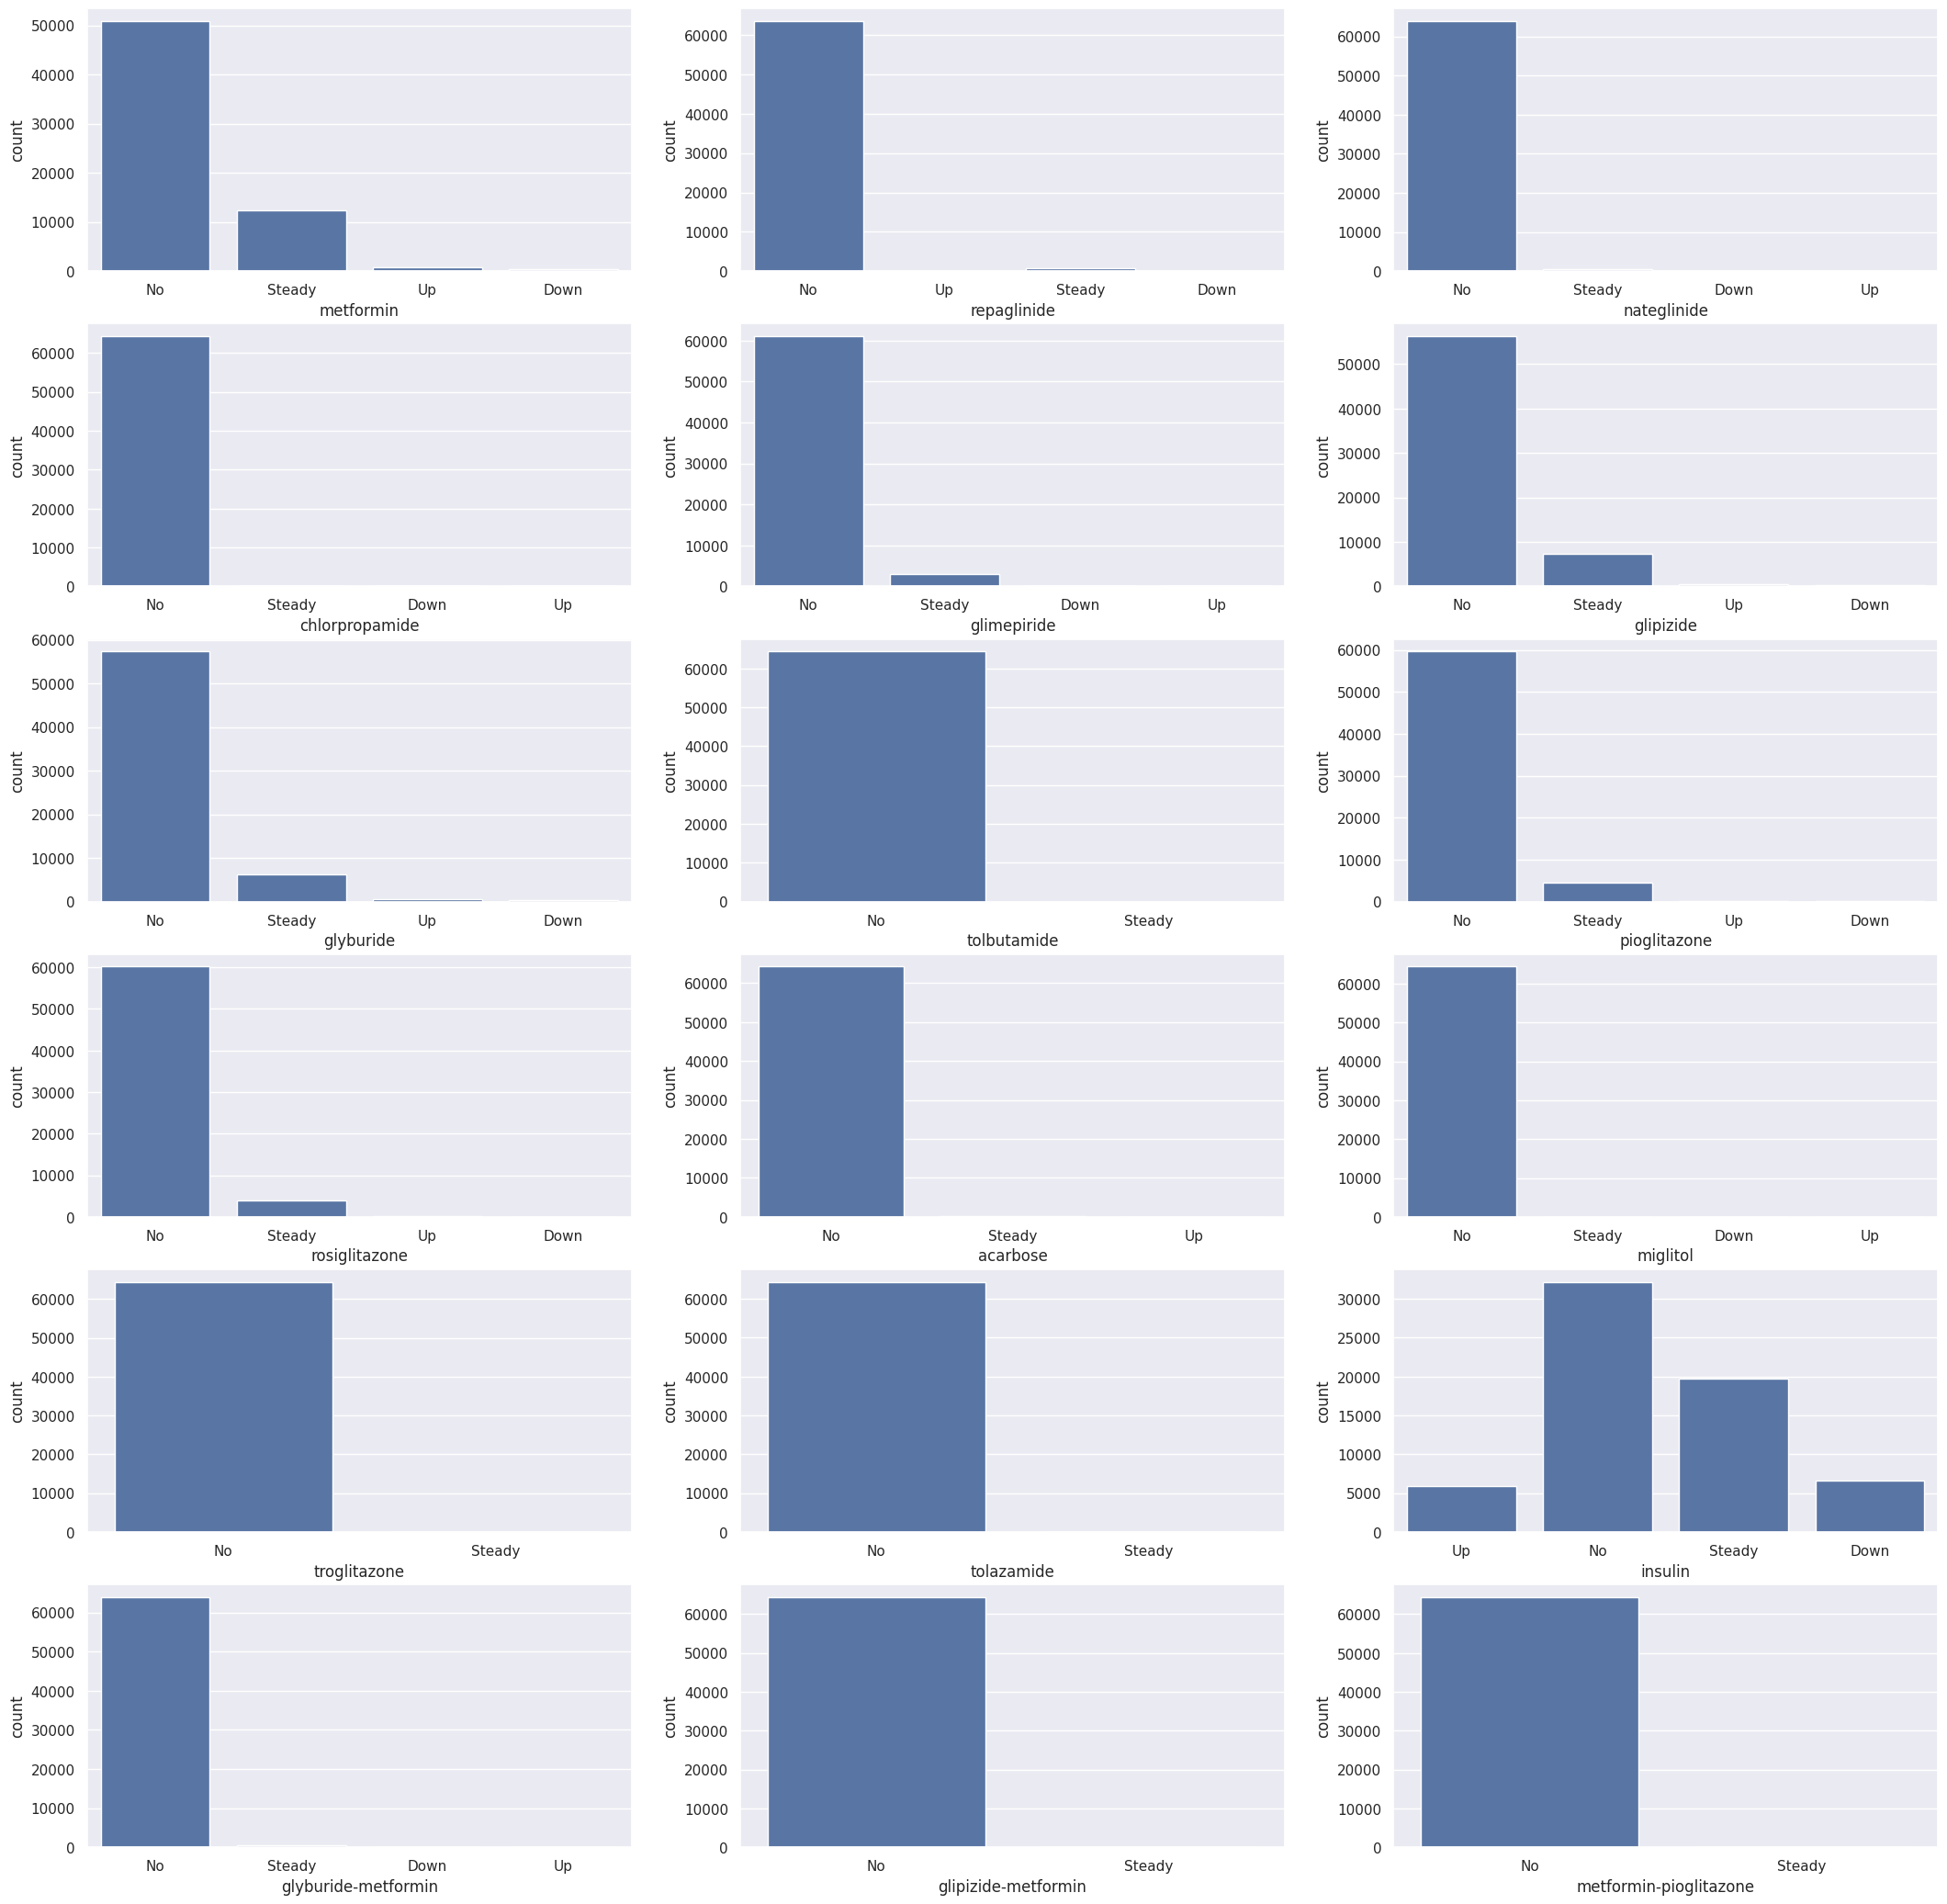

In [165]:
columns=['metformin', 'repaglinide', 'nateglinide',
       'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide',
       'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol',
       'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin',
       'glipizide-metformin', 'metformin-pioglitazone']

plt.figure(figsize=(26, 26))
for i,col in enumerate(columns):
    plt.subplot(6,3,i+1)
    sns.countplot(x=df[col])

> Dosages for insulin shows the most activity out of all diabetic medications, most of which aren't prescribed to patients.

In [166]:
info('insulin')

INSULIN : Available

0        Up
1        No
2        Up
3    Steady
4    Steady
Name: insulin, dtype: object


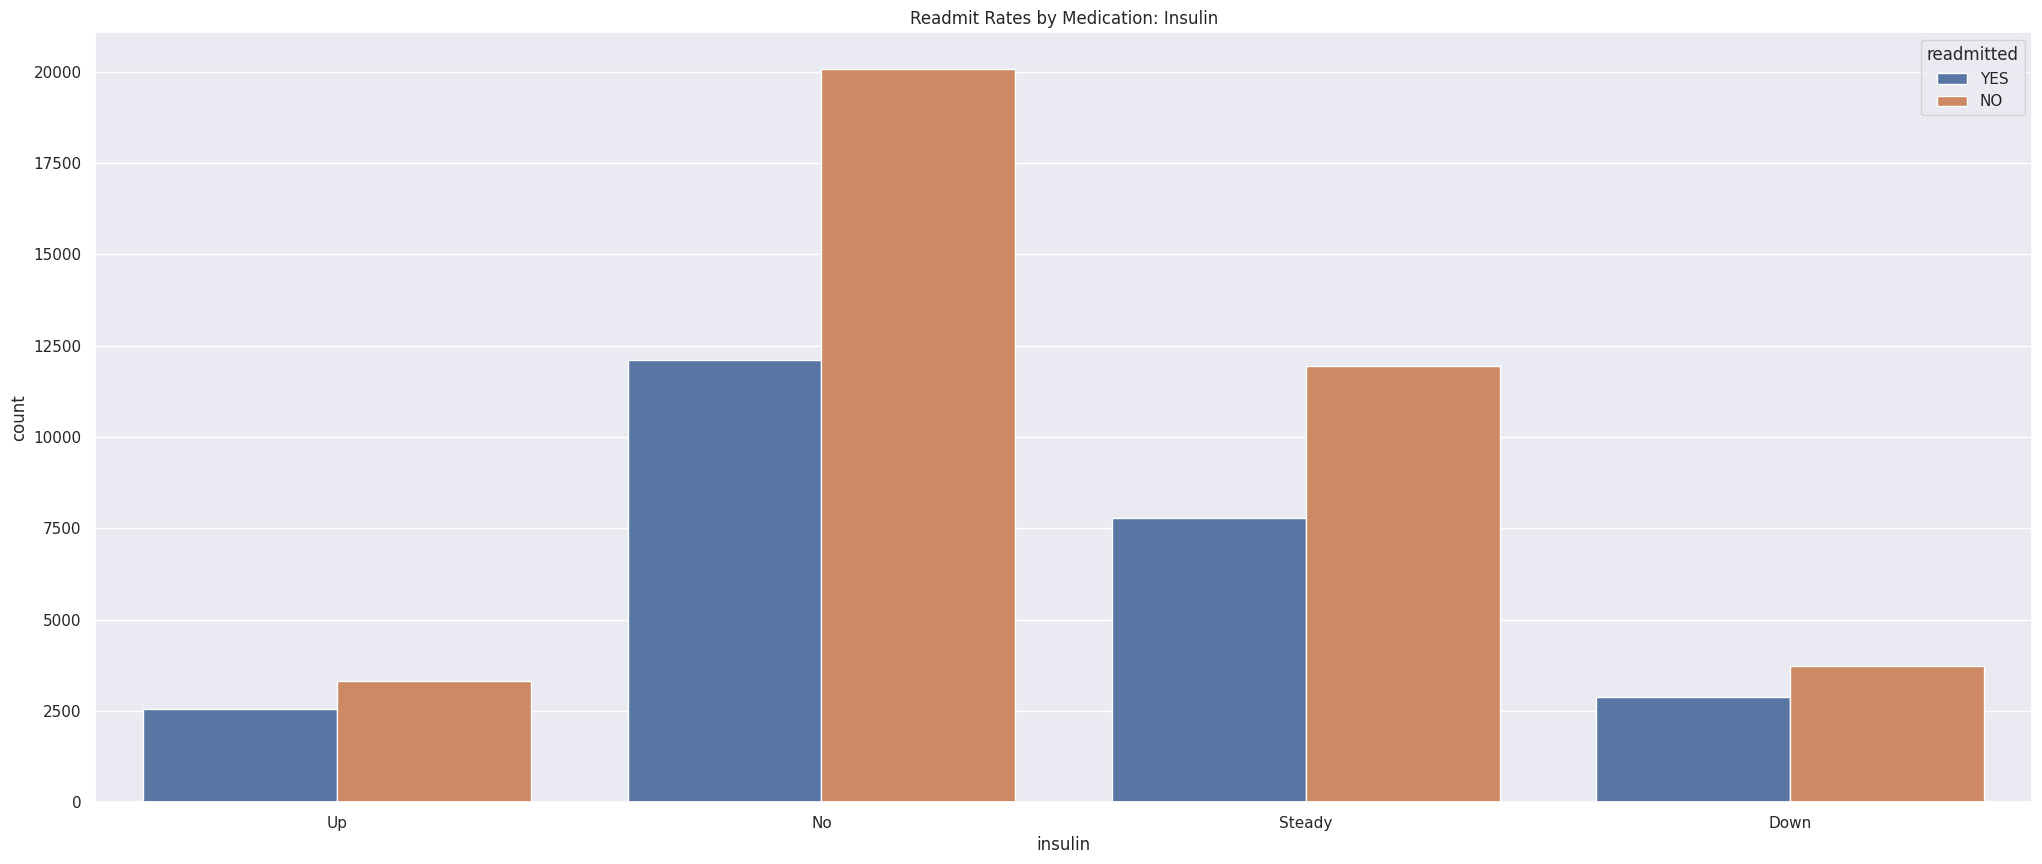

In [167]:
sns.countplot(x='insulin', hue='readmitted', data=df)
plt.title('Readmit Rates by Medication: Insulin')
plt.show()

# General Overview - Statistical Analysis

* We want to analyze the variables in this dataset to understand any relationships between them and their overall effects.
* To do this,
        * `Chi-square test` for categorical variables relationship
        * We have to analyze numerical variables using `analysis of variance` or `ANOVA test`.
* The purpose of these tests is to determine whether there is a statistically significant relationship between the target variable, readmissions and independent variable. Our p-value is 0.01, if anything above that, we cannot reject the null hypothesis.
* A machine learning model can interpret integers as well as process strings, so we must transform all categorical variables using dummy variables as numeric variables. This takes the string values ​​in a variable and converts them to columns labeled 0 or 1 relative to the string. We will also standardize the original numerical variables with a mean of 0 and a standard deviation of 1.
* Finally, we look at the correlation coefficients between the independent variables to make sure they do not have a strong influence on each other. The threshold we used is -0.7 <x <0.7.



### Import Libraries

In [168]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pylab import rcParams
rcParams['figure.figsize'] = 12,6

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')
warnings.warn("this will not show")

sns.set(style='darkgrid')
%matplotlib inline

import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import chi2_contingency
from numpy.random import seed
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

In [169]:
data = pd.read_csv('diabetic_data_cleaned.csv', index_col=0) # import data
df = data.copy() # save a copy of data as diabetes

In [170]:
#features = pd.read_csv('features.csv',index_col='Unnamed: 0')
#info = lambda attribute:print(f"{attribute.upper()} : {features[features['Feature']==attribute]['Description'].values[0]}\n")

In [171]:
#def summary(df, pred=None):
    #obs = df.shape[0]
    #Types = df.dtypes
    #Counts = df.apply(lambda x: x.count())
    #Min = df.min()
    #Max = df.max()
    #Uniques = df.apply(lambda x: x.unique().shape[0])
    #Nulls = df.apply(lambda x: x.isnull().sum())
    #print('Data shape:', df.shape)

    #if pred is None:
        #cols = ['Types', 'Counts', 'Uniques', 'Nulls', 'Min', 'Max']
        #str = pd.concat([Types, Counts, Uniques, Nulls, Min, Max], axis = 1, sort=True)

    #str.columns = cols
    #print('___________________________\nData Types:')
    #print(str.Types.value_counts())
    #print('___________________________')
    #return str

#summary(df)

In [172]:
df.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,64395.0,4.14,2.77,1.0,2.0,3.0,6.0,13.0
num_lab_procedures,64395.0,42.53,19.84,1.0,30.0,44.0,57.0,103.0
num_procedures,64395.0,1.39,1.72,0.0,0.0,1.0,2.0,6.0
num_medications,64395.0,15.11,7.20,1.0,10.0,14.0,19.0,40.0
number_outpatient,64395.0,0.17,0.54,0.0,0.0,0.0,0.0,3.0
number_emergency,64395.0,0.06,0.23,0.0,0.0,0.0,0.0,1.0
number_inpatient,64395.0,0.12,0.39,0.0,0.0,0.0,0.0,2.0
number_diagnoses,64395.0,7.23,1.97,2.0,6.0,8.0,9.0,9.0


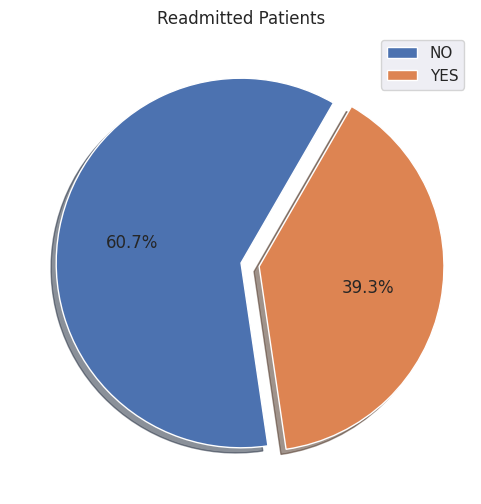

In [173]:
plt.figure(figsize=(6,6))

explode = [0,0.1]
plt.pie(df['readmitted'].value_counts(),explode=explode,autopct='%1.1f%%',shadow=True,startangle=60)
plt.legend(labels=df.readmitted.value_counts().index)
plt.title('Readmitted Patients')
plt.axis('off')
plt.show()

## Feature Selection
![How-to-Choose-Feature-Selection-Methods-For-Machine-Learning.png](attachment:How-to-Choose-Feature-Selection-Methods-For-Machine-Learning.png)

### categorical variables

In [174]:
print('Unique Values of Each Features:\n')
for i in df:
    try:
        print(f'{i}:\n{sorted(df[i].unique())}\n')
    except TypeError:
        # If sorting fails due to mixed types, print the unique values directly
        print(f'{i}:\n{df[i].unique()}\n')

Unique Values of Each Features:

race:
['AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other']

gender:
['Female', 'Male']

age:
['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

time_in_hospital:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]

num_lab_procedures:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), n

In [175]:
categorical=df.select_dtypes(include='object').columns.tolist()
print(categorical)

['race', 'gender', 'age', 'diag_1', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


* The categorical variables are:
<br>`['race', 'gender', 'age', 'diag_1', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']`


* We are using the chi-square test for association with a p-value of 0.01 to reject the null hypothesis.

## chi-square test for association

In [176]:
# define a function that returns a table, a chi-square value, and a p value
def chisquare_test(df, var_list, target, null_list=[]):
    for var in var_list:
        print(var.upper())
        chi_test = pd.crosstab(df[var], df[target])
        display(chi_test)

        chisq_value, pvalue, dataframe, expected = chi2_contingency(chi_test)

        print(f"""Chi-square value: {chisq_value:.2f}
p-value\t\t: {pvalue:.3f}\n""")

        if pvalue > 0.01: # adds variables that fail to reject the null hypothesis
            null_list.append(var)

    print(f'Fail to reject null hypothesis: {null_list}')

In [177]:
cols_cat = ['race','gender', 'age', 'diag_1', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']
null_list=[]
chisquare_test(df, cols_cat,'readmitted',null_list)

RACE


readmitted,NO,YES
race,,
AfricanAmerican,7467,4558
Asian,330,143
Caucasian,29598,19780
Hispanic,924,483
Other,744,368


Chi-square value: 70.49
p-value		: 0.000

GENDER


readmitted,NO,YES
gender,,
Female,20570,13722
Male,18493,11610


Chi-square value: 14.02
p-value		: 0.000

AGE


...

Chi-square value: 10.35
p-value		: 0.006

CHANGE


readmitted,NO,YES
change,,
Ch,16470,11781
No,22593,13551


Chi-square value: 117.57
p-value		: 0.000

DIABETESMED


readmitted,NO,YES
diabetesMed,,
No,10601,5366
Yes,28462,19966


Chi-square value: 291.97
p-value		: 0.000

Fail to reject null hypothesis: []


> Based on the chi-square value and p-value, we can safely say that there is no relation between the independent variables and the target variable.

### medications

In [178]:
medications = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
            'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
               'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
               'insulin', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone']
chisquare_test(df, medications,'readmitted', null_list)

METFORMIN


readmitted,NO,YES
metformin,,
Down,234,147
No,30687,20189
Steady,7674,4723
Up,468,273


Chi-square value: 12.55
p-value		: 0.006

REPAGLINIDE


readmitted,NO,YES
repaglinide,,
Down,15,11
No,38628,24921
Steady,382,373
Up,38,27


Chi-square value: 32.69
p-value		: 0.000

NATEGLINIDE


...

Chi-square value: 4.74
p-value		: 0.192

GLIPIZIDE-METFORMIN


readmitted,NO,YES
glipizide-metformin,,
No,39060,25328
Steady,3,4


Chi-square value: 0.33
p-value		: 0.564

METFORMIN-PIOGLITAZONE


readmitted,NO,YES
metformin-pioglitazone,,
No,39062,25332
Steady,1,0


Chi-square value: 0.00
p-value		: 1.000

Fail to reject null hypothesis: ['nateglinide', 'chlorpropamide', 'glimepiride', 'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone']


* The medications: nateglinide, chlorpropamide, glimepiride, acetohexamide, glyburide, tolbutamide, miglitol, troglitazone, tolazamide, glyburide-metformin, glipizide-metformin, and metformin-pioglitazone all failed to pass the test since they have p-values greater than 0.01.

* Since these variables are not independent of the target variable, we are removing them from the dataset.

In [179]:
print(null_list)

['nateglinide', 'chlorpropamide', 'glimepiride', 'tolbutamide', 'miglitol', 'troglitazone', 'tolazamide', 'glyburide-metformin', 'glipizide-metformin', 'metformin-pioglitazone']


In [180]:
# drop columns that do not pass the p-value test
df = df.drop(columns=null_list)

# numerical variables

## statistical testing - analysis of variance (ANOVA)

![one-way-ANOVA-formulas.png](attachment:one-way-ANOVA-formulas.png)

In [181]:
# The numerical variables
numerical=df.select_dtypes(include=['int64','float']).columns.tolist()
print(numerical)

['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


* Using the analysis of variance (ANOVA) test, we want to determine if there is a statistically significant relationship between a numerical variable and the categorical target variable. Our p-value threshold is 0.01.

In [182]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,64395.0,4.14,2.77,1.0,2.0,3.0,6.0,13.0
num_lab_procedures,64395.0,42.53,19.84,1.0,30.0,44.0,57.0,103.0
num_procedures,64395.0,1.39,1.72,0.0,0.0,1.0,2.0,6.0
num_medications,64395.0,15.11,7.20,1.0,10.0,14.0,19.0,40.0
number_outpatient,64395.0,0.17,0.54,0.0,0.0,0.0,0.0,3.0
number_emergency,64395.0,0.06,0.23,0.0,0.0,0.0,0.0,1.0
number_inpatient,64395.0,0.12,0.39,0.0,0.0,0.0,0.0,2.0
number_diagnoses,64395.0,7.23,1.97,2.0,6.0,8.0,9.0,9.0


In [183]:
# define a function that performs the ANOVA test and returns a table
def anova_table(var_list, null_list=[]):
    for var in var_list:
        print(var.upper())

        anova = ols('time_in_hospital ~ {}'.format(var), data=df).fit()
        table = sm.stats.anova_lm(anova, typ=2)
        pvalue=table['PR(>F)'][0]
        if pvalue > 0.01: # adds variables that fail to reject the null hypothesis
            null_list.append(var)
        display(table)
    print(f'Fail to reject null hypothesis: {null_list}')

In [184]:
anova_vars = ['readmitted']+numerical
anova_table(anova_vars)

READMITTED


,sum_sq,df,F,PR(>F)
readmitted,1814.955732,1.0,236.76566,2.483360e-53
Residual,493612.310825,64393.0,NaN,NaN


TIME_IN_HOSPITAL


,sum_sq,df,F,PR(>F)
time_in_hospital,4.954273e+05,1.0,1.712077e+33,0.0
Residual,1.863354e-23,64393.0,NaN,NaN


NUM_LAB_PROCEDURES


...

NUMBER_INPATIENT


,sum_sq,df,F,PR(>F)
number_inpatient,1940.163289,1.0,253.163525,6.814176e-57
Residual,493487.103269,64393.0,NaN,NaN


NUMBER_DIAGNOSES


,sum_sq,df,F,PR(>F)
number_diagnoses,26297.722016,1.0,3609.640948,0.0
Residual,469129.544542,64393.0,NaN,NaN


Fail to reject null hypothesis: ['number_emergency']


> Based on the ANOVA test, we can drop the number of emergency visits since we cannot reject the null hypothesis that the averages for each class are similar, the p-value is greater than our threshold of 0.01.

In [185]:
# drop number_emergency column
df = df.drop(columns=['number_emergency'])

# One Hot Encoding

Binary columns will be replaced with 0 for No and 1 for Yes. In the gender column, Male and Female will be replaced with 0 and 1 respectively.

In [186]:
# Unique Values of Each Features
for i in df:
    unique_values = df[i].unique()
    # Check if the column contains only numeric values
    is_numeric = all(pd.api.types.is_numeric_dtype(type(val)) for val in unique_values if not pd.isnull(val))

    if is_numeric:
        # Sort numerically if all values are numeric
        try:
            unique_values = sorted([pd.to_numeric(val) for val in unique_values])
        except (ValueError, TypeError):
            # Handle potential errors during numeric conversion
            unique_values = sorted(unique_values)
    else:
        # Sort as strings if the column contains non-numeric values
        unique_values = sorted(unique_values, key=str)  # Sort as strings

    print(f'{i}:\n{unique_values}\n')

race:
['AfricanAmerican', 'Asian', 'Caucasian', 'Hispanic', 'Other']

gender:
['Female', 'Male']

age:
['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

time_in_hospital:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]

num_lab_procedures:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int

In [187]:
df_dummy = pd.get_dummies(df,drop_first=True)
df_dummy.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_inpatient,number_diagnoses,race_Asian,race_Caucasian,race_Hispanic,...,rosiglitazone_Steady,rosiglitazone_Up,acarbose_Steady,acarbose_Up,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,readmitted_YES
0,3,59,0,18,0,0,9,False,True,False,...,False,False,False,False,False,False,True,False,True,True
1,2,11,5,13,2,1,6,False,False,False,...,False,False,False,False,True,False,False,True,True,False
2,2,44,1,16,0,0,7,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,51,0,8,0,0,5,False,True,False,...,False,False,False,False,False,True,False,False,True,False
4,3,31,6,16,0,0,9,False,True,False,...,False,False,False,False,False,True,False,True,True,True


# Are the features that affect readmissions correlated with each other?

If the correlation value is greater than 0.7 or less than -0.7, we have to drop one of the two columns.

The correlation map is quite large for this notebook. Instead, we are going to find each correlation coefficient individually and mark the ones that have a coefficient greater than 0.7 or less than -0.7.

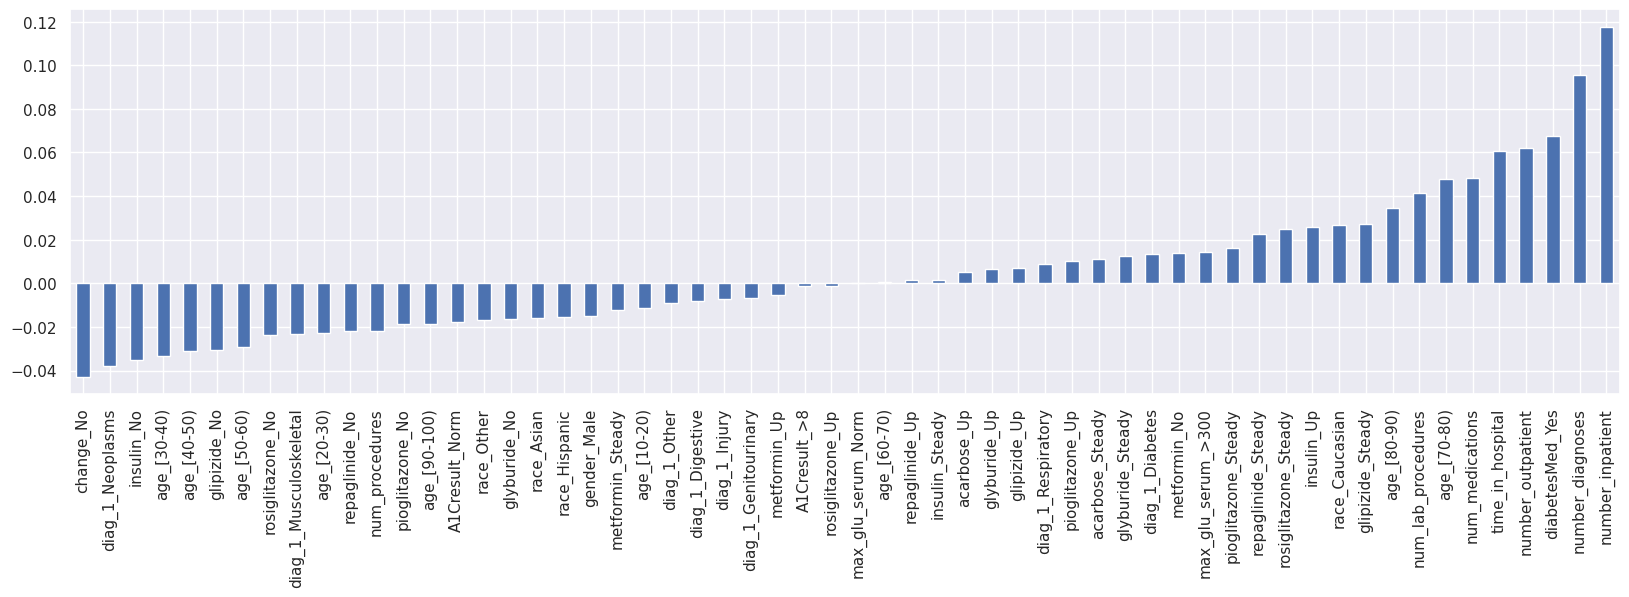

In [188]:
plt.figure(figsize=(20,5))
df_dummy.corr()["readmitted_YES"].sort_values()[:-1].plot.bar();

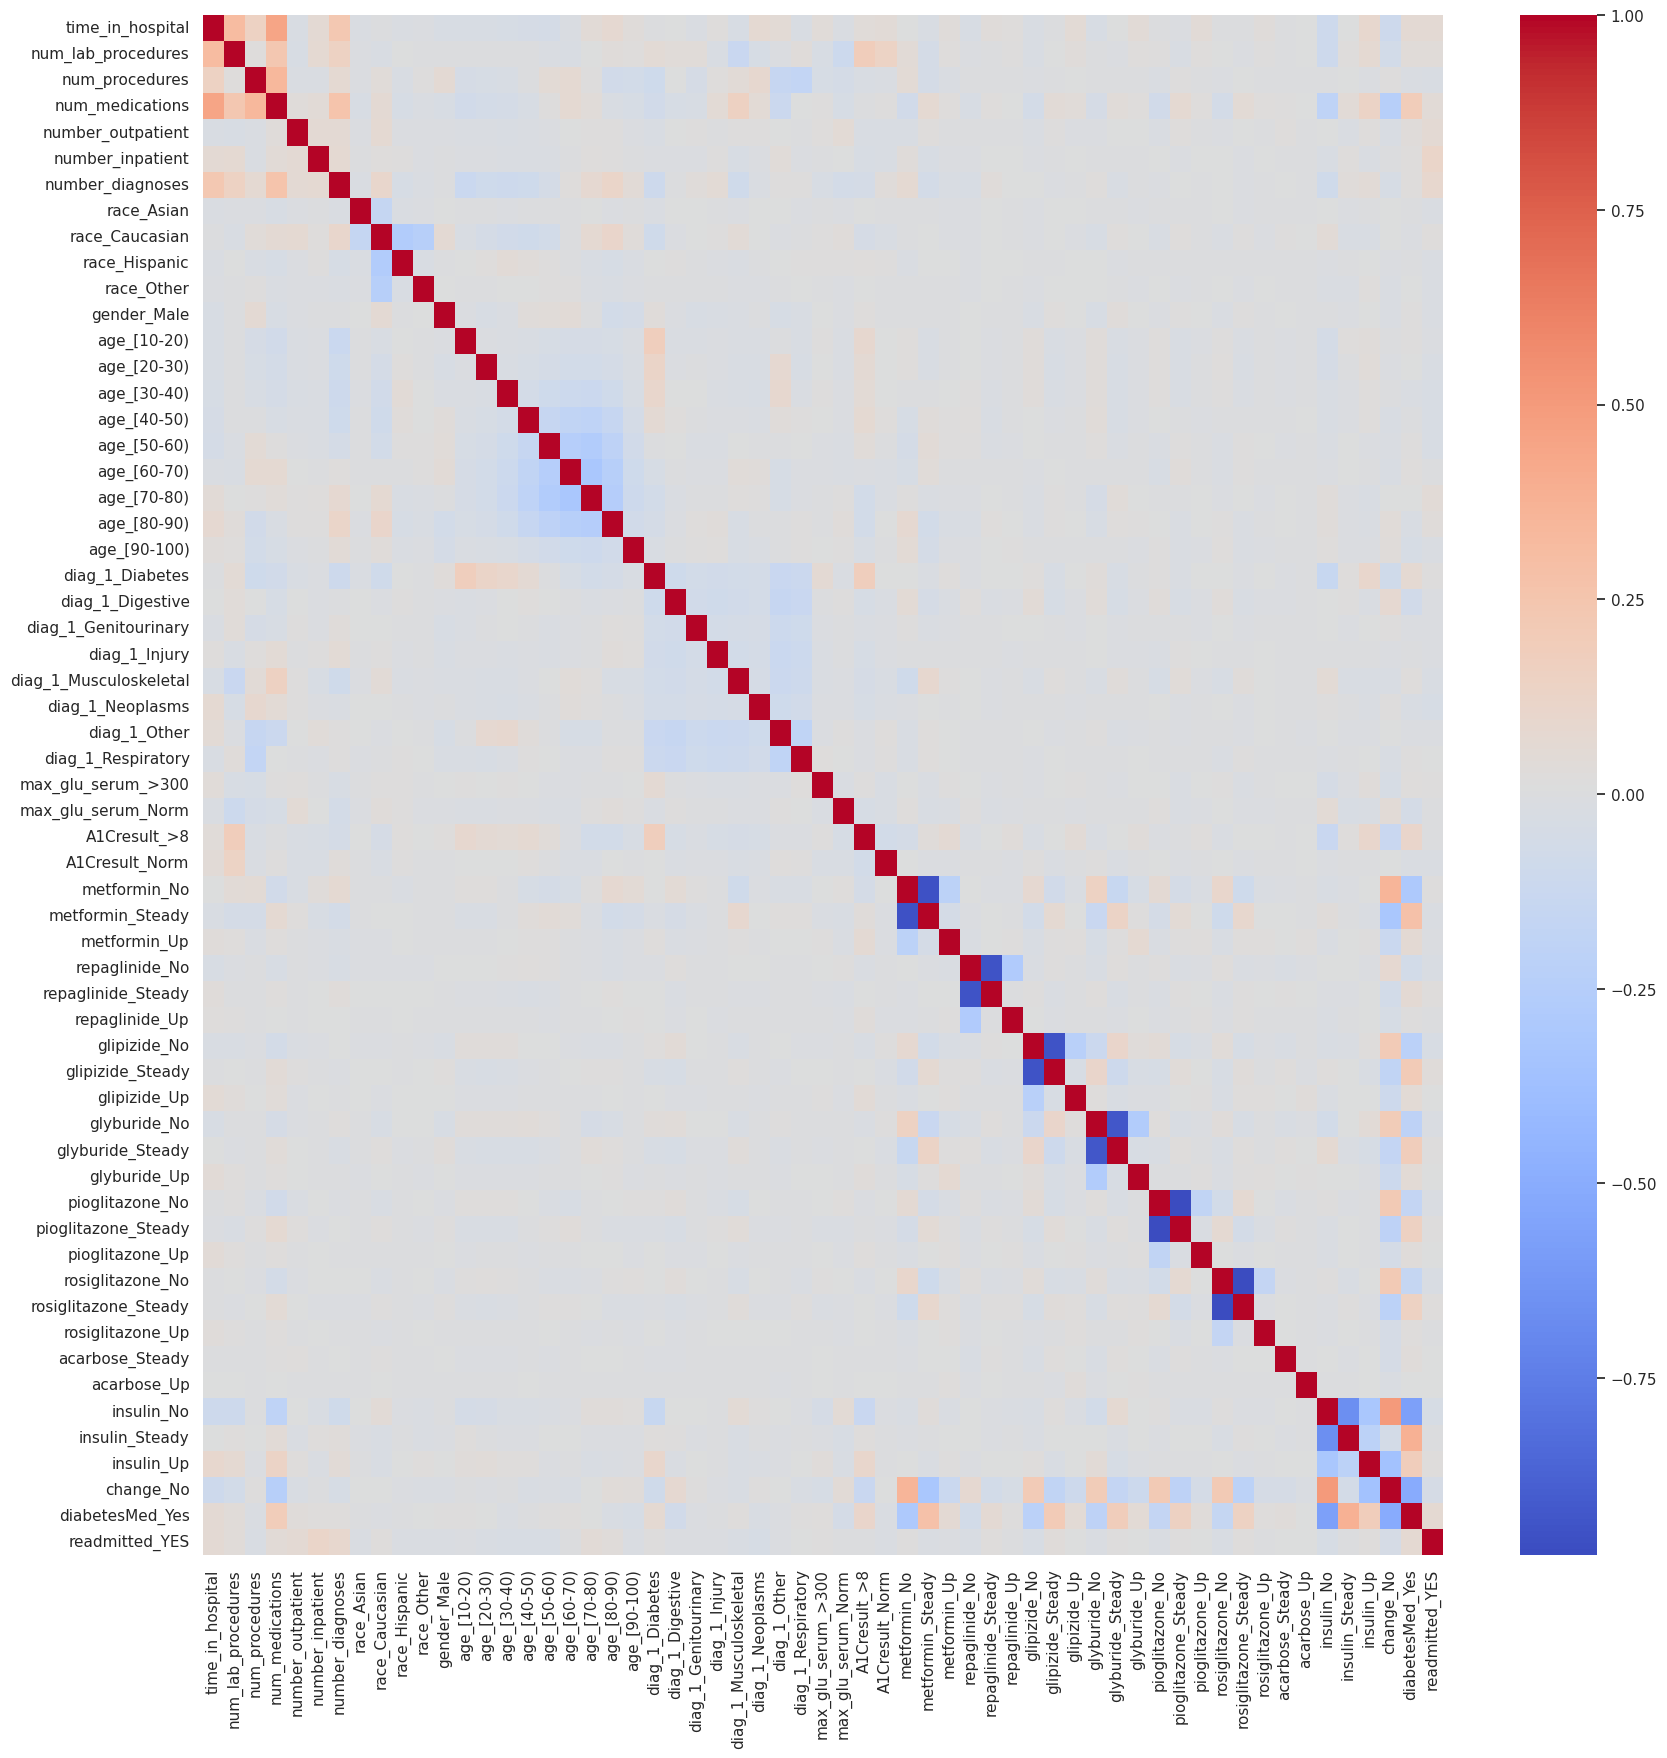

In [189]:
plt.figure(figsize=(20,20))
sns.heatmap(df_dummy.corr(), cmap="coolwarm");

In [190]:
def corrank(X, threshold=0):
    import itertools
    df = pd.DataFrame([[i,j,X.corr().abs().loc[i,j]] for i,j in list(itertools.combinations(X.corr().abs(), 2))],columns=['Feature1','Feature2','corr'])
    df = df.sort_values(by='corr',ascending=False).reset_index(drop=True)
    return df[df['corr']>threshold]

# prints a descending list of correlation pair (Max on top)
corrank(df_dummy, 0.7)

,Feature1,Feature2,corr
0,rosiglitazone_No,rosiglitazone_Steady,0.977145
1,pioglitazone_No,pioglitazone_Steady,0.973614
2,metformin_No,metformin_Steady,0.947216
3,repaglinide_No,repaglinide_Steady,0.944012
4,glipizide_No,glipizide_Steady,0.940760
5,glyburide_No,glyburide_Steady,0.924540


In [191]:
# Remove the highly collinear features from data
def remove_collinear_features(x, threshold):
    # Calculate the correlation matrix
    corr_matrix = x.corr()
    iters = range(len(corr_matrix.columns) - 1)
    drop_cols = []

    # Iterate through the correlation matrix and compare correlations
    for i in iters:
        for j in range(i+1):
            item = corr_matrix.iloc[j:(j+1), (i+1):(i+2)]
            col = item.columns
            row = item.index
            val = abs(item.values)

            # If correlation exceeds the threshold
            if val >= threshold:
                # Print the correlated features and the correlation value
                print(col.values[0], "|", row.values[0], "|", round(val[0][0], 2))
                drop_cols.append(col.values[0])

    # Drop one of each pair of correlated columns
    drops = set(drop_cols)
    x = x.drop(columns=drops)

    return x

In [192]:
#Remove columns having more than 70% correlation
#Both positive and negative correlations are considered here
df_dummy = remove_collinear_features(df_dummy,0.70)

metformin_Steady | metformin_No | 0.95
repaglinide_Steady | repaglinide_No | 0.94
glipizide_Steady | glipizide_No | 0.94
glyburide_Steady | glyburide_No | 0.92
pioglitazone_Steady | pioglitazone_No | 0.97
rosiglitazone_Steady | rosiglitazone_No | 0.98


In [193]:
df_dummy.shape

(64395, 53)

# saving machine learning dataset

In [194]:
# save dataset to new file for machine learning
df_dummy.to_csv('diabetic_data_cleaned_dummy.csv')

# General Overview - Machine Learning

### Import and Load

In [195]:
# for basic operations
import numpy as np
import pandas as pd

# for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

In [196]:
# for modeling
from xgboost.sklearn import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
# Instead of importing plot_precision_recall_curve directly, use PrecisionRecallDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# imbalanced learning
import imblearn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

# to avoid warnings
import warnings
warnings.filterwarnings('ignore')  # This could be more specific, e.g., ignoring specific warnings


In [197]:
data = pd.read_csv('diabetic_data_cleaned_dummy.csv', index_col=0)
df = data.copy()

df.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_inpatient,number_diagnoses,race_Asian,race_Caucasian,race_Hispanic,...,rosiglitazone_No,rosiglitazone_Up,acarbose_Steady,acarbose_Up,insulin_No,insulin_Steady,insulin_Up,change_No,diabetesMed_Yes,readmitted_YES
0,3,59,0,18,0,0,9,False,True,False,...,True,False,False,False,False,False,True,False,True,True
1,2,11,5,13,2,1,6,False,False,False,...,True,False,False,False,True,False,False,True,True,False
2,2,44,1,16,0,0,7,False,True,False,...,True,False,False,False,False,False,True,False,True,False
3,1,51,0,8,0,0,5,False,True,False,...,True,False,False,False,False,True,False,False,True,False
4,3,31,6,16,0,0,9,False,True,False,...,True,False,False,False,False,True,False,True,True,True


### Lazy Predict with 5000 samples

In [198]:
!pip install lazypredict

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.0/700.0 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.1 MB/s eta 0:00:00


In [199]:
from lazypredict.Supervised import LazyClassifier

df_5000 = df.sample(5000,random_state=42)
y = df_5000['readmitted_YES']
X = df_5000.drop('readmitted_YES', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state =42)

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

clf = LazyClassifier(verbose=0,ignore_warnings=True, custom_metric=None)
models,predictions = clf.fit(X_train, X_test, y_train, y_test)
models

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 1529, number of negative: 2221
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002333 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 296
[LightGBM] [Info] Number of data points in the train set: 3750, number of used features: 47
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.407733 -> initscore=-0.373344
[LightGBM] [Info] Start training from score -0.373344


,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
NearestCentroid,0.59,0.59,0.59,0.59,0.07
LGBMClassifier,0.59,0.56,0.56,0.58,0.21
BernoulliNB,0.59,0.55,0.55,0.57,0.04
RandomForestClassifier,0.60,0.55,0.55,0.57,0.76
CalibratedClassifierCV,0.62,0.54,0.54,0.54,0.20
XGBClassifier,0.58,0.54,0.54,0.56,0.20
SVC,0.60,0.54,0.54,0.55,1.32
LinearDiscriminantAnalysis,0.60,0.54,0.54,0.55,0.14
LogisticRegression,0.60,0.54,0.54,0.55,0.09


### Split Data

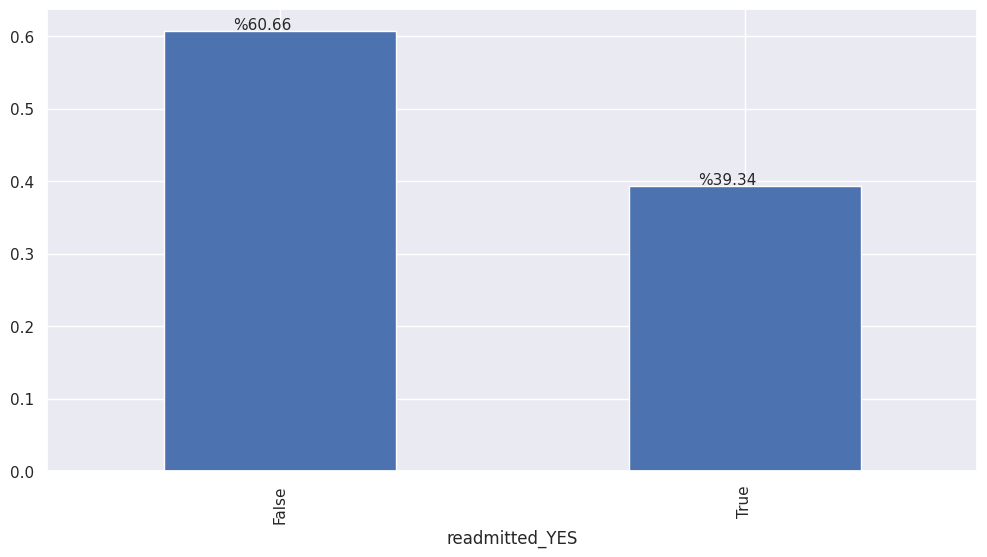

In [200]:
ax = df['readmitted_YES'].value_counts(normalize=True).plot.bar()
def labels(ax):
    for p in ax.patches:
        ax.annotate(f"%{p.get_height()*100:.2f}", (p.get_x() + 0.15, p.get_height() * 1.005),size=11)
labels(ax)

In [201]:
# separating the dependent and independent data
X = df.drop('readmitted_YES', axis=1)
y = df['readmitted_YES']

# the function train_test_split creates random data samples (default: 75-25%)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# getting the shapes
print(f"""shape of X_train: {X_train.shape}
shape of X_test\t: {X_test.shape}
shape of y_train: {y_train.shape}
shape of y_test\t: {y_test.shape}""")

shape of X_train: (48296, 52)
shape of X_test	: (16099, 52)
shape of y_train: (48296,)
shape of y_test	: (16099,)


### Data Scaling

In [202]:
# creating a standard scaler
sc = StandardScaler()

# fitting independent data to the model
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Iteration 1: (Unbalanced data)
![CM-1024x382.png](attachment:CM-1024x382.png)

In [203]:
cv_acc_train = {}
cv_acc_test = {}
cv_TPR = {}
cv_FPR = {}
cv_AUC = {}

In [204]:
def plot_result(model, name:str):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train, y_train, cv=10, scoring = 'balanced_accuracy')
    scores_test = cross_val_score(model, X_test, y_test, cv=10, scoring = 'balanced_accuracy')
    cv_acc_train[name] = round(scores_train.mean(), 4)*100  # balanced accuracy
    cv_acc_test[name] = round(scores_test.mean(), 4)*100  # balanced accuracy
    cv_TPR[name] = (confusion_matrix(y_test, y_pred)[1][1]/confusion_matrix(y_test, y_pred)[1].sum())*100  # recall (Max)
    cv_FPR[name] = (confusion_matrix(y_test, y_pred)[0][1]/confusion_matrix(y_test, y_pred)[0].sum())*100  # fallout (Min)

    # accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())
    print('Average Balanced Accuracy (CV=10), Training Set: ', scores_train.mean())

    # print classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot Confusion Matrix
    plot_confusion_matrix(model, X_test, y_test)
    plt.show()

### 1-Decision tree

In [205]:
!pip install -U scikit-learn

In [206]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay  # Import ConfusionMatrixDisplay

In [207]:
def plot_result(model, name:str):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train, y_train, cv=10, scoring = 'balanced_accuracy')
    scores_test = cross_val_score(model, X_test, y_test, cv=10, scoring = 'balanced_accuracy')
    cv_acc_train[name] = round(scores_train.mean(), 4)*100  # balanced accuracy
    cv_acc_test[name] = round(scores_test.mean(), 4)*100  # balanced accuracy
    cv_TPR[name] = (confusion_matrix(y_test, y_pred)[1][1]/confusion_matrix(y_test, y_pred)[1].sum())*100  # recall (Max)
    cv_FPR[name] = (confusion_matrix(y_test, y_pred)[0][1]/confusion_matrix(y_test, y_pred)[0].sum())*100  # fallout (Min)

    # accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())
    print('Average Balanced Accuracy (CV=10), Training Set: ', scores_train.mean())

    # print classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot Confusion Matrix
    # Use ConfusionMatrixDisplay.from_estimator instead of plot_confusion_matrix
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.show()

Average Balanced Accuracy (CV=10), Test Set: 0.5166725673039203
Average Balanced Accuracy (CV=10), Training Set:  0.5215458617619249
              precision    recall  f1-score   support

       False       0.62      0.62      0.62      9766
        True       0.42      0.41      0.42      6333

    accuracy                           0.54     16099
   macro avg       0.52      0.52      0.52     16099
weighted avg       0.54      0.54      0.54     16099



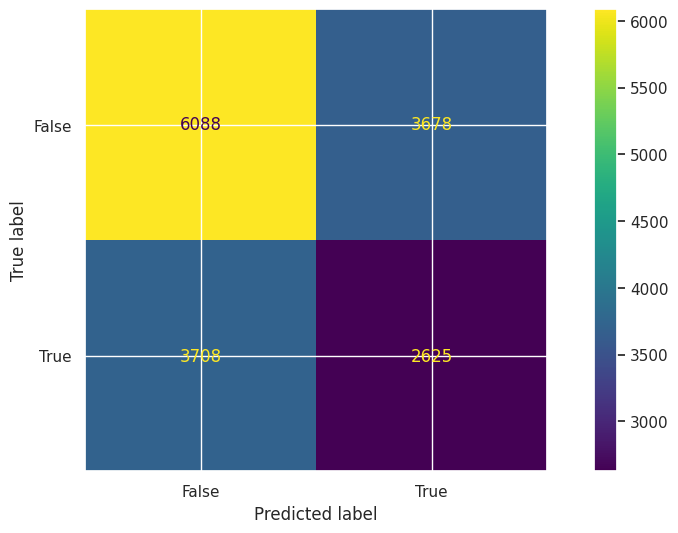

In [208]:
dtc = DecisionTreeClassifier()
plot_result(dtc, "dtc")

In [209]:
# plot tree
# plt.figure(figsize=(16,6))
# plot_tree(dtc, filled = True, class_names=["-1", "1"], feature_names=X.columns, fontsize=11);

In [210]:
cv_acc_train, cv_acc_test, cv_TPR, cv_FPR

({'dtc': np.float64(52.15)},
 {'dtc': np.float64(51.67)},
 {'dtc': np.float64(41.44954997631454)},
 {'dtc': np.float64(37.66127380708581)})

### 2-Logistic Regression

In [211]:
from sklearn.linear_model import LogisticRegression

Average Balanced Accuracy (CV=10), Test Set: 0.5405204454615642
Average Balanced Accuracy (CV=10), Training Set:  0.5445819992762388
              precision    recall  f1-score   support

       False       0.63      0.90      0.74      9766
        True       0.55      0.18      0.27      6333

    accuracy                           0.62     16099
   macro avg       0.59      0.54      0.51     16099
weighted avg       0.60      0.62      0.56     16099



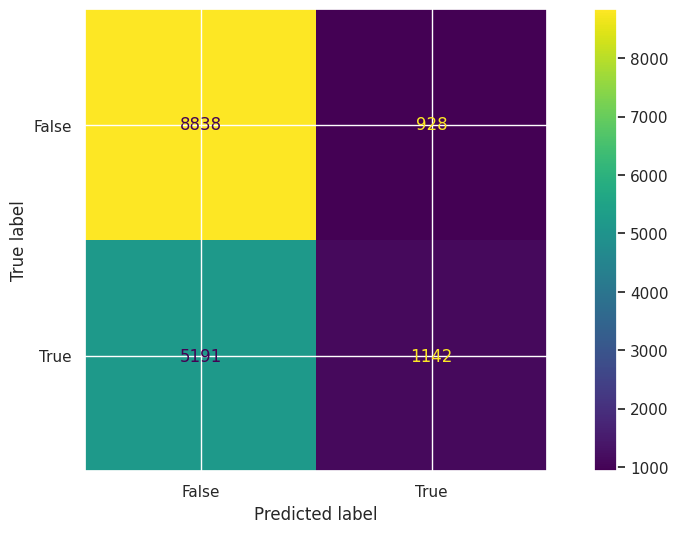

In [212]:
lr = LogisticRegression()
plot_result(lr, "lr")

### 3-SVC

In [213]:
# svc = SVC(probability=True)  # default values
# plot_result(svc, "svc")

### 4-NearestCentroid

In [214]:
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import plot_confusion_matrix, classification_report, confusion_matrix

ImportError: cannot import name 'plot_confusion_matrix' from 'sklearn.metrics' (/usr/local/lib/python3.11/dist-packages/sklearn/metrics/__init__.py)

In [ ]:
nc = NearestCentroid()
plot_result(nc, "nc")

### 5-Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rfc = RandomForestClassifier()
plot_result(rfc, "rfc")

In [ ]:
def plot_feature_importances(model):
    feature_imp = pd.Series(model.feature_importances_,index=X.columns).sort_values(ascending=False)[:10]

    sns.barplot(x=feature_imp, y=feature_imp.index)
    plt.title("Feature Importance")
    plt.show()

    print(f"Top 10 Feature Importance for {str(model).split('(')[0]}\n\n",feature_imp[:10],sep='')

In [ ]:
plot_feature_importances(rfc)

### 6-Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gbc = GradientBoostingClassifier(random_state=42)
plot_result(gbc, "gbc")

In [ ]:
plot_feature_importances(gbc)

### 7-Naive Bayes

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
nb = GaussianNB()
plot_result(nb, "nb")

### 8-kNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()
plot_result(knn, "knn")

### 9-XGBOOST

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score

In [ ]:
xgb = XGBClassifier(eval_metric = "logloss")
plot_result(xgb, "xgb")

In [ ]:
plot_feature_importances(xgb)

In [ ]:
from xgboost import plot_importance
plot_importance(xgb,max_num_features=10)
plt.xlabel('The F-Score for each features')
plt.ylabel('Importances')
plt.show()

### Evaluation (iteration 1)

In [ ]:

def AUC(cv_AUC, X_test=X_test):
    dtc_auc= roc_auc_score(y_test,dtc.predict(X_test)) #Decision Tree Classifier
    lr_auc= roc_auc_score(y_test, lr.decision_function(X_test))#logistic regression
#     svc_auc= roc_auc_score(y_test, svc.decision_function(X_test))#Support Vector Classifier
    nc_auc= roc_auc_score(y_test, nc.predict(X_test))#Nearest Centroid Classifier
    rfc_auc= roc_auc_score(y_test, rfc.predict_proba(X_test)[:,1])#Randomforest Classifier
    gbc_auc= roc_auc_score(y_test, gbc.predict_proba(X_test)[:,1])#GradientBoosting Classifier
    nb_auc= roc_auc_score(y_test, nb.predict_proba(X_test)[:,1])#Naive Bayes Classifier
    knn_auc= roc_auc_score(y_test, knn.predict(X_test))#KNeighbors Classifier
    xgb_auc= roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])#XGBoost Classifier

    cv_AUC={'dtc': dtc_auc,
           'lr': lr_auc,
#            'svc':svc_auc,
           'nc':nc_auc,
           'rfc':rfc_auc,
           'gbc':gbc_auc,
           'nb':nb_auc,
           'knn':knn_auc,
           'xgb':xgb_auc}
    return cv_AUC

In [ ]:
cv_AUC = AUC(cv_AUC)
df_eval = pd.DataFrame(data={'model': list(cv_acc_test.keys()),
                             'bal_acc_train':list(cv_acc_train.values()),
                             'bal_acc_test': list(cv_acc_test.values()),
                             'recall': list(cv_TPR.values()),
                             'fallout':list(cv_FPR.values()),
                              'AUC': list(cv_AUC.values())}).round(2)
df_eval

In [ ]:
def plot_ROC(X_test=X_test, y_test=y_test):
    fpr_dtc, tpr_dtc, thresholds = roc_curve(y_test,dtc.predict(X_test)) #Decision Tree Classifier
    fpr_lr, tpr_lr, thresholds = roc_curve(y_test, lr.decision_function(X_test))#logistic regression
#     fpr_svc, tpr_svc, thresholds = roc_curve(y_test, svc.decision_function(X_test))#Support Vector Classifier
    fpr_nc, tpr_nc, thresholds = roc_curve(y_test, nc.predict(X_test))#Nearest Centroid Classifier
    fpr_rfc, tpr_rfc, thresholds = roc_curve(y_test, rfc.predict_proba(X_test)[:,1])#Randomforest Classifier
    fpr_gbc, tpr_gbc, thresholds = roc_curve(y_test, gbc.predict_proba(X_test)[:,1])#GradientBoosting Classifier
    fpr_nb, tpr_nb, thresholds = roc_curve(y_test, nb.predict_proba(X_test)[:,1])#Naive Bayes Classifier
    fpr_knn, tpr_knn, thresholds = roc_curve(y_test, knn.predict(X_test))#KNeighbors Classifier
    fpr_xgb, tpr_xgb, thresholds = roc_curve(y_test, xgb.predict_proba(X_test)[:,1])#XGBoost Classifier

    #compare the ROC curve between different models
    plt.figure(figsize=(10,10))
    plt.plot(fpr_dtc, tpr_dtc, label='Decision Tree Classifier')
    plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
#     plt.plot(fpr_svc, tpr_svc, label='Support Vector Classifier')
    plt.plot(fpr_nc, tpr_nc, label='Nearest Centroid Classifier')
    plt.plot(fpr_rfc, tpr_rfc, label='Randomforest Classifier')
    plt.plot(fpr_gbc, tpr_gbc, label='GradientBoosting Classifier')
    plt.plot(fpr_nb, tpr_nb, label='Naive Bayes Classifier')
    plt.plot(fpr_knn, tpr_knn, label='KNeighbors Classifier')
    plt.plot(fpr_xgb, tpr_xgb, label='XGBoost Classifier')

    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
             label='random', alpha=.8)
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xticks(np.arange(0,1.1,0.1))
    plt.yticks(np.arange(0,1.1,0.1))
    plt.grid()
    plt.legend()
    plt.axes().set_aspect('equal')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_ROC()

In [ ]:
fig, ax = plt.subplots(1,4, figsize=(20, 4))
sns.barplot(x="bal_acc_train", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0])
ax[0].set_title("Unbalanced Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval.sort_values(by="recall"), ax=ax[1])
ax[1].set_title("Unbalanced Test Acc")
sns.barplot(x="recall", y="model", data=df_eval.sort_values(by="recall"), ax=ax[2])
ax[2].set_title("Unbalanced Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval.sort_values(by="recall"), ax=ax[3])
ax[3].set_title("Unbalanced Test FPR")
plt.show()

> NaiveBayes gave high BalanceAccuracy and TPR_Score (Recall), but it gave the poor FPR_Score (Fallout) in this unbalanced data set.

### Iteration 2: (Oversampling with SMOTE)

![resampling-techniques-in-machine-learning-15-638.jpg](attachment:resampling-techniques-in-machine-learning-15-638.jpg)

### Balancing data

In [ ]:
y_test.value_counts(normalize=True)

In [ ]:
y_train.value_counts(normalize=True)

In [ ]:
# pip install imblearn
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE

In [ ]:
oversmote = SMOTE()
X_train_os, y_train_os= oversmote.fit_resample(X_train, y_train)

In [ ]:
ax = y_train_os.value_counts().plot.bar(color=["blue", "red"])
def labels(ax):
    for p in ax.patches:
        ax.annotate(f"{p.get_height()}", (p.get_x() + 0.15, p.get_height()+200),size=8)
labels(ax)
plt.show()

In [ ]:
X_train_os.shape

### Use algorithms

In [ ]:
cv_acc_balance_train = {}
cv_acc_balance_test = {}
cv_TPR_balance = {}
cv_FPR_balance = {}
cv_AUC_balance = {}

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_result_smote(model, name: str):
    model.fit(X_train_os, y_train_os)
    y_pred = model.predict(X_test)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train, y_train, cv=10, scoring='balanced_accuracy')
    scores_test = cross_val_score(model, X_test, y_test, cv=10, scoring='balanced_accuracy')

    cv_acc_balance_train[name] = round(scores_train.mean(), 4) * 100
    cv_acc_balance_test[name] = round(scores_test.mean(), 4) * 100
    cv_TPR_balance[name] = (confusion_matrix(y_test, y_pred)[1][1] / confusion_matrix(y_test, y_pred)[1].sum()) * 100
    cv_FPR_balance[name] = (confusion_matrix(y_test, y_pred)[0][1] / confusion_matrix(y_test, y_pred)[0].sum()) * 100

    # Accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())
    print('Average Balanced Accuracy (CV=10), Training Set:', scores_train.mean())

    # Print classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot confusion matrix using ConfusionMatrixDisplay
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.show()


In [ ]:
# Decision tree
dtc = DecisionTreeClassifier()

plot_result_smote(dtc, "dtc")

In [ ]:
# Logistic Regression
lr = LogisticRegression()
plot_result_smote(lr, "lr")

In [ ]:
# NearestCentroid
nc = NearestCentroid()
plot_result_smote(nc, "nc")

In [ ]:
# # SVC
# svc = SVC()
# plot_result_smote(svc, "svc")

In [ ]:
# Random Forest
rfc = RandomForestClassifier()
plot_result_smote(rfc, "rfc")

In [ ]:
# Gradient Boost
gbc = GradientBoostingClassifier(random_state=42)
plot_result_smote(gbc, "gbc")

In [ ]:
# Naive Bayes
nb = GaussianNB()
plot_result_smote(nb, "nb")

In [ ]:
# kNN
knn = KNeighborsClassifier()
plot_result_smote(knn, "knn")

In [ ]:
# XGBOOST
xgb = XGBClassifier(eval_metric = "logloss", random_state=42)
plot_result_smote(xgb, "xgb")

In [ ]:
cv_AUC_balance = AUC(cv_AUC_balance)

In [ ]:
df_eval_smote = pd.DataFrame(data={'model': list(cv_acc_balance_test.keys()),
                                   'bal_acc_train':list(cv_acc_balance_train.values()),
                                   'bal_acc_test': list(cv_acc_balance_test.values()),
                                   'recall': list(cv_TPR_balance.values()),
                                   'fallout':list(cv_FPR_balance.values()),
                                   'AUC': list(cv_AUC_balance.values())}).round(2)
df_eval_smote

In [ ]:
fig, ax = plt.subplots(2,4, figsize=(20, 8))

sns.barplot(x="bal_acc_train", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,0])
ax[0,0].set_title("Unbalanced Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,1])
ax[0,1].set_title("Unbalanced Test Acc")
sns.barplot(x="recall", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,2])
ax[0,2].set_title("Unbalanced Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,3])
ax[0,3].set_title("Unbalanced Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,0])
ax[1,0].set_title("Smote Model Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,1])
ax[1,1].set_title("Smote Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,2])
ax[1,2].set_title("Smote Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,3])
ax[1,3].set_title("Smote Model Test FPR")

plt.tight_layout()
plt.show()

In [ ]:
plot_ROC()

GradientBoosting yielded the optimized result as better FPR and relative mean strong recall scores. The balance accuracy is also relatively good.

## Iteration 3: (with RUS)

In [ ]:
import imblearn
from imblearn.under_sampling import RandomUnderSampler, EditedNearestNeighbours, NearMiss

In [ ]:
under_sampler = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = under_sampler.fit_resample(X_train, y_train)


In [ ]:
ax = y_train_rus.value_counts().plot.bar(color=["blue", "red"])
labels(ax)
plt.show()

#### Use Algorithm

In [ ]:
cv_acc_rus_train = {}
cv_acc_rus_test = {}
cv_TPR_rus = {}
cv_FPR_rus = {}
cv_AUC_rus = {}

In [ ]:
def plot_result_rus(model, name: str):
    # Train model
    model.fit(X_train_rus, y_train_rus)
    y_pred = model.predict(X_test)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train, y_train, cv=10, scoring='balanced_accuracy')
    scores_test = cross_val_score(model, X_test, y_test, cv=10, scoring='balanced_accuracy')

    # Save results
    cv_acc_rus_train[name] = round(scores_train.mean(), 4) * 100  # balanced accuracy train
    cv_acc_rus_test[name] = round(scores_test.mean(), 4) * 100    # balanced accuracy test
    cv_TPR_rus[name] = (confusion_matrix(y_test, y_pred)[1][1] / confusion_matrix(y_test, y_pred)[1].sum()) * 100  # recall
    cv_FPR_rus[name] = (confusion_matrix(y_test, y_pred)[0][1] / confusion_matrix(y_test, y_pred)[0].sum()) * 100  # fallout

    # Accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())
    print('Average Balanced Accuracy (CV=10), Training Set:', scores_train.mean())

    # Classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix plot
    plt.figure(figsize=(3, 3))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"Confusion Matrix: {name}")
    plt.show()


In [ ]:
# Decision tree
dtc = DecisionTreeClassifier()

plot_result_rus(dtc, "dtc")

In [ ]:
# Logistic Regression
lr = LogisticRegression()
plot_result_rus(lr, "lr")

In [ ]:
# NearestCentroid
nc = NearestCentroid()
plot_result_rus(nc, "nc")

In [ ]:
# # SVC
# svc = SVC()
# plot_result_rus(svc, "svc")

In [ ]:
# Random Forest
rfc = RandomForestClassifier()
plot_result_rus(rfc, "rfc")

In [ ]:
# Gradient Boost
gbc = GradientBoostingClassifier(random_state=42)
plot_result_rus(gbc, "gbc")

In [ ]:
# Naive Bayes
nb = GaussianNB()
plot_result_rus(nb, "nb")

In [ ]:
# kNN
knn = KNeighborsClassifier()
plot_result_rus(knn, "knn")

In [ ]:
# XGBOOST
xgb = XGBClassifier(eval_metric = "logloss",random_state=42)
plot_result_rus(xgb, "xgb");

In [ ]:
cv_AUC_rus = AUC(cv_AUC_rus)

In [ ]:
df_eval_rus = pd.DataFrame(data={'model': list(cv_acc_rus_train.keys()),
                             'bal_acc_train':list(cv_acc_rus_train.values()),
                             'bal_acc_test': list(cv_acc_rus_test.values()),
                             'recall': list(cv_TPR_rus.values()),
                             'fallout':list(cv_FPR_rus.values()),
                             'AUC': list(cv_AUC_rus.values())}).round(2)
df_eval_rus

In [ ]:
fig, ax = plt.subplots(3,4, figsize=(20, 12))

sns.barplot(x="bal_acc_train", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,0])
ax[0,0].set_title("Unbalanced Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,1])
ax[0,1].set_title("Unbalanced Test Acc")
sns.barplot(x="recall", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,2])
ax[0,2].set_title("Unbalanced Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,3])
ax[0,3].set_title("Unbalanced Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,0])
ax[1,0].set_title("Smote Model Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,1])
ax[1,1].set_title("Smote Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,2])
ax[1,2].set_title("Smote Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,3])
ax[1,3].set_title("Smote Model Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,0])
ax[2,0].set_title("RUS_Featured Model Test Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,1])
ax[2,1].set_title("RUS_Featured Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,2])
ax[2,2].set_title("RUS_Featured Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,3])
ax[2,3].set_title("RUS_Featured Model Test FPR")

plt.tight_layout()
plt.show()

In [ ]:
plot_ROC()

## Iteration 4: (with SMOTE and PCA)

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA().fit(X_train_os)

In [ ]:
# Fix lengths first
xi = xi[:len(y)]

# Now plotting
import matplotlib.pyplot as plt

plt.ylim(0.0, 1.1)
plt.plot(xi, y, marker='.', linestyle='--', color='b')
plt.xlabel('Number of Components')
plt.ylabel('Metric (e.g., Accuracy or Explained Variance)')
plt.title('Metric vs Number of Components')
plt.grid(True)
plt.show()


It looks like n_components = 43 is suitable for% 95 total explained variance,

In [ ]:
pca = PCA(n_components=43)
pca.fit(X_train_os)
per_var = np.round(pca.explained_variance_ratio_ * 100, 1)
labels = ['PC' + str(x) for x in range(1,len(per_var)+1)]

plt.figure(figsize=(20,6))
plt.bar(x=range(len(per_var)), height=per_var, tick_label=labels)
plt.title('Total explained variance {}'.format(np.round(sum(per_var),2)))
plt.ylabel('Explained variance in percent')
plt.xticks(rotation=90)
plt.show()

In [ ]:
X_train_os_pca = pca.transform(X_train_os)
pd.DataFrame(X_train_os_pca)

The loads (loading scores) indicate "how high a variable X loads on a factor Y".

(The i-th principal components can be selected via i in pca.components_ [0].)

In [ ]:
# Top 20 columns that have the greatest impact
loading_scores = pd.Series(pca.components_[0], index=X.columns)
loading_scores.abs().sort_values(ascending=False)[:20]

#### Use Algorithm

In [ ]:
X_test_pca = pca.transform(X_test)

In [ ]:
cv_acc_balance_train_pca = {}
cv_acc_balance_test_pca = {}
cv_TPR_balance_pca = {}
cv_FPR_balance_pca = {}
cv_AUC_balance_pca = {}

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_result_smoted_pca(model, name:str):
    # Fit the model
    model.fit(X_train_os_pca, y_train_os)
    y_pred = model.predict(X_test_pca)

    # Evaluation based on a 10-fold cross-validation
    scoring = ['balanced_accuracy', 'recall_macro']
    scores_train = cross_val_score(model, X_train_os_pca, y_train_os, cv=10, scoring='balanced_accuracy')
    scores_test = cross_val_score(model, X_test_pca, y_test, cv=10, scoring='balanced_accuracy')
    cv_acc_balance_train_pca[name] = round(scores_train.mean(), 4) * 100  # balanced accuracy
    cv_acc_balance_test_pca[name] = round(scores_test.mean(), 4) * 100  # balanced accuracy
    cm = confusion_matrix(y_test, y_pred)
    cv_TPR_balance_pca[name] = (cm[1][1] / cm[1].sum()) * 100  # recall (max)
    cv_FPR_balance_pca[name] = (cm[0][1] / cm[0].sum()) * 100  # fallout (min)

    # Accuracy scores
    print('Average Balanced Accuracy (CV=10), Test Set:', scores_test.mean())
    print('Average Balanced Accuracy (CV=10), Training Set:', scores_train.mean())

    # Print classification report
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 6))  # Adjust figure size for better visibility
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.show()


In [ ]:
# Decision tree
dtc = DecisionTreeClassifier()
plot_result_smoted_pca(dtc, "dtc")

In [ ]:
# Logistic Regression
lr = LogisticRegression()
plot_result_smoted_pca(lr, "lr")

In [ ]:
# NearestCentroid
nc = NearestCentroid()
plot_result_smoted_pca(nc, "nc")

In [ ]:
# # SVC
# svc = SVC()
# plot_result_smoted_pca(svc, "svc")

In [ ]:
# Random Forest
rfc = RandomForestClassifier()
plot_result_smoted_pca(rfc, "rfc")

In [ ]:
# Gradient Boost
gbc = GradientBoostingClassifier()
plot_result_smoted_pca(gbc, "gbc")

In [ ]:
# Naive Bayes
nb = GaussianNB()
plot_result_smoted_pca(nb, "nb")

In [ ]:
# kNN
knn = KNeighborsClassifier()
plot_result_smoted_pca(knn, "knn")

In [ ]:
# XGBOOST
xgb = XGBClassifier(eval_metric = "logloss")
plot_result_smoted_pca(xgb, "xgb");

In [ ]:
cv_AUC_balance_pca = AUC(cv_AUC_balance_pca, X_test_pca)
cv_AUC_balance_pca

In [ ]:
df_eval_smote_pca = pd.DataFrame(data={'model': list(cv_acc_balance_train_pca.keys()),
                                       'bal_acc_train':list(cv_acc_balance_train_pca.values()),
                                       'bal_acc_test': list(cv_acc_balance_test_pca.values()),
                                       'recall': list(cv_TPR_balance_pca.values()),
                                       'fallout':list(cv_FPR_balance_pca.values()),
                                       'AUC': list(cv_AUC_rus.values())}).round(2)
df_eval_smote_pca

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(20, 16))

sns.barplot(x="bal_acc_train", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,0])
ax[0,0].set_title("Unbalanced Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,1])
ax[0,1].set_title("Unbalanced Test Acc")
sns.barplot(x="recall", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,2])
ax[0,2].set_title("Unbalanced Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval.sort_values(by="recall"), ax=ax[0,3])
ax[0,3].set_title("Unbalanced Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,0])
ax[1,0].set_title("Smote Model Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,1])
ax[1,1].set_title("Smote Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,2])
ax[1,2].set_title("Smote Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_smote.sort_values(by="recall"), ax=ax[1,3])
ax[1,3].set_title("Smote Model Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,0])
ax[2,0].set_title("RUS_Featured Model Test Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,1])
ax[2,1].set_title("RUS_Featured Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,2])
ax[2,2].set_title("RUS_Featured Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_rus.sort_values(by="recall"), ax=ax[2,3])
ax[2,3].set_title("RUS_Featured Model Test FPR")

sns.barplot(x="bal_acc_train", y="model", data=df_eval_smote_pca.sort_values(by="recall"), ax=ax[3,0])
ax[3,0].set_title("Smoted_PCA Model Train Acc")
sns.barplot(x="bal_acc_test", y="model", data=df_eval_smote_pca.sort_values(by="recall"), ax=ax[3,1])
ax[3,1].set_title("Smoted_PCA Model Test Acc")
sns.barplot(x="recall", y="model", data=df_eval_smote_pca.sort_values(by="recall"), ax=ax[3,2])
ax[3,2].set_title("Smoted_PCA Model Test TPR")
sns.barplot(x="fallout", y="model", data=df_eval_smote_pca.sort_values(by="recall"), ax=ax[3,3])
ax[3,3].set_title("Smoted_PCA Model Test FPR")

plt.tight_layout()
plt.show()

In [ ]:
plot_ROC(X_test_pca)

According to Smote and PCA, none of the models really gave relatively good results.

In [ ]:
df_eval["type"] = "Unbalanced"
df_eval_smote["type"] = "Smote"
df_eval_rus["type"] = "RUS"
df_eval_smote_pca["type"] = "Smote_PCA"

In [ ]:
frames = [df_eval, df_eval_smote, df_eval_rus, df_eval_smote_pca]
df_result = pd.concat(frames, ignore_index=True)
df_result['model'] = df_result['model'].str.upper()
df_result[["recall", "fallout", "bal_acc_train", "bal_acc_test",'AUC']] = df_result[["recall", "fallout",  "bal_acc_train", "bal_acc_test",'AUC']].apply(lambda x: np.round(x, 2))

In [ ]:
df_result

In [ ]:
sns.relplot(x="recall", y="AUC", hue="model", size="bal_acc_test",
            sizes=(40, 400), col="type", alpha=1, palette="bright", height=4, legend='full', data=df_result)

* In this plot it looks like GradientBoosting in Smote_PCA has the best scores. But There is a overfitting there, GradientBoosting in RUS(Random Under Sampling) is better. There is no overfitting. Recall:57.27, AUC:0.62, F1:58
* In the last iteration we will make hyperparameter optimization with GradientBoosting in RUS. We try to reach a better scores.

## Iteration 5: (with RUS and hyperparameter optimization)

At the end of 4 iteration, GradientBoost with only undersampled and scaled data set gave better results. In this iteration, we try to improve the GradientBoost Model with hyperparameter optimization.

In [ ]:
# Gradient Boosting Classifier
from imblearn.under_sampling import RandomUnderSampler # Import RandomUnderSampler
from sklearn.ensemble import GradientBoostingClassifier

under_sampler = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = under_sampler.fit_resample(X_train, y_train) # Use fit_resample

params={"learning_rate": [1],
     "min_samples_split": [50, 10, 2],
       "min_samples_leaf": [1, 5, 10],
       "max_depth":[3,4,5],
       "subsample":[0.5, 1.0],
       "n_estimators":[10, 50, 100],
       "random_state":[42]}

gbc_tunned = GridSearchCV(GradientBoostingClassifier(),
                                params,
                                n_jobs=-1,
                                verbose=2,
                                ).fit(X_train_rus, y_train_rus)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

print(gbc_tunned.best_estimator_)
y_pred = gbc_tunned.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Classification Report
print(classification_report(y_test, y_pred))


The tunned GradientBoost Model didnt give a better result.

#  Summary:
* In this project the diabetic_data.csv dataset was analyzed by machine learning methods with 5 iterations as a classification. For each iteration one tried little by little to achieve a better model result.
* 8 different algorithms (DecisionTree, Logistic Regression, Random Forest, Gradient Boost, NaiveBayes, Nearest Centroid, XGBOOST and kNearestNeigbour) were used.
* After the data cleaning and EDA process, the data set was scaled with StandartScaler because there were many large and small features. After that, something special (oversampling, FeatureSelection, FeatureExtraction, HyperParameter optimization) was applied in each iteration.
* In the end, GradientBoost with only undersampled and scaled data set gave better results.